# Домашнее задание №1: Скажи мне, кто твой друг, и я скажу, какой у тебя clustering coefficient

**Студент**: Сизиков Константин.

**Цель**:
В этом домашнем задании вам предлагается провести исследование по кластеризации временных рядов, основанное на данных о потребительском поведении.


**Описание/Пошаговая инструкция выполнения домашнего задания**:
Цель задания — выявить группы потребителей с похожими паттернами (шаблонами поведенческой активности) покупок на основе временных рядов их транзакций.

**Ссылка на набор данных**:
https://archive.ics.uci.edu/dataset/352/online+retail

**Типовые выполнения задания**:

1. Для начала проведите исследовательский анализ данных, Откорректируйте верно формат даты и времени, обработайте пропуски и выбросы, если они имеются. ВНИМАНИЕ! Дополнительно можно выполнить извлечение признаков из табличных данных. Извлеките признаки из временных рядов, такие как:
 - Общее количество покупок за период
 - Средняя сумма покупки
 - Частота покупок (количество транзакций в неделю/месяц)
 - Сезонные паттерны (например, увеличение покупок в праздничные дни)
 - Временные интервалы между покупками и др.
2. Преобразуйте данные в формат временных рядов, агрегируя транзакции по дням/неделям/месяцам обобщая количество или стоимость покупок.
3. Нормализуйте данные, чтобы устранить влияние масштабов различных клиентов.
4. Выполните кластеризацию временных рядов. Примените алгоритмы кластеризации, такие как K-средних (с различными метриками, в том числе DTW), DBSCAN или иерархическая кластеризация, к временным рядам. Для алгоритма K-средних определите оптимальное количество кластеров с помощью методов, таких как метод локтя или анализ силуэта.
5. Анализ результатов: проанализируйте полученные кластеры, чтобы понять, какие группы потребителей были выделены. Определите характеристики каждой группы (например, "частые покупатели", "покупатели со средним чеком", "покупатели с сезонными паттернами").
6. Визуализируйте результаты кластеризации с помощью соответствующих графиков и диаграмм, чтобы продемонстрировать различия между кластерами.


## Описание данных

Транзакционный лог **британского онлайн-ритейлера** уникальных подарочных товаров
(значительная доля покупателей — оптовики). Период: **01/12/2010 — 09/12/2011**.
541 909 строк, 8 столбцов; одна строка = одна товарная позиция в счёте.

| Переменная | Роль | Тип | Описание |
|---|---|---|---|
| `InvoiceNo` | ID | категор. | номер счёта, 6 цифр; префикс **`C`** = отмена (возврат) |
| `StockCode` | ID | категор. | код товара, 5 цифр (возможен буквенный суффикс) |
| `Description` | признак | категор. | название товара |
| `Quantity` | признак | целое | количество единиц товара в счёте |
| `InvoiceDate` | признак | дата/время | дата и время формирования счёта |
| `UnitPrice` | признак | непрерыв. | цена за единицу, фунты стерлингов (£) |
| `CustomerID` | признак | категор. | идентификатор клиента, 5 цифр |
| `Country` | признак | категор. | страна клиента |


## План работы

1. Настройка окружения, единый стиль визуализации.
2. Загрузка данных, первичный EDA «как есть».
3. Очистка: дубликаты, формат даты/времени, пропуски, отмены, некорректные цены/количества, выбросы.
4. Разведочный анализ очищенных данных, в т.ч. сезонность и декомпозиция временного ряда.
5. Извлечение признаков временных рядов на уровне клиента (RFM + частота, интервалы между
   покупками, сезонность, тренд, «взрывность» активности и др.).
6. Перевод транзакций в формат временных рядов (день / неделя / месяц).
7. Нормализация: устранение влияния масштаба отдельных клиентов.
8. Кластеризация: K-Means по признакам (метод локтя, силуэт), иерархическая (Ward), DBSCAN;
   кластеризация самих временных рядов — `TimeSeriesKMeans` с метриками Euclidean, **DTW**, Soft-DTW.
9. Анализ и интерпретация кластеров, визуализация различий.
10. Выводы.

## 1. Настройка окружения


In [ ]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import FuncFormatter, MaxNLocator
import seaborn as sns
import scipy
import sklearn
import statsmodels
import tslearn

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="tslearn")

print("python     ", sys.version.split()[0])
print("executable ", sys.executable)
for m in (np, pd, scipy, sklearn, statsmodels, tslearn, mpl, sns):
    print(f"{m.__name__:12s} {m.__version__}")

In [ ]:
# --- Константы проекта -------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_FILE = Path("data/online_retail.csv")
CACHE_DIR = Path("cache");        CACHE_DIR.mkdir(exist_ok=True)   # промежуточные артефакты
FIG_DIR   = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# Порог «активного» клиента для shape-based кластеризации временных рядов:
# нужен минимум 3 покупки, иначе форма ряда не определена.
MIN_ORDERS_TS = 3

In [ ]:
# --- Палитра и стиль графиков ------------------------------------------------
# Категориальные цвета берутся фиксированным порядком (никогда не циклически).
# Набор проверен вычислительно (OKLab dE, симуляция протан/дейтераномалии,
# Machado et al. 2009, severity 1.0) для режима *all-pairs* (нужен для scatter):
#   худшая пара CVD dE = 13.0, худшая пара при нормальном зрении dE = 16.3
#   (пороги: CVD >= 8, normal >= 15)  -> PASS.
# Два цвета (#eda100, #e87ba4) имеют контраст к фону < 3:1, поэтому действует
# «правило рельефа»: везде обязательны легенда/прямые подписи и таблица значений.
CLUSTER_COLORS = ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]  # blue, yellow, magenta, green, violet
# Секундарное кодирование кластеров (маркеры) — на случай ч/б печати и CVD.
CLUSTER_MARKERS = ["o", "s", "^", "D", "v"]

INK        = "#0b0b0b"   # основной текст
INK_2      = "#52514e"   # вторичный текст
GRID       = "#e5e4e0"   # рецессивная сетка
SURFACE    = "#fcfcfb"   # фон графика
ACCENT     = "#2a78d6"   # единственная серия / основной акцент
ACCENT_2   = "#eb6834"   # вторая серия, когда их ровно две
NEUTRAL    = "#9a9992"

# Однотонная последовательная шкала (величина) — синий, светлый -> тёмный.
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
# Расходящаяся шкала (полярность: выше/ниже среднего) — синий <-> красный, серая середина.
DIV_BR = LinearSegmentedColormap.from_list(
    "div_br", ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f3a3a2", "#e34948", "#8f1f1f"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "figure.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.alpha": 1.0,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5, "lines.solid_capstyle": "round",
    "font.size": 10, "text.color": INK, "figure.titlesize": 13,
})

def gbp(x, pos=None):
    "Формат денежных подписей на осях."
    if abs(x) >= 1e6: return f"£{x/1e6:.1f}M"
    if abs(x) >= 1e4: return f"£{x/1e3:.0f}k"
    if abs(x) >= 1e3: return f"£{x/1e3:.1f}k"   # 1500 -> £1.5k, иначе подписи дублируются
    return f"£{x:.0f}"

GBP = FuncFormatter(gbp)

def finish(fig, name, note=None):
    "Компоновка, подпись-источник, сохранение в reports/figures и вывод графика."
    with warnings.catch_warnings():
        # colorbar-оси несовместимы с tight_layout — предупреждение здесь не информативно
        warnings.simplefilter("ignore", UserWarning)
        try:
            fig.tight_layout()      # гарантирует, что повёрнутые подписи не вылезают за рамку
        except Exception:
            pass
    if note:
        fig.text(0.005, -0.03, note, ha="left", va="top", fontsize=8.5, color=INK_2)
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

def cl_color(i):
    "Цвет кластера по фиксированному слоту палитры (никогда не циклический подбор)."
    return CLUSTER_COLORS[int(i) % len(CLUSTER_COLORS)]

def cl_marker(i):
    "Маркер кластера — секундарное кодирование помимо цвета."
    return CLUSTER_MARKERS[int(i) % len(CLUSTER_MARKERS)]

pd.set_option("display.width", 160, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.3f}")
print("Палитра кластеров:", CLUSTER_COLORS)

## 2. Загрузка данных

Датасет `data/online_retail.csv` — это исходный `Online_Retail.xlsx`, сохранённый в CSV
без каких-либо изменений содержимого (UTF-8, разделитель `,`, дата в ISO-формате
`YYYY-MM-DD HH:MM:SS`).

In [ ]:
%%time
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE} не найден. Создайте его из исходного .xlsx — код конвертации в разделе 2.")

# Типы задаём явно: идентификаторы — строки (иначе InvoiceNo/StockCode станут числами
# и потеряют ведущие нули и префикс 'C'), CustomerID — целое с поддержкой пропусков,
# InvoiceDate — дата/время в ISO-формате.
raw = pd.read_csv(
    DATA_FILE,
    dtype={"InvoiceNo": str, "StockCode": str, "Description": str, "Country": str,
           "CustomerID": "Int64", "Quantity": "int64", "UnitPrice": "float64"},
    parse_dates=["InvoiceDate"], date_format="%Y-%m-%d %H:%M:%S",
)
raw["InvoiceNo"] = raw.InvoiceNo.str.strip()
raw["StockCode"] = raw.StockCode.str.strip()

print("Прочитан файл:", DATA_FILE, f"({DATA_FILE.stat().st_size / 1e6:.1f} МБ)")
print("Размерность:", raw.shape)
raw.head(8)

In [ ]:
raw.info(memory_usage="deep")

## 3. Первичный разведочный анализ

In [ ]:
overview = pd.DataFrame({
    "dtype":      raw.dtypes.astype(str),
    "n_unique":   raw.nunique(),
    "n_missing":  raw.isna().sum(),
    "%_missing":  (raw.isna().mean() * 100).round(2),
    "example":    [raw[c].dropna().iloc[0] for c in raw.columns],
})
display(overview)

print("Период наблюдения :", raw.InvoiceDate.min(), "—", raw.InvoiceDate.max())
print("Дней в периоде    :", (raw.InvoiceDate.max() - raw.InvoiceDate.min()).days)
print("Счётов            :", raw.InvoiceNo.nunique())
print("Товаров (StockCode):", raw.StockCode.nunique())
print("Клиентов          :", raw.CustomerID.nunique())
print("Стран             :", raw.Country.nunique())

In [ ]:
# Числовые характеристики «как есть» — сразу видны аномалии в Quantity и UnitPrice
display(raw[["Quantity", "UnitPrice"]].describe(percentiles=[.01, .25, .5, .75, .99]).T)

flags = {
    "Полных дубликатов строк":            int(raw.duplicated().sum()),
    "Пропущен CustomerID":                int(raw.CustomerID.isna().sum()),
    "Пропущен Description":               int(raw.Description.isna().sum()),
    "Счёт-отмена (InvoiceNo c 'C')":      int(raw.InvoiceNo.str.startswith("C").sum()),
    "Quantity <= 0":                      int((raw.Quantity <= 0).sum()),
    "Quantity <= 0 вне отмен":            int(((raw.Quantity <= 0) & ~raw.InvoiceNo.str.startswith("C")).sum()),
    "UnitPrice == 0":                     int((raw.UnitPrice == 0).sum()),
    "UnitPrice < 0":                      int((raw.UnitPrice < 0).sum()),
    "Нестандартный StockCode":            int((~raw.StockCode.str.match(r"^\d{5}[A-Za-z]{0,2}$")).sum()),
}
display(pd.Series(flags, name="строк").to_frame())

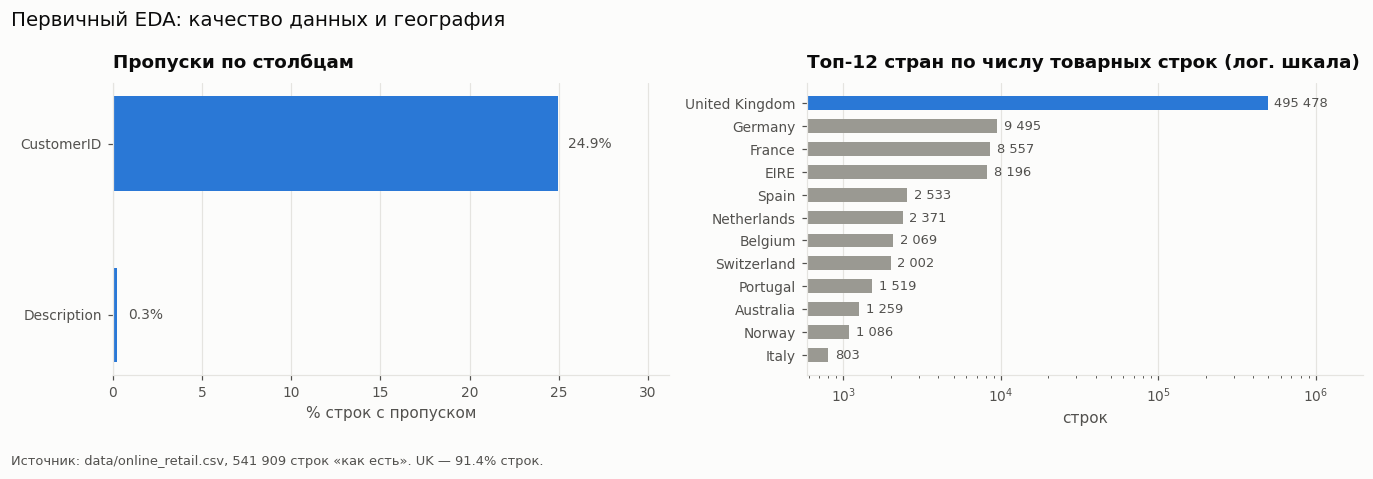

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))

# Доля пропусков по столбцам — один показатель, одна серия, прямые подписи.
miss = (raw.isna().mean() * 100).sort_values()
miss = miss[miss > 0]
ax = axes[0]
bars = ax.barh(miss.index, miss.values, color=ACCENT, height=0.55)
for b, v in zip(bars, miss.values):
    ax.text(v + 0.6, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=9, color=INK_2)
ax.set_title("Пропуски по столбцам")
ax.set_xlabel("% строк с пропуском")
ax.set_xlim(0, max(miss.values) * 1.25)
ax.grid(axis="y", visible=False)

# Топ-12 стран по числу строк
ax = axes[1]
top_c = raw.Country.value_counts().head(12).sort_values()
cols = [NEUTRAL] * len(top_c); cols[-1] = ACCENT
ax.barh(top_c.index, top_c.values, color=cols, height=0.6)
ax.set_xscale("log")
ax.set_xlim(right=top_c.max() * 4)          # запас справа под подписи значений
ax.set_title("Топ-12 стран по числу товарных строк (лог. шкала)")
ax.set_xlabel("строк")
for y, v in enumerate(top_c.values):
    ax.text(v * 1.1, y, f"{v:,}".replace(",", " "), va="center", fontsize=8.5, color=INK_2)
ax.grid(axis="y", visible=False)

fig.suptitle("Первичный EDA: качество данных и география", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "01_raw_quality", "Источник: data/online_retail.csv, 541 909 строк «как есть». UK — 91.4% строк.")

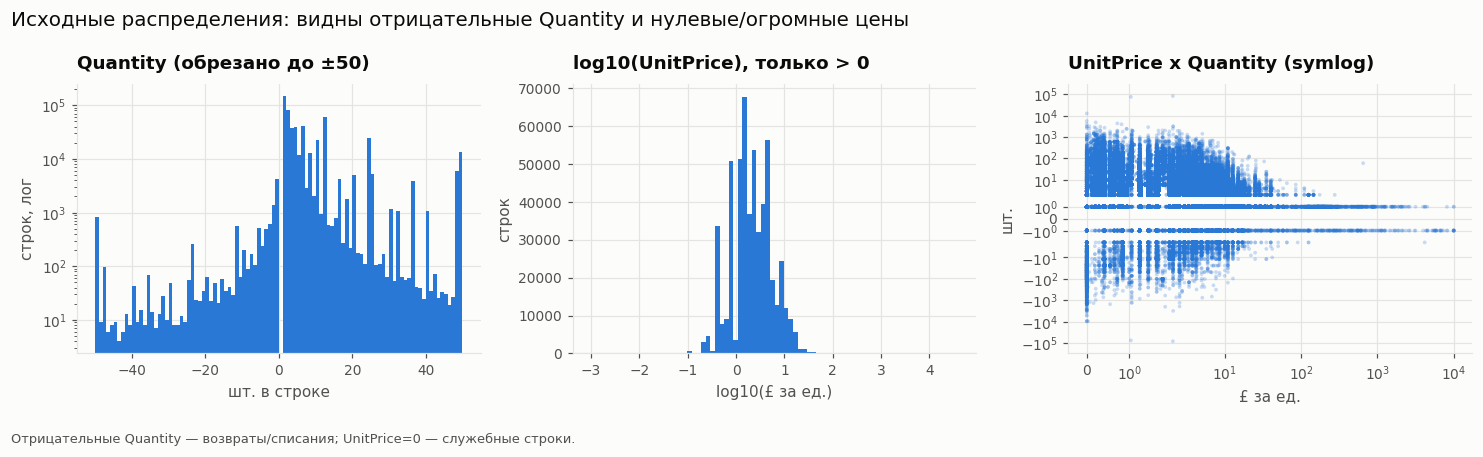

In [9]:
# Распределения Quantity и UnitPrice «как есть»: тяжёлые хвосты в обе стороны
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

ax = axes[0]
ax.hist(raw.Quantity.clip(-50, 50), bins=100, color=ACCENT)
ax.set_yscale("log")
ax.set_title("Quantity (обрезано до ±50)"); ax.set_xlabel("шт. в строке"); ax.set_ylabel("строк, лог")

ax = axes[1]
pos = raw.UnitPrice[raw.UnitPrice > 0]
ax.hist(np.log10(pos), bins=80, color=ACCENT)
ax.set_title("log10(UnitPrice), только > 0"); ax.set_xlabel("log10(£ за ед.)"); ax.set_ylabel("строк")

ax = axes[2]
q = raw.Quantity
ax.scatter(raw.UnitPrice.clip(0, 1e4), q, s=6, alpha=0.25, color=ACCENT, edgecolor="none")
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_title("UnitPrice x Quantity (symlog)"); ax.set_xlabel("£ за ед."); ax.set_ylabel("шт.")

fig.suptitle("Исходные распределения: видны отрицательные Quantity и нулевые/огромные цены", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "02_raw_distributions", "Отрицательные Quantity — возвраты/списания; UnitPrice=0 — служебные строки.")

In [10]:
# Что скрывается за нестандартными StockCode и нулевыми ценами
svc = raw.loc[~raw.StockCode.str.match(r"^\d{5}[A-Za-z]{0,2}$"), ["StockCode", "Description"]]
display(svc.StockCode.str.upper().value_counts().head(15).to_frame("строк"))
print("Примеры описаний служебных кодов:")
display(svc.assign(SC=svc.StockCode.str.upper()).drop_duplicates("SC").head(12))
print("\nСтроки с UnitPrice == 0, топ описаний:")
display(raw.loc[raw.UnitPrice == 0, "Description"].fillna("<NaN>").value_counts().head(8).to_frame("строк"))

,строк
StockCode,
POST,1256
DOT,710
M,572
C2,144
D,77
S,63
BANK CHARGES,37
AMAZONFEE,34
CRUK,16


Примеры описаний служебных кодов:


,StockCode,Description,SC
45,POST,POSTAGE,POST
141,D,Discount,D
1423,C2,CARRIAGE,C2
1814,DOT,DOTCOM POSTAGE,DOT
2239,M,Manual,M
4406,BANK CHARGES,Bank Charges,BANK CHARGES
14436,S,SAMPLES,S
14514,AMAZONFEE,AMAZON FEE,AMAZONFEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,DCGS0076
24906,DCGS0003,BOXED GLASS ASHTRAY,DCGS0003



Строки с UnitPrice == 0, топ описаний:


,строк
Description,
<NaN>,1454
check,159
?,47
damages,45
damaged,43
found,25
sold as set on dotcom,20
adjustment,16


In [11]:
# Отмены (возвраты): их объём и то, как они распределены по клиентам
canc = raw[raw.InvoiceNo.str.startswith("C")].copy()
canc["Amount"] = canc.Quantity * canc.UnitPrice
print(f"Счётов-отмен: {canc.InvoiceNo.nunique():,}   строк: {len(canc):,}")
print(f"Клиентов с отменами: {canc.CustomerID.nunique():,}")
print(f"Сумма возвратов: £{-canc.Amount.sum():,.0f}")
display(canc.nsmallest(5, "Quantity")[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "InvoiceDate", "CustomerID"]])

Счётов-отмен: 3,836   строк: 9,288
Клиентов с отменами: 1,589
Сумма возвратов: £896,812


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate,CustomerID
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.080,2011-12-09 09:27:00,16446
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.040,2011-01-18 10:17:00,12346
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.030,2010-12-02 14:23:00,15838
160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2.100,2011-04-18 13:08:00,15749
160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,1.850,2011-04-18 13:08:00,15749


### Промежуточные выводы первичного EDA

* Формально «пропусков нет», но фактически **135 080 строк (24.9%) без `CustomerID`** и
  1 454 строки без `Description`. Для клиентской кластеризации строки без `CustomerID`
  непригодны — восстановить принадлежность к клиенту нельзя.
* **5 268 полных дубликатов строк** — техническое дублирование выгрузки.
* **9 288 строк — отмены** (`InvoiceNo` начинается с `C`, `Quantity < 0`). Плюс ~1 336 строк
  с `Quantity <= 0` вне отмен (списания/корректировки склада).
* `UnitPrice == 0` (2 515 строк) и `UnitPrice < 0` (2 строки — счета-корректировки
  с префиксом `A`, «Adjust bad debt», по −£11 062) — не продажи.
* Часть `StockCode` — **служебные позиции**, а не товары: `POST`, `DOT` (доставка), `M`/`m`
  (manual), `S` (samples), `D` (discount), `BANK CHARGES`, `AMAZONFEE`, `CRUK` (донат),
  `PADS`, `C2` (carriage), `gift_0001_*` (подарочные карты).
* Экстремумы `Quantity` (±80 995) — пара «заказ + его полная отмена», т.е. артефакт, а не спрос.
* 91.4% строк — Великобритания; период 01.12.2010–09.12.2011 (декабрь 2011 неполный —
  это важно учитывать при анализе сезонности и тренда).

## 4. Очистка данных

Фиксируем каждый шаг в журнале очистки, чтобы понимать цену каждого фильтра.

In [12]:
clean_log = []

def log_step(name, df_before, df_after, comment=""):
    "Журнал очистки: сколько строк и какая доля выручки-брутто ушли на шаге."
    removed = len(df_before) - len(df_after)
    clean_log.append({
        "шаг": name, "строк до": len(df_before), "удалено": removed,
        "% удалено": round(100 * removed / max(len(df_before), 1), 2),
        "строк после": len(df_after), "комментарий": comment,
    })
    return df_after

df = raw.copy()
n_start = len(df)

### 4.1 Полные дубликаты строк

In [13]:
dups = df[df.duplicated(keep=False)].sort_values(["InvoiceNo", "StockCode"])
print(f"Строк, участвующих в дублировании: {len(dups):,}; лишних копий: {df.duplicated().sum():,}")
display(dups.head(6))

before = df
df = df.drop_duplicates().reset_index(drop=True)
df = log_step("Удаление полных дубликатов", before, df, "техническое дублирование выгрузки")

Строк, участвующих в дублировании: 10,147; лишних копий: 5,268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.250,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.250,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.950,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.950,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.100,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.100,17908,United Kingdom


### 4.2 Корректный формат даты и времени

`InvoiceDate` взят из CSV как `datetime64[ns]`, приводим тип повторно (`errors="coerce"`), проверяем отсутствие
«неразобранных» значений, границы периода, отсутствие будущих дат и добавляем календарные
срезы (дата, год-месяц, неделя с понедельника, день недели, час).

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce", dayfirst=True)
print("Не разобрано в дату:", int(df.InvoiceDate.isna().sum()))
print("Тип:", df.InvoiceDate.dtype, "| tz:", df.InvoiceDate.dt.tz)
print("Мин:", df.InvoiceDate.min(), "| Макс:", df.InvoiceDate.max())
print("Дат в будущем относительно конца выгрузки:", int((df.InvoiceDate > df.InvoiceDate.max()).sum()))

# Календарные признаки (единая точка истины для всех дальнейших агрегаций)
df["Date"]      = df.InvoiceDate.dt.normalize()
df["Year"]      = df.InvoiceDate.dt.year
df["Month"]     = df.InvoiceDate.dt.to_period("M").dt.to_timestamp()   # начало месяца
df["Week"]      = df.InvoiceDate.dt.to_period("W-SUN").dt.start_time   # неделя, нач. с понедельника
df["DayOfWeek"] = df.InvoiceDate.dt.dayofweek                          # 0 = Пн
df["DayName"]   = df.InvoiceDate.dt.day_name()
df["Hour"]      = df.InvoiceDate.dt.hour

print("\nДни недели, представленные в данных:")
display(df.DayName.value_counts().to_frame("строк"))
print("Часы:", sorted(df.Hour.unique()))
print("Полных календарных недель:", df.Week.nunique(), "| месяцев:", df.Month.nunique(), "| дней с продажами:", df.Date.nunique())

> **Замечание.** В данных **полностью отсутствует суббота** (0 счетов) — компания не
> обрабатывает заказы в этот день. Время суток — только рабочие часы (06:00–20:00).
> Это учитываем при построении «недельного» профиля активности.

### 4.3 Пропуски

In [15]:
no_id = df[df.CustomerID.isna()]
gross = (df.Quantity * df.UnitPrice)
print(f"Строк без CustomerID: {len(no_id):,} ({100*len(no_id)/len(df):.1f}%)")
print(f"Их доля в обороте:    {100 * (no_id.Quantity*no_id.UnitPrice).sum() / gross.sum():.1f}%")
print(f"Счётов без CustomerID: {no_id.InvoiceNo.nunique():,}")
print("Отмен среди них:", int(no_id.InvoiceNo.str.startswith('C').sum()))
print("\nСтраны строк без CustomerID:")
display(no_id.Country.value_counts().head(5).to_frame("строк"))

n_desc = int(df.Description.isna().sum())
n_desc_no_id = int(df.loc[df.Description.isna(), "CustomerID"].isna().sum())
print(f"\nПропуски Description: {n_desc:,} строк, из них без CustomerID: {n_desc_no_id:,}")
print("Средняя цена в строках без Description: £%.2f" % df.loc[df.Description.isna(), "UnitPrice"].mean())

Строк без CustomerID: 135,037 (25.2%)
Их доля в обороте:    14.9%
Счётов без CustomerID: 3,710
Отмен среди них: 379

Страны строк без CustomerID:


,строк
Country,
United Kingdom,133572
EIRE,709
Hong Kong,284
Unspecified,201
Switzerland,117



Пропуски Description: 1,454 строк, из них без CustomerID: 1,454
Средняя цена в строках без Description: £0.00


In [16]:
# Description не участвует в кластеризации -> достаточно заполнить заглушкой.
df["Description"] = df.Description.fillna("<no description>").str.strip()

# Строки без CustomerID нельзя отнести к клиенту -> исключаем (задача клиентская).
before = df
df = df[df.CustomerID.notna()].copy()
df["CustomerID"] = df.CustomerID.astype("int64")
df = log_step("Удаление строк без CustomerID", before, df,
              "невозможно построить клиентский временной ряд (~25% строк, ~15% оборота)")
print("Клиентов осталось:", df.CustomerID.nunique())

Клиентов осталось: 4372


### 4.4 Отмены и возвраты

Отмена (`InvoiceNo` = `C…`, `Quantity < 0`) — это не покупка, а её аннулирование.
Поступаем так:

1. по отменам считаем **клиентские признаки возвратов** (`n_cancel`, `return_rate`) — они
   информативны для сегментации;
2. **сопоставляем (неттинг)** каждую строку-отмену с исходной строкой-покупкой по ключу
   (`CustomerID`, `StockCode`, `|Quantity|`) один-к-одному и удаляем **обе** — иначе
   полностью возвращённые заказы завышают выручку и «взрывают» временной ряд
   (именно так в данные попадают экстремумы ±80 995 шт.);
3. остальные строки-отмены удаляем.

In [17]:
is_cancel = df.InvoiceNo.str.startswith("C")
cancels = df[is_cancel].copy()
cancels["Amount"] = (cancels.Quantity * cancels.UnitPrice).abs()

# (1) клиентские агрегаты по возвратам — понадобятся в разделе признаков
cancel_stats = cancels.groupby("CustomerID").agg(
    n_cancel=("InvoiceNo", "nunique"),
    cancel_amount=("Amount", "sum"),
).astype({"n_cancel": "int64"})
print("Клиентов с отменами:", len(cancel_stats), "| сумма отмен: £%.0f" % cancel_stats.cancel_amount.sum())

# (2) неттинг: пара «покупка <-> её полная отмена»
purchases = df[~is_cancel & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
cn = cancels[cancels.Quantity < 0].copy()
cn["Qabs"] = -cn.Quantity
KEY = ["CustomerID", "StockCode"]
purchases["_pair"] = purchases.groupby(KEY + ["Quantity"]).cumcount()
cn["_pair"] = cn.groupby(KEY + ["Qabs"]).cumcount()

pairs = cn.merge(
    purchases.reset_index()[["index", "InvoiceDate", "UnitPrice"] + KEY + ["Quantity", "_pair"]]
             .rename(columns={"index": "buy_idx", "InvoiceDate": "buy_date", "UnitPrice": "buy_price"}),
    left_on=KEY + ["Qabs", "_pair"], right_on=KEY + ["Quantity", "_pair"], suffixes=("_c", "_b"))
pairs["lag_days"] = (pairs.InvoiceDate - pairs.buy_date).dt.total_seconds() / 86400
pairs = pairs[pairs.lag_days >= -1]          # отмена не может быть раньше покупки
returned_idx = set(pairs.buy_idx)

print(f"\nСопоставлено пар «покупка — полная отмена»: {len(pairs):,}")
print("Задержка возврата, дней:", pairs.lag_days.describe(percentiles=[.5, .9]).round(1).to_dict())
print(f"Возвращённая выручка: £{(pairs.Qabs*pairs.buy_price).sum():,.0f}")
display(pairs.nlargest(3, "Qabs")[["CustomerID", "StockCode", "Qabs", "buy_date", "InvoiceDate", "lag_days"]])

Клиентов с отменами: 1589 | сумма отмен: £608689



Сопоставлено пар «покупка — полная отмена»: 2,957
Задержка возврата, дней: {'count': 2957.0, 'mean': 43.4, 'std': 67.3, 'min': -0.8, '50%': 15.0, '90%': 151.0, 'max': 368.2}
Возвращённая выручка: £429,241


,CustomerID,StockCode,Qabs,buy_date,InvoiceDate,lag_days
3166,16446,23843,80995,2011-12-09 09:15:00,2011-12-09 09:27:00,0.008
263,12346,23166,74215,2011-01-18 10:01:00,2011-01-18 10:17:00,0.011
888,15749,21108,3114,2011-01-11 12:55:00,2011-04-18 13:08:00,97.009


In [18]:
before = df
df = df.drop(index=list(returned_idx))
df = log_step("Неттинг полностью возвращённых позиций", before, df,
              f"{len(returned_idx):,} строк-покупок, аннулированных отменой (вкл. артефакты 80 995 и 74 215 шт.)")

before = df
df = df[~df.InvoiceNo.str.startswith("C")].copy()
df = log_step("Удаление строк-отмен", before, df, "отмены учтены в признаках возвратов")

### 4.5 Некорректные `Quantity` и `UnitPrice`

In [19]:
bad = df[(df.Quantity <= 0) | (df.UnitPrice <= 0)]
print("Осталось строк с Quantity <= 0:", int((df.Quantity <= 0).sum()),
      "| с UnitPrice <= 0:", int((df.UnitPrice <= 0).sum()))
print("(строки-отмены уже удалены, поэтому отрицательных количеств не осталось)")
display(bad.head(5)[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]]
        if len(bad) else pd.DataFrame({"нет некорректных строк": []}))

before = df
df = df[(df.Quantity > 0) & (df.UnitPrice > 0)].copy()
df = log_step("Quantity > 0 и UnitPrice > 0", before, df,
              "нулевая цена: бесплатные позиции, подарки и ручные корректировки (Manual)")

Осталось строк с Quantity <= 0: 0 | с UnitPrice <= 0: 40
(строки-отмены уже удалены, поэтому отрицательных количеств не осталось)


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
9132,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,0.000
33122,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,0.000
39592,539722,22423,REGENCY CAKESTAND 3 TIER,10,0.000
46557,540372,22090,PAPER BUNTING RETROSPOT,24,0.000
46559,540372,22553,PLASTERS IN TIN SKULLS,24,0.000


### 4.6 Служебные позиции вместо товаров

Оставляем только «настоящие» товарные коды формата `#####` с необязательным
буквенным суффиксом (`85123A`, `15056BL`). Правило отсекает `POST`, `DOT` (доставка),
`M` (ручная корректировка), `S`, `D`, `C2`, `BANK CHARGES`, `AMAZONFEE`, `CRUK`, `PADS`,
а также `gift_0001_*` и `DCGS*` — впрочем, последние две группы уже ушли вместе со
строками без `CustomerID` (у них клиент не указан).

In [20]:
is_product = df.StockCode.str.match(r"^\d{5}[A-Za-z]{0,2}$")
print("Служебные строки к удалению:", int((~is_product).sum()))
display(df.loc[~is_product, "StockCode"].str.upper().value_counts().head(10).to_frame("строк"))

before = df
df = df[is_product].copy()
df = log_step("Только товарные StockCode", before, df,
              "доставка (POST/DOT/C2), ручные корректировки (M), банковские сборы, PADS")

df["TotalPrice"] = (df.Quantity * df.UnitPrice).round(2)
print("Итог:", f"{len(df):,} строк, {df.CustomerID.nunique():,} клиентов, {df.InvoiceNo.nunique():,} счетов,",
      f"оборот £{df.TotalPrice.sum():,.0f}")

Служебные строки к удалению: 1469


,строк
StockCode,
POST,1075
M,231
C2,132
DOT,16
BANK CHARGES,12
PADS,3


Итог: 388,266 строк, 4,322 клиентов, 18,289 счетов, оборот £8,345,731


### 4.7 Выбросы

Разделяем два принципиально разных случая:

* **Ошибки данных** — уже устранены (пары «заказ + полная отмена», нулевые цены).
* **Реальные, но экстремальные наблюдения** — крупные оптовые счета. Удалять их нельзя:
  это существенная часть бизнеса и, вероятно, отдельный сегмент. Поэтому:
  * фиксируем их количество и вклад в оборот;
  * работаем с **логарифмической шкалой** денежных признаков;
  * на этапе подготовки к кластеризации применяем **винсоризацию признаков** по
    1-му и 99-му процентилю (значения не удаляются, а «подрезаются») — так один
    оптовик не тянет на себя центроид.

In [21]:
inv_tot = df.groupby("InvoiceNo").TotalPrice.sum()
q1, q3 = inv_tot.quantile([.25, .75]); iqr = q3 - q1
hi_iqr = q3 + 1.5 * iqr
lg = np.log10(inv_tot)
lq1, lq3 = lg.quantile([.25, .75]); liqr = lq3 - lq1
hi_log = 10 ** (lq3 + 1.5 * liqr)

print(f"Сумма счёта: медиана £{inv_tot.median():.0f}, 99-й проц. £{inv_tot.quantile(.99):,.0f}, макс £{inv_tot.max():,.0f}")
print(f"Порог IQR (сырая шкала): £{hi_iqr:,.0f} -> выбросов {int((inv_tot > hi_iqr).sum()):,} "
      f"({100*(inv_tot > hi_iqr).mean():.1f}% счетов, {100*inv_tot[inv_tot > hi_iqr].sum()/inv_tot.sum():.1f}% оборота)")
print(f"Порог IQR (лог. шкала):  £{hi_log:,.0f} -> выбросов {int((inv_tot > hi_log).sum()):,} "
      f"({100*(inv_tot > hi_log).mean():.2f}% счетов, {100*inv_tot[inv_tot > hi_log].sum()/inv_tot.sum():.1f}% оборота)")
display(df.groupby("InvoiceNo").TotalPrice.sum().nlargest(5).to_frame("сумма счёта, £"))

Сумма счёта: медиана £300, 99-й проц. £3,626, макс £38,970
Порог IQR (сырая шкала): £917 -> выбросов 1,433 (7.8% счетов, 39.4% оборота)
Порог IQR (лог. шкала):  £2,334 -> выбросов 335 (1.83% счетов, 21.8% оборота)


,"сумма счёта, £"
InvoiceNo,
556444,"38,970.000"
567423,"27,872.800"
556917,"22,775.930"
572209,"22,206.000"
567381,"22,104.800"


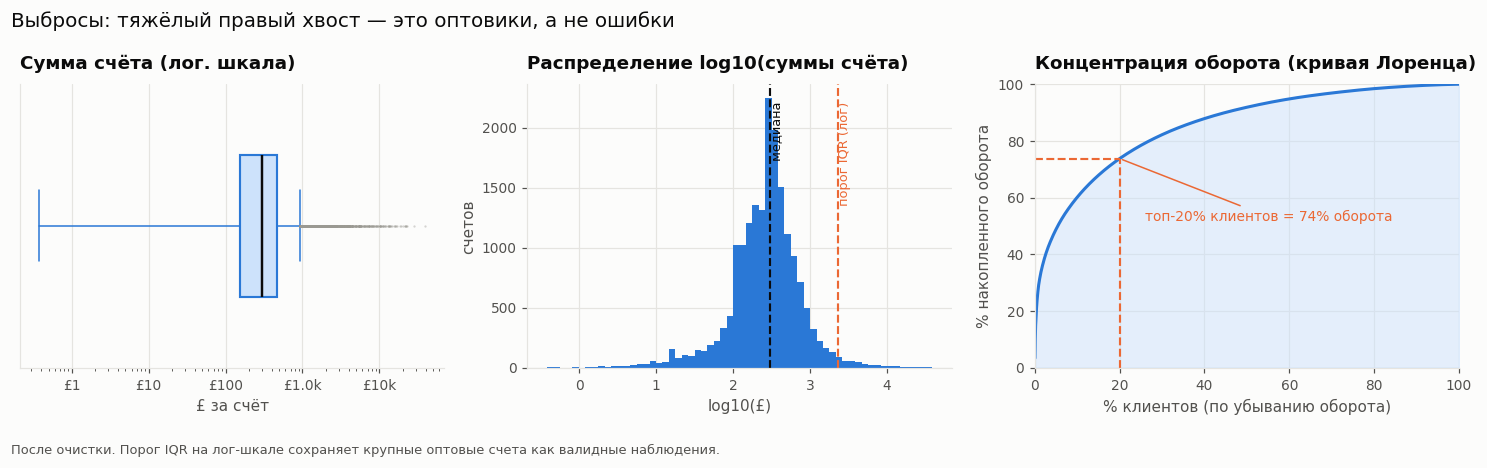

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]
ax.boxplot(inv_tot.values, vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#cde2fb", edgecolor=ACCENT, linewidth=1.4),
           medianprops=dict(color=INK, linewidth=1.6), flierprops=dict(marker=".", markersize=3, markerfacecolor=NEUTRAL,
           markeredgecolor="none", alpha=.4), whiskerprops=dict(color=ACCENT), capprops=dict(color=ACCENT))
ax.set_xscale("log"); ax.set_yticks([])
ax.set_title("Сумма счёта (лог. шкала)"); ax.set_xlabel("£ за счёт")
ax.xaxis.set_major_formatter(GBP)

ax = axes[1]
ax.hist(np.log10(inv_tot), bins=60, color=ACCENT)
for v, lab, c in [(np.log10(inv_tot.median()), "медиана", INK), (np.log10(hi_log), "порог IQR (лог)", ACCENT_2)]:
    ax.axvline(v, color=c, lw=1.4, ls="--")
    ax.text(v, ax.get_ylim()[1]*0.94, f" {lab}", color=c, fontsize=8.5, rotation=90, va="top")
ax.set_title("Распределение log10(суммы счёта)"); ax.set_xlabel("log10(£)"); ax.set_ylabel("счетов")

ax = axes[2]
cust_rev = df.groupby("CustomerID").TotalPrice.sum().sort_values(ascending=False)
share = cust_rev.cumsum() / cust_rev.sum()
x = np.arange(1, len(share) + 1) / len(share) * 100
ax.plot(x, share.values * 100, color=ACCENT)
ax.fill_between(x, share.values * 100, color="#cde2fb", alpha=.5)
p20 = share.values[int(len(share) * .2) - 1] * 100
ax.plot([20, 20], [0, p20], color=ACCENT_2, lw=1.4, ls="--")
ax.plot([0, 20], [p20, p20], color=ACCENT_2, lw=1.4, ls="--")
ax.annotate(f"топ-20% клиентов = {p20:.0f}% оборота", (20, p20), xytext=(26, p20 - 22),
            fontsize=9, color=ACCENT_2, arrowprops=dict(arrowstyle="-", color=ACCENT_2, lw=1))
ax.set_title("Концентрация оборота (кривая Лоренца)")
ax.set_xlabel("% клиентов (по убыванию оборота)"); ax.set_ylabel("% накопленного оборота")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

fig.suptitle("Выбросы: тяжёлый правый хвост — это оптовики, а не ошибки", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "03_outliers", "После очистки. Порог IQR на лог-шкале сохраняет крупные оптовые счета как валидные наблюдения.")

### 4.8 Итог очистки

In [23]:
log_df = pd.DataFrame(clean_log)
display(log_df)
print(f"Итого: {n_start:,} -> {len(df):,} строк (сохранено {100*len(df)/n_start:.1f}%)")

summary = pd.DataFrame({
    "показатель": ["строк", "счетов", "клиентов", "товаров", "стран", "оборот, £", "период"],
    "после очистки": [f"{len(df):,}", f"{df.InvoiceNo.nunique():,}", f"{df.CustomerID.nunique():,}",
                      f"{df.StockCode.nunique():,}", f"{df.Country.nunique():,}",
                      f"{df.TotalPrice.sum():,.0f}",
                      f"{df.Date.min():%d.%m.%Y} — {df.Date.max():%d.%m.%Y}"],
})
display(summary)
df = df.sort_values("InvoiceDate").reset_index(drop=True)
df.to_pickle(CACHE_DIR / "online_retail_clean.pkl")

,шаг,строк до,удалено,% удалено,строк после,комментарий
0,Удаление полных дубликатов,541909,5268,0.970,536641,техническое дублирование выгрузки
1,Удаление строк без CustomerID,536641,135037,25.160,401604,невозможно построить клиентский временной ряд ...
2,Неттинг полностью возвращённых позиций,401604,2957,0.740,398647,"2,957 строк-покупок, аннулированных отменой (в..."
3,Удаление строк-отмен,398647,8872,2.230,389775,отмены учтены в признаках возвратов
4,Quantity > 0 и UnitPrice > 0,389775,40,0.010,389735,"нулевая цена: бесплатные позиции, подарки и ру..."
5,Только товарные StockCode,389735,1469,0.380,388266,"доставка (POST/DOT/C2), ручные корректировки (..."


Итого: 541,909 -> 388,266 строк (сохранено 71.6%)


,показатель,после очистки
0,строк,"388,266"
1,счетов,"18,289"
2,клиентов,"4,322"
3,товаров,"3,645"
4,стран,37
5,"оборот, £","8,345,731"
6,период,01.12.2010 — 09.12.2011


In [24]:
# Уровень счёта (транзакции) — базовая таблица для всех временных рядов и признаков.
invoices = (df.groupby(["CustomerID", "InvoiceNo"], as_index=False)
              .agg(Date=("InvoiceDate", "min"), Amount=("TotalPrice", "sum"),
                   Qty=("Quantity", "sum"), NItems=("StockCode", "nunique"),
                   Country=("Country", "first")))
invoices["Day"]   = invoices.Date.dt.normalize()
invoices["Week"]  = invoices.Date.dt.to_period("W-SUN").dt.start_time
invoices["MonthP"] = invoices.Date.dt.to_period("M")
invoices["Month"] = invoices.MonthP.dt.to_timestamp()
invoices["DayOfWeek"] = invoices.Date.dt.dayofweek
invoices["Hour"] = invoices.Date.dt.hour
invoices = invoices.sort_values(["CustomerID", "Date"]).reset_index(drop=True)

OBS_START = invoices.Date.min().normalize()
OBS_END   = invoices.Date.max().normalize()
SNAPSHOT  = OBS_END + pd.Timedelta(days=1)     # «сегодня» для расчёта recency
OBS_DAYS  = (SNAPSHOT - OBS_START).days

print(f"Транзакций (счетов): {len(invoices):,} | клиентов: {invoices.CustomerID.nunique():,}")
print(f"Окно наблюдения: {OBS_START:%d.%m.%Y} — {OBS_END:%d.%m.%Y} ({OBS_DAYS} дней), snapshot = {SNAPSHOT:%d.%m.%Y}")
display(invoices.head(5))
display(invoices.Amount.describe(percentiles=[.05, .25, .5, .75, .95, .99]).to_frame("сумма счёта, £"))

Транзакций (счетов): 18,289 | клиентов: 4,322
Окно наблюдения: 01.12.2010 — 09.12.2011 (374 дней), snapshot = 10.12.2011


,CustomerID,InvoiceNo,Date,Amount,Qty,NItems,Country,Day,Week,MonthP,Month,DayOfWeek,Hour
0,12347,537626,2010-12-07 14:57:00,711.790,319,31,Iceland,2010-12-07,2010-12-06,2010-12,2010-12-01,1,14
1,12347,542237,2011-01-26 14:30:00,475.390,315,29,Iceland,2011-01-26,2011-01-24,2011-01,2011-01-01,2,14
2,12347,549222,2011-04-07 10:43:00,636.250,483,24,Iceland,2011-04-07,2011-04-04,2011-04,2011-04-01,3,10
3,12347,556201,2011-06-09 13:01:00,382.520,196,18,Iceland,2011-06-09,2011-06-06,2011-06,2011-06-01,3,13
4,12347,562032,2011-08-02 08:48:00,584.910,277,22,Iceland,2011-08-02,2011-08-01,2011-08,2011-08-01,1,8


,"сумма счёта, £"
count,"18,289.000"
mean,456.325
std,962.532
min,0.380
5%,40.616
25%,156.000
50%,300.460
75%,460.400
95%,"1,188.522"
99%,"3,626.248"


## 5. Разведочный анализ очищенных данных

### 5.1 Динамика оборота и заказов

In [25]:
daily = invoices.groupby("Day").agg(revenue=("Amount", "sum"), orders=("InvoiceNo", "count"),
                                    customers=("CustomerID", "nunique"))
daily = daily.reindex(pd.date_range(OBS_START, OBS_END, freq="D"), fill_value=0)
weekly = (invoices.groupby("Week").agg(revenue=("Amount", "sum"), orders=("InvoiceNo", "count"),
                                       customers=("CustomerID", "nunique"))
          # полная сетка недель: неделя 27.12.2010 без продаж должна остаться в ряду нулём
          .reindex(pd.date_range(invoices.Week.min(), invoices.Week.max(), freq="W-MON"), fill_value=0))
monthly = invoices.groupby("Month").agg(revenue=("Amount", "sum"), orders=("InvoiceNo", "count"),
                                        customers=("CustomerID", "nunique"),
                                        avg_check=("Amount", "mean"))
display(monthly.assign(revenue=lambda t: t.revenue.round(0), avg_check=lambda t: t.avg_check.round(1)))

# Одни и те же транзакции, агрегированные по трём уровням (день / неделя / месяц)
agg_levels = pd.DataFrame({
    "уровень":                  ["день", "неделя", "месяц"],
    "периодов":                 [len(daily), len(weekly), len(monthly)],
    "средняя выручка, £":       [daily.revenue.mean(), weekly.revenue.mean(), monthly.revenue.mean()],
    "средне заказов за период": [daily.orders.mean(), weekly.orders.mean(), monthly.orders.mean()],
    "периодов без продаж":      [int((daily.orders == 0).sum()), int((weekly.orders == 0).sum()),
                                 int((monthly.orders == 0).sum())],
    "коэф. вариации выручки":   [daily.revenue.std() / daily.revenue.mean(),
                                 weekly.revenue.std() / weekly.revenue.mean(),
                                 monthly.revenue.std() / monthly.revenue.mean()],
}).round(2)
display(agg_levels)

,revenue,orders,customers,avg_check
Month,,,,
2010-12-01,"552,766.000",1381,882,400.300
2011-01-01,"454,452.000",972,737,467.500
2011-02-01,"438,360.000",987,756,444.100
2011-03-01,"573,289.000",1306,970,439.000
2011-04-01,"449,945.000",1129,849,398.500
2011-05-01,"651,755.000",1534,1051,424.900
2011-06-01,"644,114.000",1379,989,467.100
2011-07-01,"581,202.000",1313,944,442.700
2011-08-01,"630,519.000",1263,932,499.200


,уровень,периодов,"средняя выручка, £",средне заказов за период,периодов без продаж,коэф. вариации выручки
0,день,374,"22,314.790",48.900,69,0.760
1,неделя,54,"154,550.580",338.690,1,0.390
2,месяц,13,"641,979.340","1,406.850",0,0.360


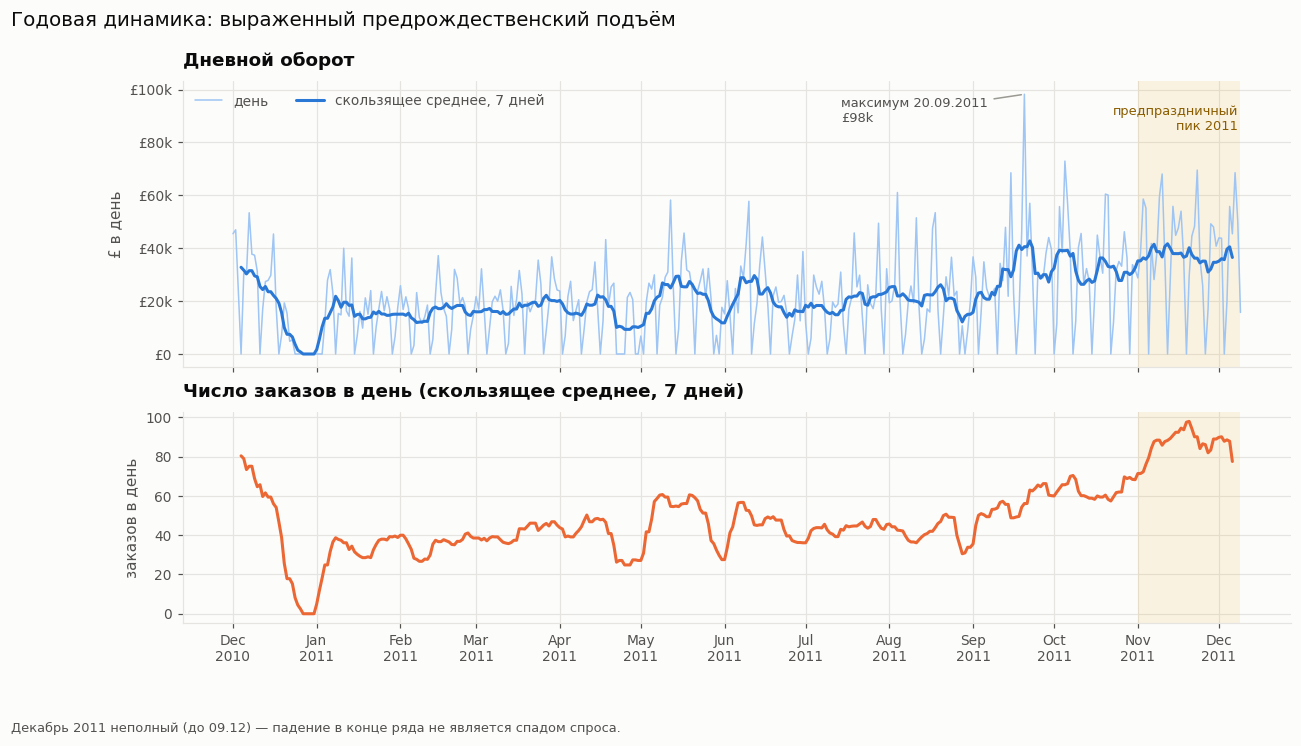

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True,
                         gridspec_kw=dict(height_ratios=[1.35, 1], hspace=0.18))
# Две метрики разного масштаба -> две панели с общей осью X (двойная ось Y запрещена).
ax = axes[0]
ax.plot(daily.index, daily.revenue, color="#9ec5f4", lw=1.0, label="день")
ma = daily.revenue.rolling(7, center=True).mean()
ax.plot(ma.index, ma, color=ACCENT, lw=2.0, label="скользящее среднее, 7 дней")
ax.set_title("Дневной оборот"); ax.set_ylabel("£ в день"); ax.yaxis.set_major_formatter(GBP)
ax.legend(loc="upper left", ncols=2)
peak = daily.revenue.idxmax()
ax.annotate(f"максимум {peak:%d.%m.%Y}\n{gbp(daily.revenue.max())}", (peak, daily.revenue.max()),
            xytext=(-120, -18), textcoords="offset points", fontsize=8.5, color=INK_2,
            arrowprops=dict(arrowstyle="-", color=NEUTRAL, lw=1))

ax = axes[1]
ax.plot(daily.index, daily.orders.rolling(7, center=True).mean(), color=ACCENT_2, lw=2.0)
ax.set_title("Число заказов в день (скользящее среднее, 7 дней)"); ax.set_ylabel("заказов в день")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
for a in axes:
    a.axvspan(pd.Timestamp("2011-11-01"), pd.Timestamp("2011-12-09"), color="#eda100", alpha=.10, lw=0)
axes[0].text(pd.Timestamp("2011-12-08"), daily.revenue.max() * .96, "предпраздничный\nпик 2011",
             ha="right", va="top", fontsize=8.5, color="#8a5d00")

fig.suptitle("Годовая динамика: выраженный предрождественский подъём", x=0.005, ha="left", color=INK)
finish(fig, "04_dynamics", "Декабрь 2011 неполный (до 09.12) — падение в конце ряда не является спадом спроса.")

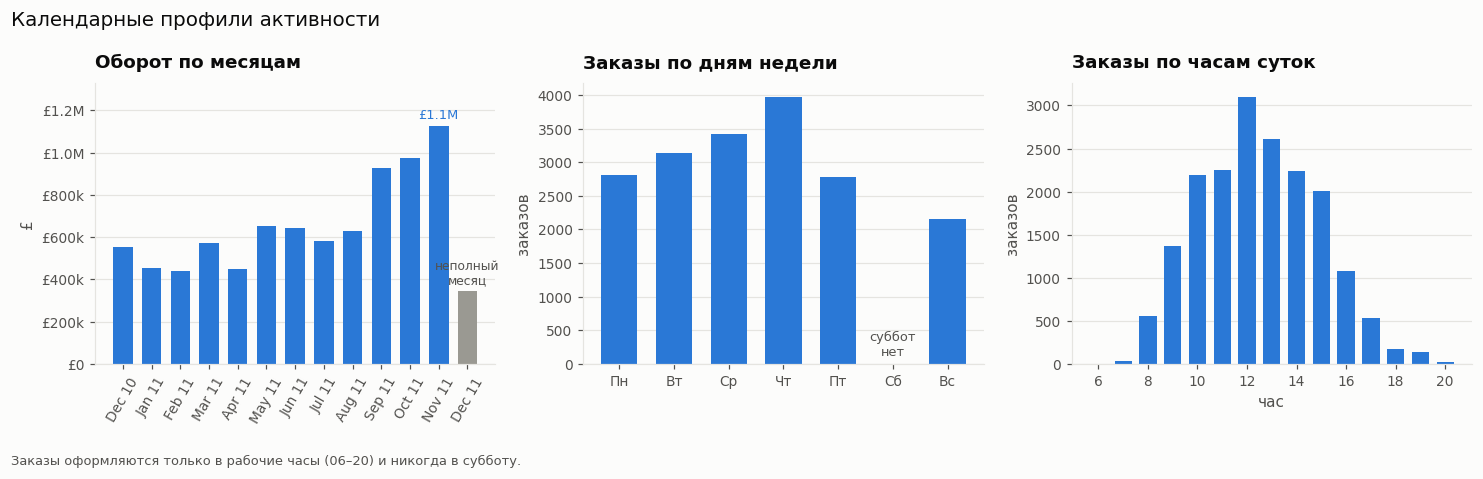

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

ax = axes[0]
m_lab = [f"{d:%b %y}" for d in monthly.index]
cols = [ACCENT] * len(monthly); cols[-1] = NEUTRAL      # последний месяц неполный
bars = ax.bar(m_lab, monthly.revenue, color=cols, width=0.68)
ax.set_title("Оборот по месяцам"); ax.set_ylabel("£"); ax.yaxis.set_major_formatter(GBP)
ax.set_ylim(0, monthly.revenue.max() * 1.18)
ax.tick_params(axis="x", rotation=60); ax.grid(axis="x", visible=False)
ax.text(len(monthly) - 1, monthly.revenue.iloc[-1] * 1.06, "неполный\nмесяц",
        ha="center", va="bottom", fontsize=8, color=INK_2)
ax.text(monthly.revenue.values.argmax(), monthly.revenue.max() * 1.02, gbp(monthly.revenue.max()),
        ha="center", va="bottom", fontsize=8.5, color=ACCENT)

ax = axes[1]
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
dow = invoices.groupby("DayOfWeek").InvoiceNo.count().reindex(range(7), fill_value=0)
cols = [ACCENT if v > 0 else GRID for v in dow.values]
ax.bar(dow_names, dow.values, color=cols, width=0.66)
ax.set_title("Заказы по дням недели"); ax.set_ylabel("заказов")
ax.grid(axis="x", visible=False)
ax.text(5, max(dow.values)*0.03, "суббот\nнет", ha="center", fontsize=8.5, color=INK_2)

ax = axes[2]
hour = invoices.groupby("Hour").InvoiceNo.count()
ax.bar(hour.index, hour.values, color=ACCENT, width=0.7)
ax.set_title("Заказы по часам суток"); ax.set_xlabel("час"); ax.set_ylabel("заказов")
ax.grid(axis="x", visible=False)

fig.suptitle("Календарные профили активности", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "05_calendar_profiles", "Заказы оформляются только в рабочие часы (06–20) и никогда в субботу.")

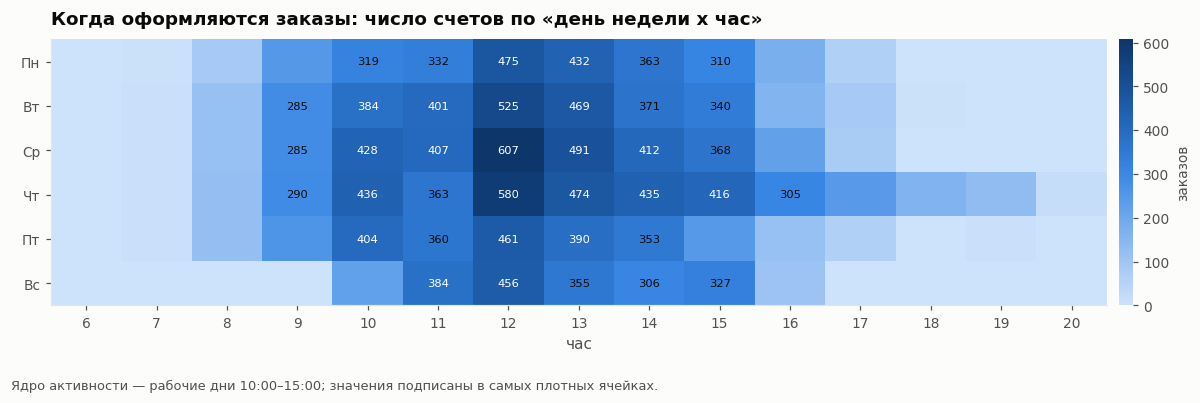

In [28]:
# Тепловая карта «день недели x час» — величина, поэтому однотонная последовательная шкала
pivot = (invoices.pivot_table(index="DayOfWeek", columns="Hour", values="InvoiceNo", aggfunc="count")
                 .reindex(index=[0, 1, 2, 3, 4, 6]).fillna(0))
fig, ax = plt.subplots(figsize=(12, 3.4))
im = ax.imshow(pivot.values, aspect="auto", cmap=SEQ_BLUE, origin="upper")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), [dow_names[i] for i in pivot.index])
ax.set_title("Когда оформляются заказы: число счетов по «день недели x час»")
ax.set_xlabel("час"); ax.grid(False)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if v > pivot.values.max() * 0.45:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="white" if v > pivot.values.max()*0.62 else INK)
cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label("заказов", color=INK_2, fontsize=9); cb.outline.set_visible(False)
finish(fig, "06_dow_hour_heatmap", "Ядро активности — рабочие дни 10:00–15:00; значения подписаны в самых плотных ячейках.")

### 5.2 Декомпозиция временного ряда

Ряд короткий (немного больше одного года), поэтому **годовую** сезонность выделить
статистически нельзя — её оцениваем описательно (месячный профиль выше).
Формальную декомпозицию делаем по **недельной** сезонности дневного ряда (period = 7).

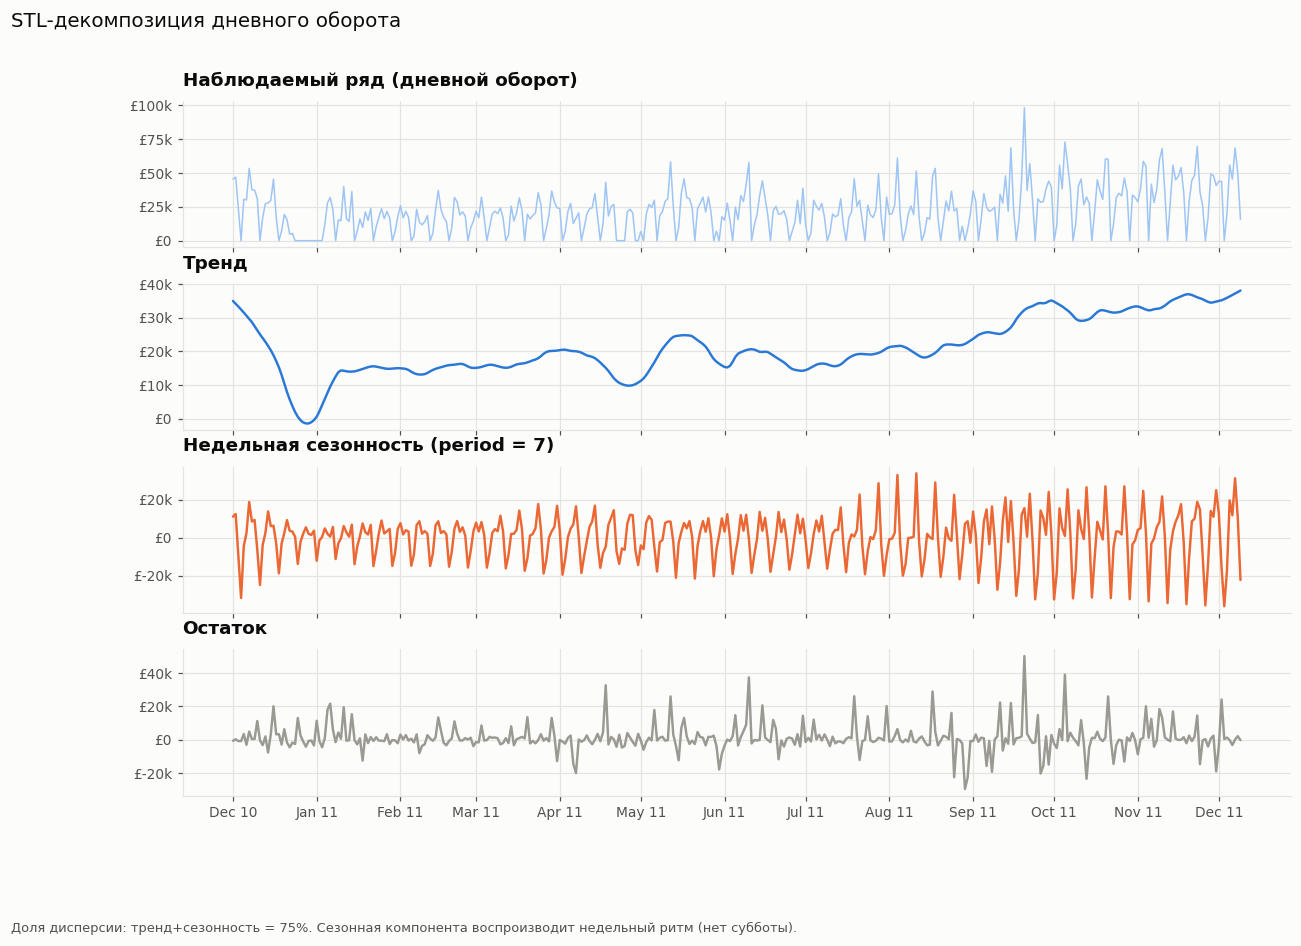

Средний сезонный вклад по дням недели, £:
Пн     3,485.000
Вт     7,539.000
Ср     4,955.000
Чт    14,409.000
Пт      -814.000
Сб   -21,438.000
Вс    -8,247.000


In [29]:
from statsmodels.tsa.seasonal import STL

s = daily.revenue.asfreq("D")
stl = STL(s, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 8.2), sharex=True, gridspec_kw=dict(hspace=0.25))
for ax, (y, ttl, c) in zip(axes, [
        (stl.observed, "Наблюдаемый ряд (дневной оборот)", "#9ec5f4"),
        (stl.trend,    "Тренд", ACCENT),
        (stl.seasonal, "Недельная сезонность (period = 7)", ACCENT_2),
        (stl.resid,    "Остаток", NEUTRAL)]):
    ax.plot(y.index, y.values, color=c, lw=1.6 if ttl != "Наблюдаемый ряд (дневной оборот)" else 1.0)
    ax.set_title(ttl); ax.yaxis.set_major_formatter(GBP)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.suptitle("STL-декомпозиция дневного оборота", x=0.005, ha="left", color=INK)
finish(fig, "07_stl", f"Доля дисперсии: тренд+сезонность = {1 - stl.resid.var()/stl.observed.var():.0%}. "
                      "Сезонная компонента воспроизводит недельный ритм (нет субботы).")
print("Средний сезонный вклад по дням недели, £:")
print(pd.Series(stl.seasonal.values, index=s.index.dayofweek).groupby(level=0).mean()
        .rename(index=dict(enumerate(dow_names))).round(0).to_string())

### 5.3 Клиенты: сколько покупают и как часто

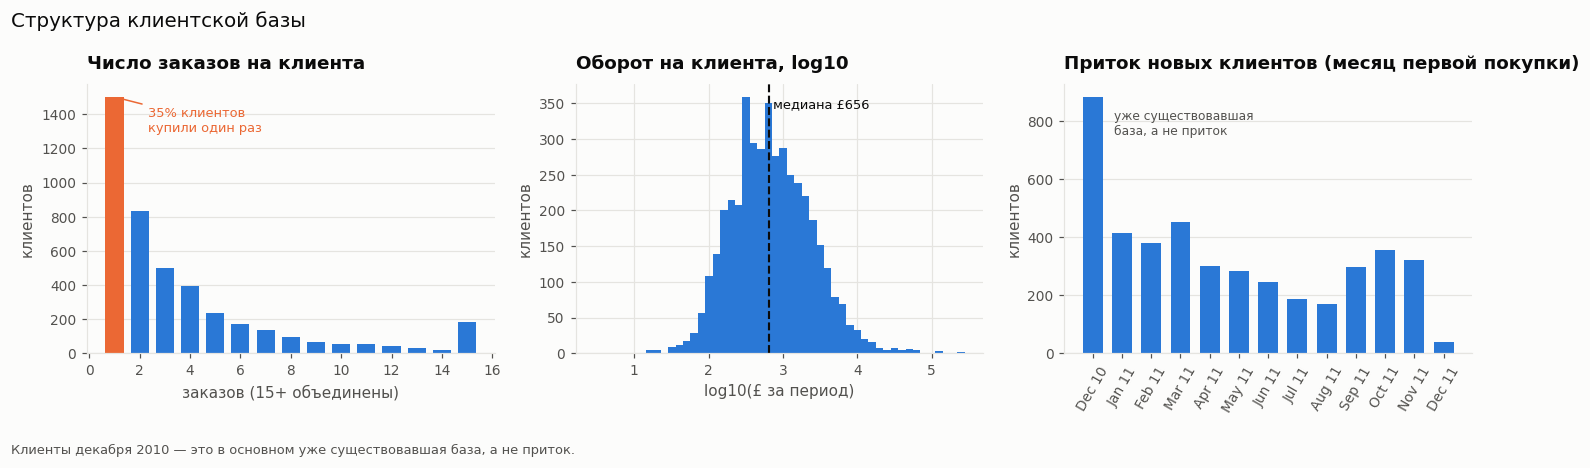

Клиентов: 4,322 | однократных: 1,501 (34.7%) | с >= 3 заказами: 1,988


In [30]:
cust_orders = invoices.groupby("CustomerID").InvoiceNo.count()
cust_rev = invoices.groupby("CustomerID").Amount.sum()

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]
vc = cust_orders.clip(upper=15).value_counts().sort_index()
cols = [ACCENT_2] + [ACCENT] * (len(vc) - 1)      # выделяем «однократных» покупателей
ax.bar(vc.index, vc.values, color=cols, width=0.72)
ax.set_title("Число заказов на клиента"); ax.set_xlabel("заказов (15+ объединены)"); ax.set_ylabel("клиентов")
ax.grid(axis="x", visible=False)
one = (cust_orders == 1).mean() * 100
ax.annotate(f"{one:.0f}% клиентов\nкупили один раз", (1, vc.loc[1]), xytext=(22, -6),
            textcoords="offset points", fontsize=8.5, color=ACCENT_2, va="top",
            arrowprops=dict(arrowstyle="-", color=ACCENT_2, lw=1))

ax = axes[1]
ax.hist(np.log10(cust_rev), bins=50, color=ACCENT)
ax.axvline(np.log10(cust_rev.median()), color=INK, ls="--", lw=1.4)
ax.text(np.log10(cust_rev.median()), ax.get_ylim()[1]*.95, f" медиана {gbp(cust_rev.median())}",
        fontsize=8.5, color=INK, va="top")
ax.set_title("Оборот на клиента, log10"); ax.set_xlabel("log10(£ за период)"); ax.set_ylabel("клиентов")

ax = axes[2]
first_month = invoices.groupby("CustomerID").Month.min().value_counts().sort_index()
ax.bar([f"{d:%b %y}" for d in first_month.index], first_month.values, color=ACCENT, width=0.68)
ax.set_title("Приток новых клиентов (месяц первой покупки)"); ax.set_ylabel("клиентов")
ax.tick_params(axis="x", rotation=60); ax.grid(axis="x", visible=False)
ax.annotate("уже существовавшая\nбаза, а не приток", (0, first_month.iloc[0]), xytext=(14, -8),
            textcoords="offset points", fontsize=8, color=INK_2, ha="left", va="top")

fig.suptitle("Структура клиентской базы", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "08_customers", "Клиенты декабря 2010 — это в основном уже существовавшая база, а не приток.")
print(f"Клиентов: {len(cust_orders):,} | однократных: {(cust_orders==1).sum():,} ({one:.1f}%) | "
      f"с >= {MIN_ORDERS_TS} заказами: {(cust_orders>=MIN_ORDERS_TS).sum():,}")

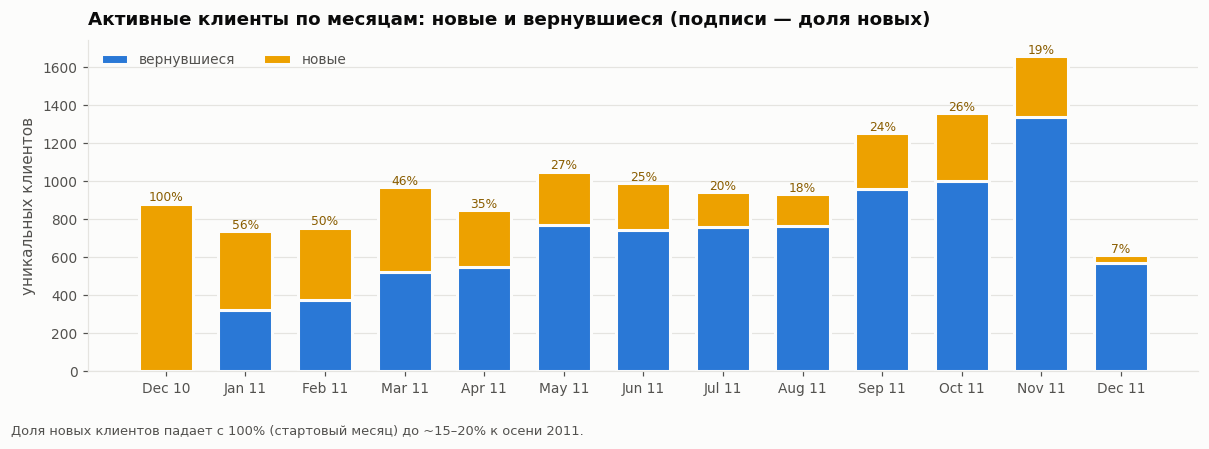

,вернувшиеся,новые,доля_новых
Month,,,
2010-12-01,0,882,1.000
2011-01-01,322,415,0.563
2011-02-01,376,380,0.503
2011-03-01,520,450,0.464
2011-04-01,549,300,0.353
2011-05-01,768,283,0.269
2011-06-01,745,244,0.247
2011-07-01,758,186,0.197
2011-08-01,763,169,0.181


In [31]:
# Новые vs вернувшиеся клиенты по месяцам — две серии, обе подписаны
first_m = invoices.groupby("CustomerID").Month.min()
act = invoices.groupby(["Month", "CustomerID"]).size().reset_index(name="n")
act["is_new"] = act.CustomerID.map(first_m) == act.Month
mix = act.groupby(["Month", "is_new"]).CustomerID.nunique().unstack(fill_value=0)
mix.columns = ["вернувшиеся", "новые"]

fig, ax = plt.subplots(figsize=(11, 3.8))
x = [f"{d:%b %y}" for d in mix.index]
# 2px «зазор» между сегментами стека делаем через edgecolor цвета фона
ax.bar(x, mix["вернувшиеся"], color=ACCENT, width=0.68, label="вернувшиеся", edgecolor=SURFACE, linewidth=2)
ax.bar(x, mix["новые"], bottom=mix["вернувшиеся"], color="#eda100", width=0.68, label="новые",
       edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(mix["вернувшиеся"], mix["новые"])):
    ax.text(i, a + b + 12, f"{100*b/(a+b):.0f}%", ha="center", fontsize=8, color="#8a5d00")
ax.set_title("Активные клиенты по месяцам: новые и вернувшиеся (подписи — доля новых)")
ax.set_ylabel("уникальных клиентов"); ax.legend(loc="upper left", ncols=2); ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", rotation=0)
finish(fig, "09_new_vs_returning", "Доля новых клиентов падает с 100% (стартовый месяц) до ~15–20% к осени 2011.")
display(mix.assign(доля_новых=(mix["новые"]/mix.sum(axis=1)).round(3)))

### Промежуточные выводы EDA

* Оборот растёт к **ноябрю 2011** (предрождественский пик, £1.13 млн против
  £0.44–0.65 млн в январе–августе); декабрь 2011 неполный, его нельзя сравнивать
  с другими месяцами.
* Внутри недели — устойчивый ритм (нет субботы, пик в четверг), внутри дня — рабочие
  часы 10:00–15:00. Компания не работала с 24.12.2010 по 03.01.2011: неделя,
  начинающаяся 27.12.2010, пуста для всех клиентов.
* База сильно неоднородна: **34.7% клиентов купили один раз**, топ-20% клиентов дают 74%
  оборота. Это прямо указывает на существование резко различных поведенческих сегментов.
* Приток новых клиентов сокращается к концу периода: значит, у «новичков» ноября 2011
  короткая история — их временные ряды нужно интерпретировать осторожно.

## 6. Извлечение признаков временных рядов (уровень клиента)

Считаем признаки четырёх групп:

| группа | признаки |
|---|---|
| **Объём и чек (RFM-монетарная часть)** | `monetary`, `n_orders`, `avg_order_value`, `median_order_value`, `cv_order_value`, `total_qty`, `avg_items_per_order`, `avg_unit_price`, `n_products` |
| **Частота и давность** | `recency_days`, `tenure_days`, `lifespan_days`, `orders_per_month`, `orders_per_week`, `active_weeks`, `active_months`, `active_week_rate`, `max_orders_per_week` |
| **Интервалы между покупками** | `ipt_mean`, `ipt_median`, `ipt_std`, `ipt_cv`, `ipt_max`, `burstiness` |
| **Сезонность, тренд, регулярность, возвраты** | `holiday_rev_share`, `q4_rev_share`, `season_ratio`, `month_entropy`, `week_entropy`, `dow_entropy`, `morning_share`, `trend_slope`, `h2_h1_log_ratio`, `return_rate`, `n_cancel` |

In [32]:
def norm_entropy(mat):
    "Нормированная энтропия Шеннона по строкам матрицы неотрицательных величин (0 = всё в одном бине, 1 = равномерно)."
    p = mat / np.where(mat.sum(axis=1, keepdims=True) == 0, 1, mat.sum(axis=1, keepdims=True))
    with np.errstate(divide="ignore", invalid="ignore"):
        h = -np.nansum(np.where(p > 0, p * np.log(p), 0.0), axis=1)
    k = (mat > 0).sum(axis=1)                     # число непустых бинов
    denom = np.log(max(mat.shape[1], 2))          # максимум энтропии = log(число бинов)
    return np.where(k <= 1, 0.0, h / denom)

def holiday_mask(dates):
    "Предрождественский сезон: ноябрь + 1–24 декабря."
    dates = pd.DatetimeIndex(dates)
    return (dates.month == 11) | ((dates.month == 12) & (dates.day <= 24))

# Календарь окна наблюдения -> сколько «праздничных» и «обычных» дней доступно каждому клиенту
cal = pd.date_range(OBS_START, OBS_END, freq="D")
cal_hol = holiday_mask(cal).astype(int)
cum_hol = np.concatenate([[0], np.cumsum(cal_hol)])          # cum_hol[i] = праздничных дней среди первых i
print(f"В окне наблюдения {len(cal)} дней, из них праздничных (ноя + 1–24 дек): {cal_hol.sum()}")

В окне наблюдения 374 дней, из них праздничных (ноя + 1–24 дек): 63


In [33]:
%%time
g = invoices.groupby("CustomerID")
f = pd.DataFrame(index=g.size().index.rename("CustomerID"))

# --- объём, чек, ассортимент ---
f["n_orders"]            = g.InvoiceNo.count()
f["monetary"]            = g.Amount.sum()
f["avg_order_value"]     = g.Amount.mean()
f["median_order_value"]  = g.Amount.median()
f["std_order_value"]     = g.Amount.std().fillna(0.0)
f["cv_order_value"]      = (f.std_order_value / f.avg_order_value).replace([np.inf, -np.inf], 0).fillna(0)
f["total_qty"]           = g.Qty.sum()
f["avg_items_per_order"] = g.NItems.mean()      # разных товарных позиций в счёте
f["n_products"]          = df.groupby("CustomerID").StockCode.nunique()
f["avg_unit_price"]      = f.monetary / f.total_qty

# --- давность, «возраст», частота ---
first_date, last_date = g.Date.min(), g.Date.max()
# Даты нормализуем к началу суток, а «возраст» клиента ограничиваем снизу одним днём:
# иначе у клиента, впервые купившего в последний день выгрузки, tenure = 0 и частота = inf.
f["recency_days"]  = (SNAPSHOT - last_date.dt.normalize()).dt.days
f["tenure_days"]   = (SNAPSHOT - first_date.dt.normalize()).dt.days.clip(lower=1)  # время наблюдения клиента
f["lifespan_days"] = (last_date.dt.normalize() - first_date.dt.normalize()).dt.days
f["orders_per_month"] = f.n_orders / (f.tenure_days / 30.44)
f["orders_per_week"]  = f.n_orders / (f.tenure_days / 7.0)

# --- интервалы между покупками (inter-purchase time, дни) ---
ipt = invoices.groupby("CustomerID").Date.diff().dt.total_seconds() / 86400
ipt_stats = ipt.groupby(invoices.CustomerID).agg(["mean", "median", "std", "max"])
ipt_stats.columns = ["ipt_mean", "ipt_median", "ipt_std", "ipt_max"]
f = f.join(ipt_stats)
f["is_one_time"] = (f.n_orders == 1).astype(int)
# У однократных покупателей интервал не определён: используем цензурированную оценку —
# всё доступное им время наблюдения (нижняя граница «настоящего» интервала).
for c in ["ipt_mean", "ipt_median", "ipt_max"]:
    f[c] = f[c].fillna(f.tenure_days.astype(float))
f["ipt_std"] = f.ipt_std.fillna(0.0)
f["ipt_cv"] = (f.ipt_std / f.ipt_mean).replace([np.inf, -np.inf], 0).fillna(0)
f["burstiness"] = ((f.ipt_std - f.ipt_mean) / (f.ipt_std + f.ipt_mean)).replace([np.inf, -np.inf], 0).fillna(0)

print("Признаков объёма/частоты/интервалов:", f.shape[1])
f.head(3)

Признаков объёма/частоты/интервалов: 22
CPU times: user 50.2 ms, sys: 26.9 ms, total: 77.1 ms
Wall time: 39.3 ms


,n_orders,monetary,avg_order_value,median_order_value,std_order_value,cv_order_value,total_qty,avg_items_per_order,n_products,avg_unit_price,recency_days,tenure_days,lifespan_days,orders_per_month,orders_per_week,ipt_mean,ipt_median,ipt_std,ipt_max,is_one_time,ipt_cv,burstiness
CustomerID,,,,,,,,,,,,,,,,,,,,,,
12347,7,"4,310.000",615.714,584.910,341.071,0.554,2458,26.000,103,1.753,3,368,365,0.579,0.133,60.840,58.460,18.401,90.151,0,0.302,-0.536
12348,4,"1,437.240",359.310,298.500,203.876,0.567,2332,5.750,21,0.616,76,359,283,0.339,0.078,94.251,70.003,69.953,173.101,0,0.742,-0.148
12349,1,"1,457.550","1,457.550","1,457.550",0.000,0.000,630,72.000,72,2.314,19,19,0,1.602,0.368,19.000,19.000,0.000,19.000,1,0.000,-1.000


In [34]:
%%time
# --- матрицы «клиент x период» (нужны и для признаков, и для кластеризации рядов) ---
week_index  = pd.date_range(invoices.Week.min(),  invoices.Week.max(),  freq="W-MON")
month_index = pd.date_range(invoices.Month.min(), invoices.Month.max(), freq="MS")

W_rev = (invoices.pivot_table(index="CustomerID", columns="Week", values="Amount", aggfunc="sum")
                 .reindex(columns=week_index).fillna(0.0))
W_cnt = (invoices.pivot_table(index="CustomerID", columns="Week", values="InvoiceNo", aggfunc="count")
                 .reindex(columns=week_index).fillna(0.0))
M_rev = (invoices.pivot_table(index="CustomerID", columns="Month", values="Amount", aggfunc="sum")
                 .reindex(columns=month_index).fillna(0.0))
D_rev = (invoices.pivot_table(index="CustomerID", columns="Day", values="Amount", aggfunc="sum")
                 .reindex(columns=pd.date_range(OBS_START, OBS_END, freq="D")).fillna(0.0))
print("W_rev:", W_rev.shape, "| W_cnt:", W_cnt.shape, "| M_rev:", M_rev.shape, "| D_rev:", D_rev.shape)

f["active_weeks"]  = (W_rev > 0).sum(axis=1)
f["max_orders_per_week"] = W_cnt.max(axis=1)      # пиковая недельная интенсивность заказов
f["active_months"] = (M_rev > 0).sum(axis=1)
f["active_week_rate"] = (f.active_weeks / np.maximum(f.tenure_days / 7.0, 1.0)).clip(0, 1)

# --- сезонность ---
# Маску праздничного сезона применяем к ДНЕВНОЙ матрице: недельная сетка ошибается на
# границах месяца (неделя 31.10–06.11.2011 — это 3% годового оборота, и по недельной
# маске она целиком попала бы в «не сезон»).
hol_rev = D_rev.loc[:, holiday_mask(D_rev.columns)].sum(axis=1).reindex(f.index).values
f["holiday_rev_share"] = np.clip(hol_rev / f.monetary.values, 0, 1)
# q4_rev_share — доля выручки в месяцах X–XII (в окне это декабрь 2010 и октябрь–декабрь 2011)
q4_cols_m = M_rev.columns.month.isin([10, 11, 12])
f["q4_rev_share"] = (M_rev.loc[:, q4_cols_m].sum(axis=1) / f.monetary).clip(0, 1)

# season_ratio: дневная интенсивность покупок в праздничный сезон / в обычные дни,
# знаменатели — только те дни, которые попали в окно наблюдения конкретного клиента.
start_pos = np.searchsorted(cal, first_date.dt.normalize().reindex(f.index).values)
hol_days  = cum_hol[-1] - cum_hol[start_pos]
all_days  = len(cal) - start_pos
base_days = np.maximum(all_days - hol_days, 1)
base_rev  = f.monetary.values - hol_rev
# Ограничиваем отношение сверху: у клиентов, купивших только в сезон, base_rev = 0
# и «чистое» отношение уходит в бесконечность.
rate_ratio = (hol_rev / np.maximum(hol_days, 1)) / np.maximum(base_rev / base_days, 1e-6)
f["season_ratio"] = np.log1p(np.clip(rate_ratio, 0, 50))

# --- регулярность распределения активности ---
f["month_entropy"] = norm_entropy(M_rev.reindex(f.index).values)
f["week_entropy"]  = norm_entropy(W_rev.reindex(f.index).values)
dow_mat = (invoices.pivot_table(index="CustomerID", columns="DayOfWeek", values="Amount", aggfunc="sum")
                   .reindex(columns=[0, 1, 2, 3, 4, 6]).fillna(0.0).reindex(f.index))
f["dow_entropy"] = norm_entropy(dow_mat.values)
f["morning_share"] = invoices.assign(m=(invoices.Hour < 12).astype(int)).groupby("CustomerID").m.mean()

# --- тренд внутри окна наблюдения ---
share_m = M_rev.div(M_rev.sum(axis=1), axis=0).fillna(0.0)      # профиль, свободный от масштаба клиента
xm = np.arange(share_m.shape[1]); xm_c = xm - xm.mean()
f["trend_slope"] = (share_m.values * xm_c).sum(axis=1) / (xm_c ** 2).sum()
half = OBS_START + (OBS_END - OBS_START) / 2
rev_h1 = invoices[invoices.Date <= half].groupby("CustomerID").Amount.sum().reindex(f.index).fillna(0)
rev_h2 = invoices[invoices.Date >  half].groupby("CustomerID").Amount.sum().reindex(f.index).fillna(0)
f["h2_h1_log_ratio"] = np.log1p(rev_h2) - np.log1p(rev_h1)

# --- возвраты и география ---
f = f.join(cancel_stats).fillna({"n_cancel": 0, "cancel_amount": 0.0})
f["return_rate"] = (f.cancel_amount / (f.cancel_amount + f.monetary)).clip(0, 1)
f["is_uk"] = (g.Country.first() == "United Kingdom").astype(int)
f = f.drop(columns=["cancel_amount", "std_order_value"])

print("Итоговая матрица признаков:", f.shape)
assert f.notna().all().all(), f.columns[f.isna().any()].tolist()
assert np.isfinite(f.values).all(), "в признаках остались inf"
f.to_pickle(CACHE_DIR / "features.pkl")
display(f.describe().T.round(3))

W_rev: (4322, 54) | W_cnt: (4322, 54) | M_rev: (4322, 13) | D_rev: (4322, 374)
Итоговая матрица признаков: (4322, 37)


,count,mean,std,min,25%,50%,75%,max
n_orders,"4,322.000",4.232,7.577,1.000,1.000,2.000,5.000,204.000
monetary,"4,322.000","1,930.988","8,331.486",2.900,301.420,656.430,"1,615.315","278,778.020"
avg_order_value,"4,322.000",376.443,540.108,2.900,175.030,286.861,423.127,"19,809.750"
median_order_value,"4,322.000",359.868,519.105,2.900,165.888,283.165,402.530,"19,809.750"
cv_order_value,"4,322.000",0.312,0.333,0.000,0.000,0.250,0.526,2.038
total_qty,"4,322.000","1,137.484","4,710.288",1.000,158.000,374.500,983.000,"196,556.000"
avg_items_per_order,"4,322.000",21.576,19.417,1.000,9.323,16.736,27.667,297.882
n_products,"4,322.000",61.263,84.963,1.000,16.000,35.000,77.000,"1,756.000"
avg_unit_price,"4,322.000",2.376,11.376,0.086,1.394,1.781,2.313,649.500
recency_days,"4,322.000",93.275,100.270,1.000,18.000,51.000,143.750,374.000


CPU times: user 77.1 ms, sys: 4.72 ms, total: 81.8 ms
Wall time: 80.5 ms


,avg_unit_price,total_qty,monetary,median_order_value,max_orders_per_week,avg_order_value,n_orders,orders_per_month,orders_per_week,n_cancel,n_products,return_rate
асимметрия,47.317,22.694,21.376,18.176,18.155,16.655,11.850,10.342,10.342,8.816,6.833,6.664


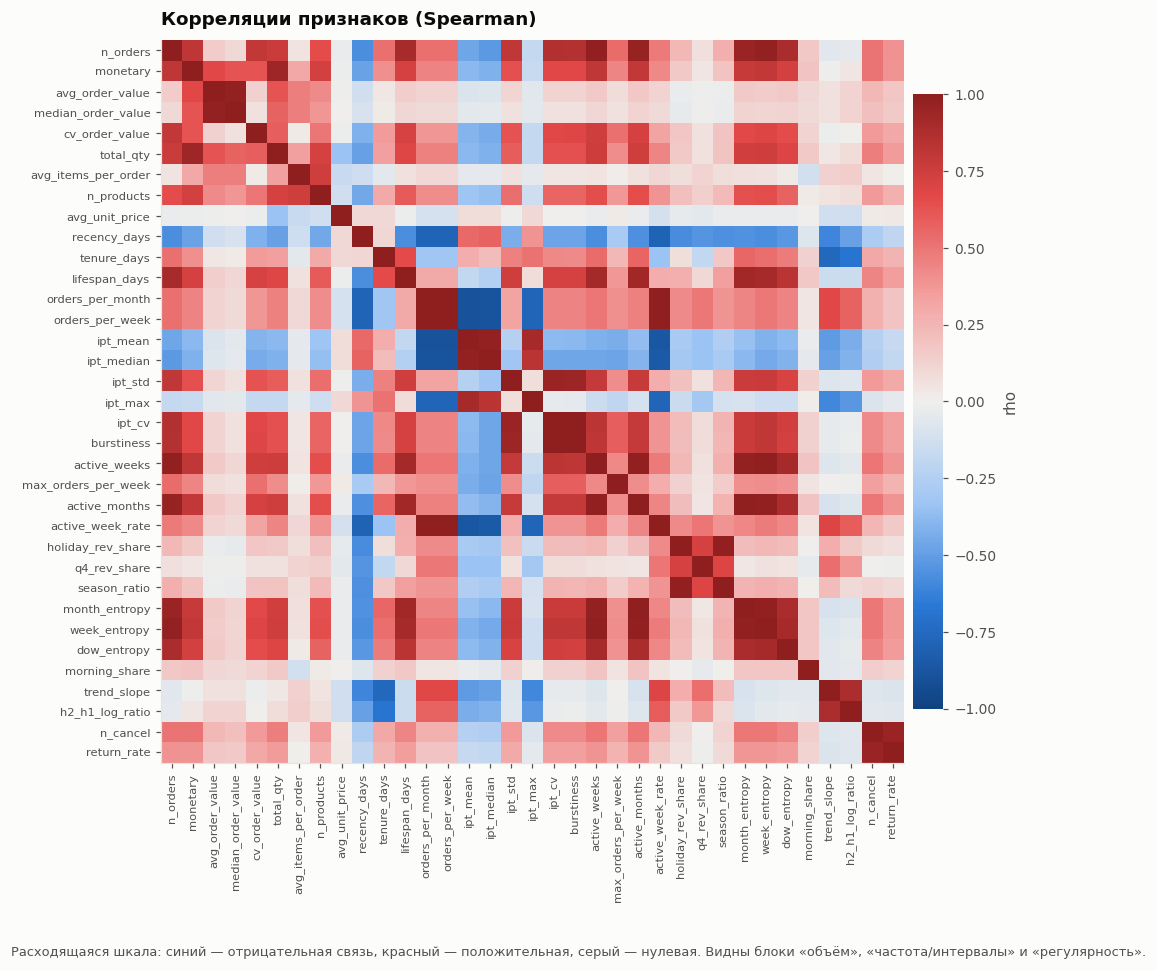

In [35]:
# Наиболее асимметричные признаки — кандидаты на лог-преобразование перед кластеризацией
sk = f.drop(columns=["is_uk", "is_one_time"]).skew().sort_values(ascending=False)
display(sk.to_frame("асимметрия").head(12).T)

fig, ax = plt.subplots(figsize=(9.6, 8.4))
num = f.drop(columns=["is_uk", "is_one_time"])
corr = num.corr(method="spearman")
im = ax.imshow(corr.values, cmap=DIV_BR, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=7.5)
ax.set_title("Корреляции признаков (Spearman)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01, shrink=.85); cb.set_label("rho", color=INK_2); cb.outline.set_visible(False)
finish(fig, "10_feature_corr", "Расходящаяся шкала: синий — отрицательная связь, красный — положительная, "
                               "серый — нулевая. Видны блоки «объём», «частота/интервалы» и «регулярность».")

## 7. Перевод транзакций в формат временных рядов

Построены четыре матрицы «клиент x период»:

* `D_rev` — дневная выручка (374 столбца) — очень разрежена, используется только для сезонных признаков;
* `W_rev`, `W_cnt` — **недельная** выручка и число заказов (54 недели; основное представление:
  достаточно точек для формы ряда и терпимая разреженность). Неделя, начинающаяся 27.12.2010,
  нулевая у всех клиентов — компания не работала. `W_rev` идёт в кластеризацию формы,
  из `W_cnt` берётся пиковая недельная интенсивность заказов;
* `M_rev` — **месячная** выручка (13 точек) — сглаженное представление для анализа сезонности.

In [36]:
sparsity = pd.DataFrame({
    "матрица": ["день (D_rev)", "неделя (W_rev)", "месяц (M_rev)"],
    "периодов": [D_rev.shape[1], W_rev.shape[1], M_rev.shape[1]],
    "% нулевых ячеек": [100*(D_rev == 0).mean().mean(), 100*(W_rev == 0).mean().mean(), 100*(M_rev == 0).mean().mean()],
    "среднее число активных периодов": [(D_rev > 0).sum(1).mean(), (W_rev > 0).sum(1).mean(), (M_rev > 0).sum(1).mean()],
}).round(2)
display(sparsity)

# Клиенты, пригодные для shape-based кластеризации рядов
ts_customers = f.index[f.n_orders >= MIN_ORDERS_TS]
print(f"Клиентов с >= {MIN_ORDERS_TS} заказами: {len(ts_customers):,} из {len(f):,} "
      f"({100*len(ts_customers)/len(f):.1f}%), их доля в обороте: "
      f"{100*f.loc[ts_customers, 'monetary'].sum()/f.monetary.sum():.1f}%")

,матрица,периодов,% нулевых ячеек,среднее число активных периодов
0,день (D_rev),374,98.970,3.840
1,неделя (W_rev),54,93.230,3.660
2,месяц (M_rev),13,76.880,3.010


Клиентов с >= 3 заказами: 1,988 из 4,322 (46.0%), их доля в обороте: 86.1%


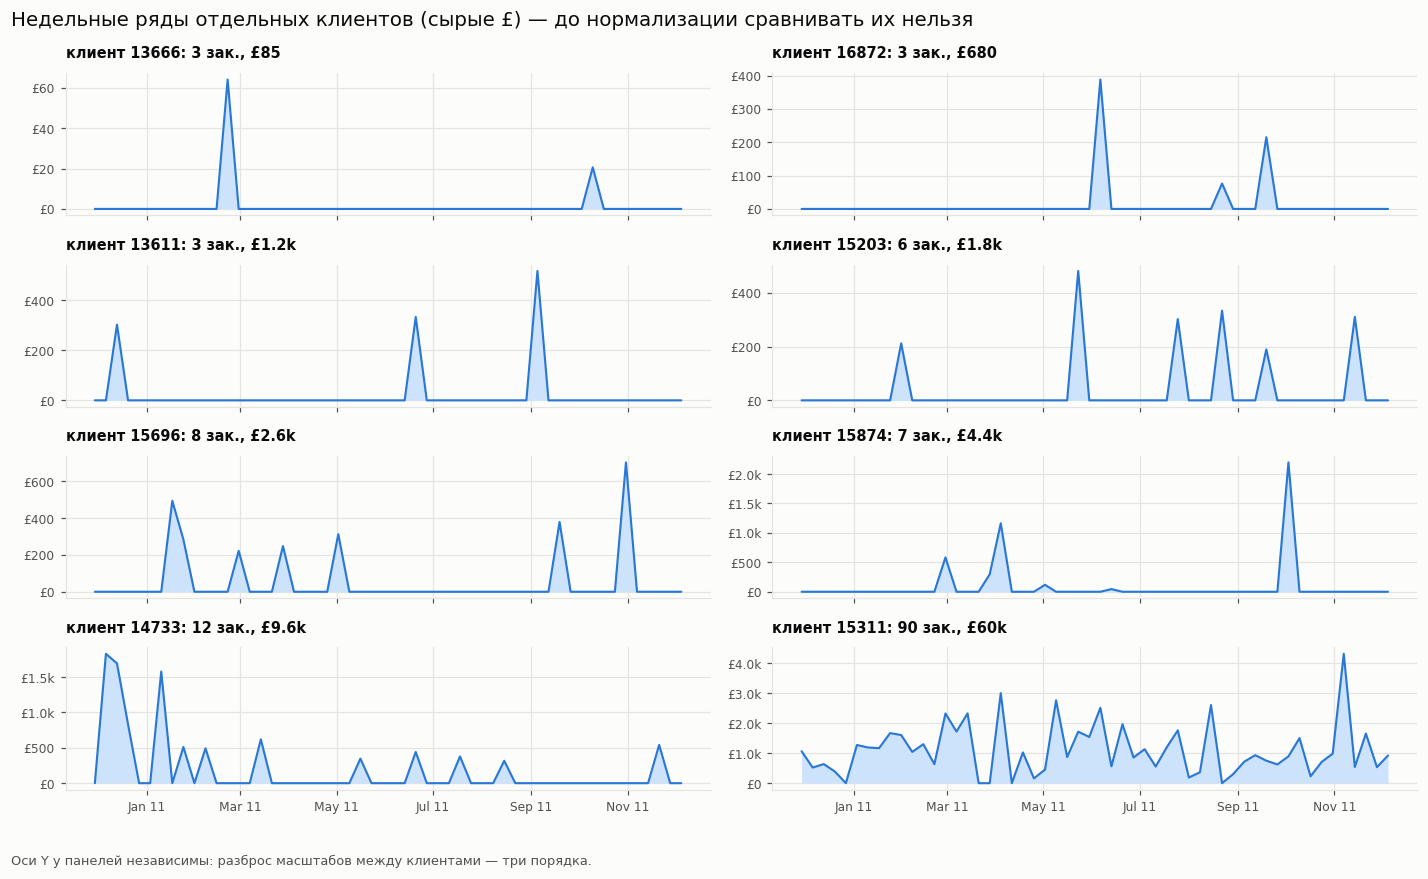

In [37]:
# Примеры индивидуальных недельных рядов: масштабы отличаются на порядки
np.random.seed(RANDOM_STATE)
_ordered = f.loc[ts_customers].sort_values("monetary").index
picks = _ordered[((np.array([.002, .15, .35, .55, .70, .85, .95, .995]) * (len(_ordered) - 1)).astype(int))]
fig, axes = plt.subplots(4, 2, figsize=(13, 7.6), sharex=True)
for ax, cid in zip(axes.ravel(), picks):
    y = W_rev.loc[cid]
    ax.fill_between(y.index, y.values, color="#cde2fb", lw=0)
    ax.plot(y.index, y.values, color=ACCENT, lw=1.4)
    ax.set_title(f"клиент {cid}: {int(f.at[cid,'n_orders'])} зак., {gbp(f.at[cid,'monetary'])}", fontsize=9.5)
    ax.yaxis.set_major_formatter(GBP)
    ax.tick_params(labelsize=8)
for ax in axes[-1]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.suptitle("Недельные ряды отдельных клиентов (сырые £) — до нормализации сравнивать их нельзя",
             x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "11_raw_customer_series", "Оси Y у панелей независимы: разброс масштабов между клиентами — три порядка.")

## 8. Нормализация

Две задачи требуют разной нормализации.

**(а) Признаковое пространство** (K-Means / Ward / DBSCAN по таблице `f`):
1. отбор по одному представителю на каждую поведенческую ось (объём, чек, частота,
   давность, ритм, постоянство, сезонность, тренд, возвраты, география). Слепое
   удаление всех пар с |Spearman| > 0.9 здесь недопустимо: у 35% клиентов с одной
   покупкой признаки ритма и сезонности вырождаются в одинаковые нули, из-за чего
   корреляция завышается и целые поведенческие оси исчезли бы из кластеризации;
2. винсоризация по 1/99 процентилю — экстремальные оптовики не смещают центроиды;
3. `log1p` для признаков с сильной правой асимметрией (`skew > 1`);
4. контроль остаточной коллинеарности порогом |Spearman| > 0.95;
5. `StandardScaler` (z-оценки) — все признаки в одном масштабе.

**(б) Сами временные ряды** (shape-based кластеризация):
* `log1p` — сжимает всплески оптовых закупок;
* сглаживание скользящим средним по 4 недели — убирает «гребёнку» разреженного ряда;
* **z-нормализация каждого ряда** (`TimeSeriesScalerMeanVariance`) — устраняет и уровень,
  и амплитуду клиента, оставляя только **форму** динамики. Именно это требуется, чтобы
  «крупный оптовик с ростом» и «мелкий покупатель с ростом» попали в один кластер;
* дополнительно — профиль долей (`x / sum(x)`) для месячных рядов: интерпретируется как
  «какая доля годовых покупок приходится на каждый месяц».

In [38]:
from sklearn.preprocessing import StandardScaler

# (1) по одному представителю на поведенческую ось
FEATURE_GROUPS = {
    "объём":         ["monetary"],
    "чек":           ["avg_order_value", "cv_order_value"],
    "корзина":       ["avg_items_per_order", "avg_unit_price"],
    "частота":       ["n_orders", "orders_per_month"],
    "давность":      ["recency_days"],
    "история":       ["tenure_days"],
    "ритм":          ["ipt_mean", "ipt_cv"],
    "постоянство":   ["active_week_rate", "month_entropy"],
    "сезонность":    ["holiday_rev_share"],
    "тренд":         ["trend_slope", "h2_h1_log_ratio"],
    "возвраты":      ["return_rate"],
    "география":     ["is_uk"],
}
FEATURES = [c for grp in FEATURE_GROUPS.values() for c in grp]
Xf = f[FEATURES].astype(float).copy()
print(f"Отобрано {len(FEATURES)} признаков по {len(FEATURE_GROUPS)} осям поведения")

# (2) винсоризация
lo, hi = Xf.quantile(0.01), Xf.quantile(0.99)
n_clipped = ((Xf < lo) | (Xf > hi)).sum().sum()
Xf = Xf.clip(lower=lo, upper=hi, axis=1)
print(f"Винсоризация 1/99: подрезано {n_clipped:,} значений ({100*n_clipped/Xf.size:.2f}% ячеек)")

# (3) log1p для правоасимметричных неотрицательных признаков
skewed = [c for c in Xf.columns if Xf[c].min() >= 0 and Xf[c].skew() > 1]
Xf[skewed] = np.log1p(Xf[skewed])
print(f"log1p применён к {len(skewed)} признакам:", ", ".join(skewed))

# (4) контроль остаточной коллинеарности
c = Xf.corr(method="spearman").abs()
upper = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
drop = [col for col in upper.columns if (upper[col] > 0.95).any()]
print(f"\nУдалены как почти дублирующие (|rho| > 0.95): {drop if drop else 'нет'}")
Xf = Xf.drop(columns=drop)

# (5) стандартизация
scaler = StandardScaler()
Xs = pd.DataFrame(scaler.fit_transform(Xf), index=Xf.index, columns=Xf.columns)
print(f"Признаковая матрица для кластеризации: {Xs.shape}")
print("Максимальная остаточная |rho| между признаками: %.2f"
      % Xf.corr("spearman").abs().where(np.triu(np.ones((Xf.shape[1],)*2), 1).astype(bool)).max().max())
display(Xs.describe().T[["mean", "std", "min", "max"]].round(2))

Отобрано 18 признаков по 12 осям поведения
Винсоризация 1/99: подрезано 1,025 значений (1.32% ячеек)
log1p применён к 11 признакам: monetary, avg_order_value, avg_items_per_order, avg_unit_price, n_orders, orders_per_month, recency_days, ipt_mean, active_week_rate, holiday_rev_share, return_rate

Удалены как почти дублирующие (|rho| > 0.95): ['active_week_rate', 'month_entropy']
Признаковая матрица для кластеризации: (4322, 16)
Максимальная остаточная |rho| между признаками: 0.90


,mean,std,min,max
monetary,0.000,1.000,-2.150,2.660
avg_order_value,-0.000,1.000,-2.620,2.810
cv_order_value,0.000,1.000,-0.950,3.060
avg_items_per_order,-0.000,1.000,-2.630,2.150
avg_unit_price,0.000,1.000,-2.140,3.600
n_orders,0.000,1.000,-0.970,3.170
orders_per_month,-0.000,1.000,-1.100,3.920
recency_days,-0.000,1.000,-2.130,1.580
tenure_days,0.000,1.000,-1.820,1.270
ipt_mean,-0.000,1.000,-3.860,1.610


In [39]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

SMOOTH = 4  # недели

Wts = W_rev.loc[ts_customers]
Wlog = np.log1p(Wts)
Wsm = Wlog.T.rolling(SMOOTH, min_periods=1).mean().T                    # сглаживание
TS_W = TimeSeriesScalerMeanVariance().fit_transform(Wsm.values)          # z-норма каждого ряда
TS_W_raw = TimeSeriesScalerMeanVariance().fit_transform(Wlog.values)     # без сглаживания (для сравнения)

Mts = M_rev.loc[ts_customers]
TS_M_share = (Mts.div(Mts.sum(axis=1), axis=0)).values[:, :, None]       # профиль долей месяца

print("TS_W:", TS_W.shape, "| TS_W_raw (без сглаживания):", TS_W_raw.shape,
      "| TS_M_share:", TS_M_share.shape)
print("Проверка z-нормы: mean ~ %.2e, std ~ %.3f" % (TS_W.mean(), TS_W.std()))

TS_W: (1988, 54, 1) | TS_W_raw (без сглаживания): (1988, 54, 1) | TS_M_share: (1988, 13, 1)
Проверка z-нормы: mean ~ 3.39e-19, std ~ 1.000


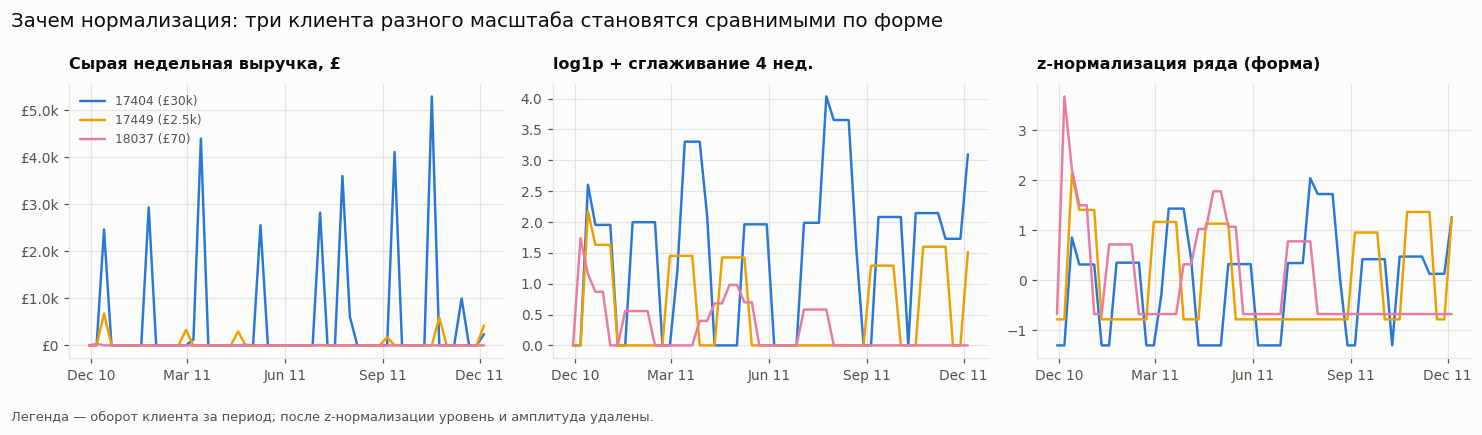

In [40]:
# Эффект нормализации на примере трёх очень разных клиентов
# берём клиентов с похожим числом заказов, но с оборотом, различающимся на порядки
_pool = f.loc[ts_customers].query("6 <= n_orders <= 12").sort_values("monetary")
ex = [_pool.index[-1], _pool.index[len(_pool) // 2], _pool.index[0]]
pos = {c: i for i, c in enumerate(ts_customers)}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
titles = ["Сырая недельная выручка, £", "log1p + сглаживание 4 нед.", "z-нормализация ряда (форма)"]
series = [lambda cid: W_rev.loc[cid].values,
          lambda cid: Wsm.loc[cid].values,
          lambda cid: TS_W[pos[cid], :, 0]]
for ax, ttl, fn in zip(axes, titles, series):
    for j, cid in enumerate(ex):
        ax.plot(week_index, fn(cid), color=CLUSTER_COLORS[j], lw=1.6,
                label=f"{cid} ({gbp(f.at[cid,'monetary'])})")
    ax.set_title(ttl, fontsize=10.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
axes[0].yaxis.set_major_formatter(GBP)
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Зачем нормализация: три клиента разного масштаба становятся сравнимыми по форме",
             x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "12_normalization", "Легенда — оборот клиента за период; после z-нормализации уровень и амплитуда удалены.")

## 9. Кластеризация в признаковом пространстве

Сначала кластеризуем клиентов по **агрегированным признакам временных рядов** (раздел 6).
Это даёт устойчивый, легко интерпретируемый каркас сегментации, с которым затем
сравним результат «чистой» кластеризации формы рядов (раздел 10).

### 9.1 Структура данных: PCA

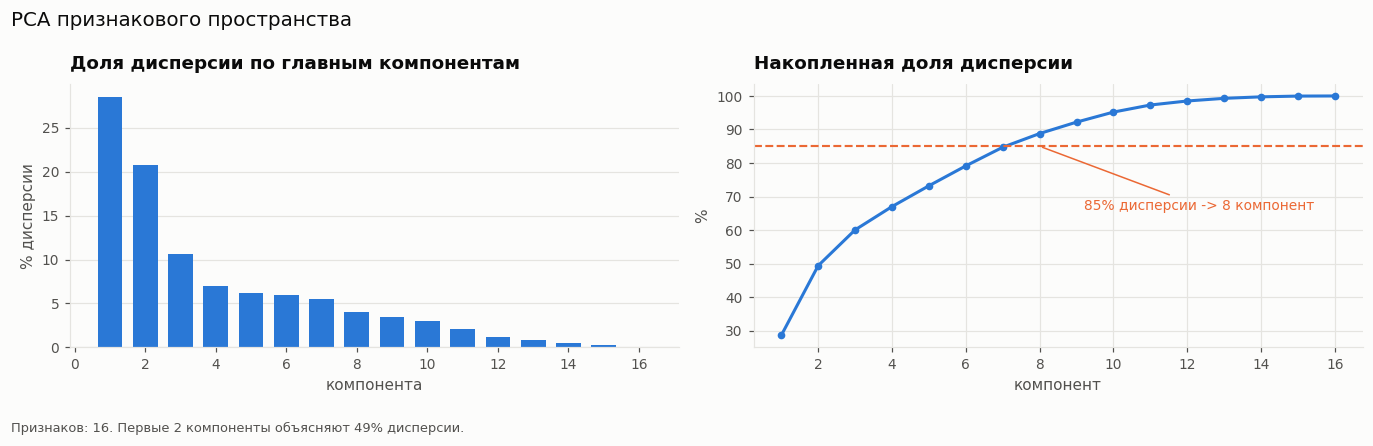

,PC1,PC2,PC3
recency_days,0.390,0.050,0.070
orders_per_month,-0.390,-0.150,-0.140
ipt_mean,0.350,0.110,0.160
n_orders,-0.330,0.340,-0.120
monetary,-0.320,0.320,0.260
trend_slope,-0.280,-0.400,0.040
ipt_cv,-0.280,0.290,-0.150
cv_order_value,-0.260,0.260,-0.150
h2_h1_log_ratio,-0.250,-0.380,0.080
holiday_rev_share,-0.170,-0.120,-0.160


In [41]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score, adjusted_mutual_info_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette

pca_full = PCA(random_state=RANDOM_STATE).fit(Xs.values)
evr = pca_full.explained_variance_ratio_
n85 = int(np.searchsorted(np.cumsum(evr), 0.85) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.7))
ax = axes[0]
ax.bar(np.arange(1, len(evr) + 1), evr * 100, color=ACCENT, width=0.7)
ax.set_title("Доля дисперсии по главным компонентам"); ax.set_xlabel("компонента"); ax.set_ylabel("% дисперсии")
ax.grid(axis="x", visible=False)
ax = axes[1]
cum = np.cumsum(evr) * 100
ax.plot(np.arange(1, len(evr) + 1), cum, color=ACCENT, marker="o", ms=4)
ax.axhline(85, color=ACCENT_2, ls="--", lw=1.4)
ax.annotate(f"85% дисперсии -> {n85} компонент", (n85, 85), xytext=(n85 + 1.2, 66),
            fontsize=9, color=ACCENT_2, arrowprops=dict(arrowstyle="-", color=ACCENT_2, lw=1))
ax.set_title("Накопленная доля дисперсии"); ax.set_xlabel("компонент"); ax.set_ylabel("%")
fig.suptitle("PCA признакового пространства", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "13_pca_variance", f"Признаков: {Xs.shape[1]}. Первые 2 компоненты объясняют {cum[1]:.0f}% дисперсии.")

loadings = pd.DataFrame(pca_full.components_[:3].T, index=Xs.columns, columns=["PC1", "PC2", "PC3"])
display(loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).head(10).round(2))

### 9.2 Выбор числа кластеров: метод локтя и анализ силуэта

Считаем четыре критерия для k = 2…10:
инерция (метод локтя), силуэт (чем больше, тем лучше), индекс Дэвиса–Болдина (меньше — лучше),
индекс Калински–Харабаса (больше — лучше). «Локоть» находим формально —
как точку максимального удаления кривой инерции от хорды, соединяющей её концы.

In [42]:
%%time
K_RANGE = list(range(2, 11))
rows = []
km_models = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xs.values)
    km_models[k] = km
    lab = km.labels_
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Xs.values, lab),
                 "davies_bouldin": davies_bouldin_score(Xs.values, lab),
                 "calinski_harabasz": calinski_harabasz_score(Xs.values, lab),
                 "min_cluster_%": 100 * np.bincount(lab).min() / len(lab)})
sel = pd.DataFrame(rows).set_index("k")

def elbow_k(idx, values):
    "Формальный «локоть»: точка кривой, максимально удалённая от хорды между её концами."
    x = np.asarray(idx, float); y = np.asarray(values, float)
    xn = (x - x.min()) / (x.max() - x.min()); yn = (y - y.min()) / (y.max() - y.min())
    x0, y0, x1, y1 = xn[0], yn[0], xn[-1], yn[-1]
    dx, dy = x1 - x0, y1 - y0
    # расстояние от точки до хорды (векторное произведение в 2D, записанное явно:
    # np.cross для двумерных векторов удалён в numpy >= 2.0)
    d = np.abs(dx * (yn - y0) - dy * (xn - x0)) / np.hypot(dx, dy)
    return int(x[d.argmax()])

K_ELBOW = elbow_k(sel.index, sel.inertia)
# Комбинированный выбор среди бизнес-осмысленных k (2 кластера = вырожденное «много/мало»,
# больше 6 сегментов не поддаётся раздельной интерпретации):
cand = sel.loc[3:6]
rank = (cand.silhouette.rank(ascending=False) + cand.davies_bouldin.rank(ascending=True)
        + cand.calinski_harabasz.rank(ascending=False))
K_FEAT = int(rank.idxmin())
display(sel.round(3))
print(f"Локоть кривой инерции: k = {K_ELBOW}")
print("Сумма рангов по трём индексам (k=3..6):", rank.round(1).to_dict())
print(f"=> выбрано K_FEAT = {K_FEAT}")

,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_%
k,,,,,
2,"55,968.458",0.183,1.950,"1,017.589",49.607
3,"46,211.991",0.215,1.564,"1,071.993",30.819
4,"42,132.048",0.203,1.605,923.068,13.096
5,"39,524.424",0.173,1.804,809.008,13.651
6,"36,970.949",0.180,1.659,751.365,2.869
7,"34,760.025",0.187,1.549,711.553,2.545
8,"33,237.673",0.192,1.546,665.916,2.453
9,"32,001.068",0.183,1.704,625.890,2.453
10,"30,917.544",0.158,1.698,592.497,2.453


Локоть кривой инерции: k = 4
Сумма рангов по трём индексам (k=3..6): {3: 3.0, 4: 6.0, 5: 11.0, 6: 10.0}
=> выбрано K_FEAT = 3
CPU times: user 2min 32s, sys: 3min 7s, total: 5min 39s
Wall time: 22 s


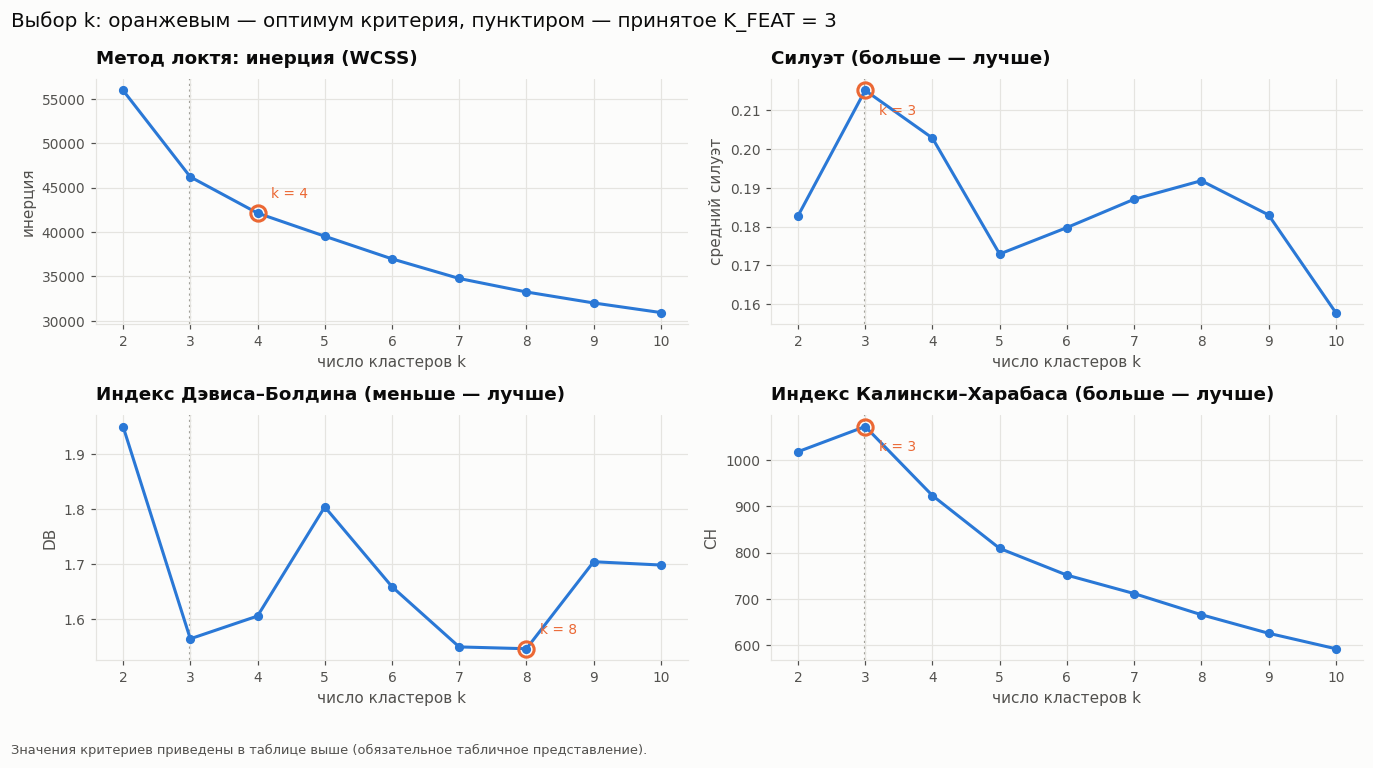

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.6))
panels = [("inertia", "Метод локтя: инерция (WCSS)", "инерция", True),
          ("silhouette", "Силуэт (больше — лучше)", "средний силуэт", False),
          ("davies_bouldin", "Индекс Дэвиса–Болдина (меньше — лучше)", "DB", False),
          ("calinski_harabasz", "Индекс Калински–Харабаса (больше — лучше)", "CH", False)]
for ax, (col, ttl, ylab, mark_elbow) in zip(axes.ravel(), panels):
    ax.plot(sel.index, sel[col], color=ACCENT, marker="o", ms=5)
    best = K_ELBOW if mark_elbow else (sel[col].idxmax() if col != "davies_bouldin" else sel[col].idxmin())
    ax.plot([best], [sel.loc[best, col]], marker="o", ms=10, mfc="none", mec=ACCENT_2, mew=2)
    lo_, hi_ = ax.get_ylim()
    dy = -16 if sel.loc[best, col] > lo_ + 0.85 * (hi_ - lo_) else 10
    ax.annotate(f"k = {best}", (best, sel.loc[best, col]), xytext=(9, dy), textcoords="offset points",
                fontsize=9, color=ACCENT_2)
    ax.axvline(K_FEAT, color=NEUTRAL, ls=":", lw=1.4, zorder=0)
    ax.set_title(ttl); ax.set_xlabel("число кластеров k"); ax.set_ylabel(ylab)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.suptitle(f"Выбор k: оранжевым — оптимум критерия, пунктиром — принятое K_FEAT = {K_FEAT}",
             x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "14_k_selection", "Значения критериев приведены в таблице выше (обязательное табличное представление).")

Размеры кластеров: {0: 1397, 1: 1332, 2: 1593}
Средний силуэт при k=3: 0.215


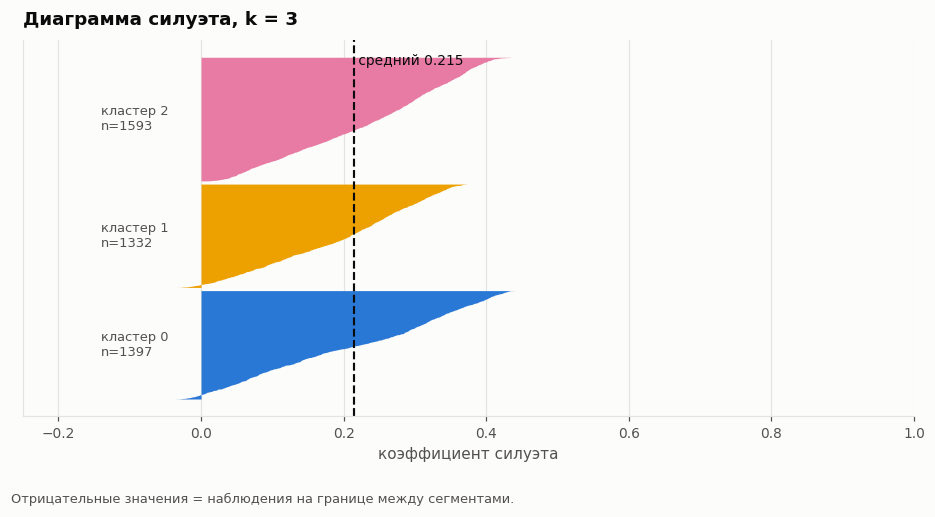

In [44]:
km_final = km_models[K_FEAT]
labels_km = pd.Series(km_final.labels_, index=Xs.index, name="cluster_km")
sizes = labels_km.value_counts().sort_index()
print("Размеры кластеров:", sizes.to_dict())
print(f"Средний силуэт при k={K_FEAT}: {sel.loc[K_FEAT,'silhouette']:.3f}")

# Диаграмма силуэта — видно, есть ли кластеры с массово отрицательным силуэтом
sv = silhouette_samples(Xs.values, labels_km.values)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
y0 = 0
for cl in range(K_FEAT):
    v = np.sort(sv[labels_km.values == cl])
    ax.fill_betweenx(np.arange(y0, y0 + len(v)), 0, v, color=cl_color(cl), lw=0)
    ax.text(-0.14, y0 + len(v) / 2, f"кластер {cl}\nn={len(v)}", fontsize=8.5, color=INK_2, va="center")
    y0 += len(v) + 40
ax.axvline(sv.mean(), color=INK, ls="--", lw=1.4)
ax.text(sv.mean(), y0, f" средний {sv.mean():.3f}", fontsize=9, color=INK, va="top")
ax.set_title(f"Диаграмма силуэта, k = {K_FEAT}"); ax.set_xlabel("коэффициент силуэта")
ax.set_yticks([]); ax.grid(axis="y", visible=False); ax.set_xlim(-0.25, 1.0)
finish(fig, "15_silhouette_diagram", "Отрицательные значения = наблюдения на границе между сегментами.")

### 9.3 Иерархическая кластеризация (Ward)

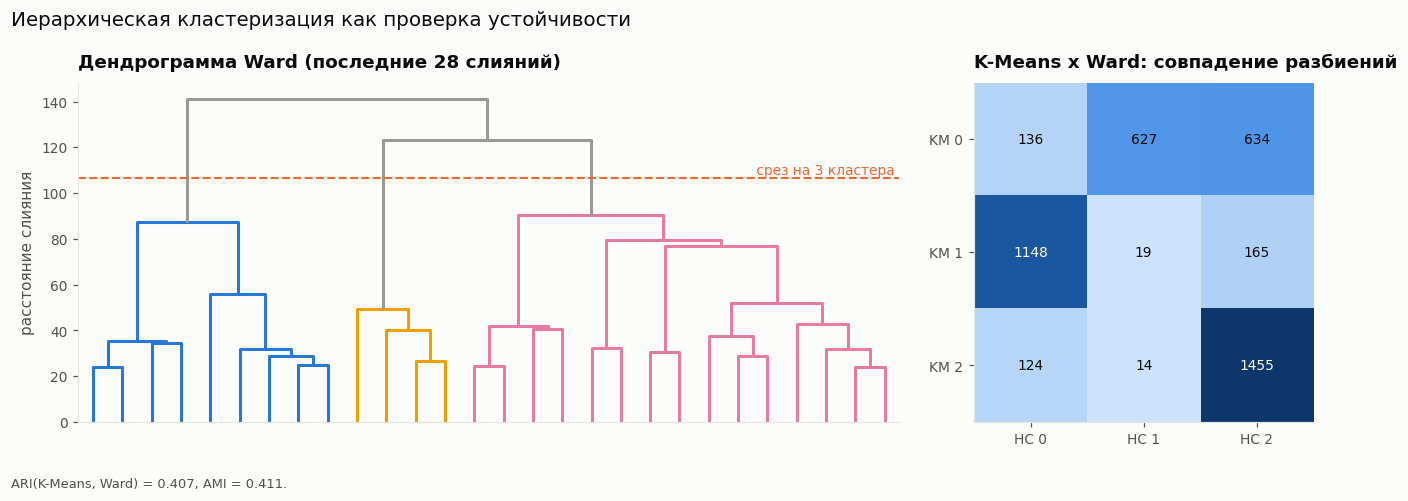

Размеры кластеров Ward: {0: 1408, 1: 660, 2: 2254}


Силуэт Ward: 0.156
ARI(K-Means, Ward) = 0.407 | AMI = 0.411
CPU times: user 1.16 s, sys: 3.08 s, total: 4.25 s
Wall time: 900 ms


In [45]:
%%time
Z = linkage(Xs.values, method="ward")
labels_hc = pd.Series(fcluster(Z, t=K_FEAT, criterion="maxclust") - 1, index=Xs.index, name="cluster_hc")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw=dict(width_ratios=[1.5, 1]))
ax = axes[0]
# Порог отсечения, дающий K_FEAT кластеров
heights = np.sort(Z[:, 2])
cut = (heights[-K_FEAT] + heights[-K_FEAT + 1]) / 2 if K_FEAT > 1 else heights[-1]
set_link_color_palette(CLUSTER_COLORS)      # ветви — в цветах кластерной палитры
dendrogram(Z, truncate_mode="lastp", p=28, color_threshold=cut, above_threshold_color=NEUTRAL,
           no_labels=True, ax=ax)
ax.axhline(cut, color=ACCENT_2, ls="--", lw=1.4)
ax.text(ax.get_xlim()[1], cut, f" срез на {K_FEAT} кластера ", ha="right", va="bottom", fontsize=9, color=ACCENT_2)
ax.set_title("Дендрограмма Ward (последние 28 слияний)"); ax.set_ylabel("расстояние слияния")
ax.grid(False)

ax = axes[1]
ct = pd.crosstab(labels_km, labels_hc)
im = ax.imshow(ct.values, cmap=SEQ_BLUE)
ax.set_xticks(range(ct.shape[1]), [f"HC {c}" for c in ct.columns])
ax.set_yticks(range(ct.shape[0]), [f"KM {r}" for r in ct.index])
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, f"{v}", ha="center", va="center", fontsize=9,
                color="white" if v > ct.values.max() * 0.55 else INK)
ax.set_title("K-Means x Ward: совпадение разбиений"); ax.grid(False)

fig.suptitle("Иерархическая кластеризация как проверка устойчивости", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "16_ward", f"ARI(K-Means, Ward) = {adjusted_rand_score(labels_km, labels_hc):.3f}, "
                       f"AMI = {adjusted_mutual_info_score(labels_km, labels_hc):.3f}.")
print("Размеры кластеров Ward:", labels_hc.value_counts().sort_index().to_dict())
print("Силуэт Ward: %.3f" % silhouette_score(Xs.values, labels_hc))
print("ARI(K-Means, Ward) = %.3f | AMI = %.3f" % (adjusted_rand_score(labels_km, labels_hc),
                                                  adjusted_mutual_info_score(labels_km, labels_hc)))

### 9.4 DBSCAN

DBSCAN не требует задавать число кластеров, но в многомерном признаковом пространстве
плотность падает, поэтому работаем в пространстве первых главных компонент (85% дисперсии).
Параметр `eps` подбираем по графику расстояний до k-го соседа («k-distance», k = 2·dim − 1).

n85 = 8 компонент, min_samples = 15, eps = 2.03
Кластеров DBSCAN (без шума): 2, шум: 247 (5.7% клиентов)


cluster_db,-1,0,1
клиентов,247,339,3736


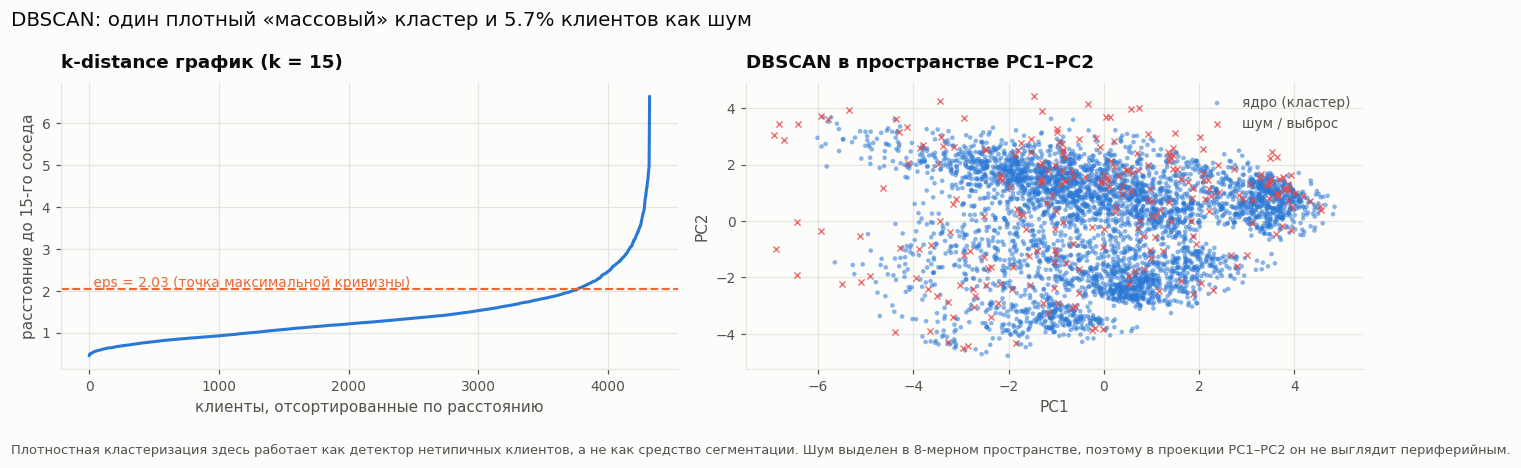

ARI(K-Means, DBSCAN) = -0.000

Чем отличаются «шумовые» клиенты (медианы):


,n_orders,monetary,avg_order_value,recency_days,ipt_mean,return_rate
noise,,,,,,
False,2.000,661.520,290.510,51.000,66.940,0.000
True,2.000,515.730,232.300,65.000,38.110,0.130


In [46]:
Xp = PCA(n_components=n85, random_state=RANDOM_STATE).fit_transform(Xs.values)
min_samples = 2 * n85 - 1
kdist = np.sort(NearestNeighbors(n_neighbors=min_samples).fit(Xp).kneighbors(Xp)[0][:, -1])
EPS = float(np.round(kdist[elbow_k(np.arange(len(kdist)), kdist)], 2))

db = DBSCAN(eps=EPS, min_samples=min_samples).fit(Xp)
labels_db = pd.Series(db.labels_, index=Xs.index, name="cluster_db")
n_noise = int((labels_db == -1).sum())
print(f"n85 = {n85} компонент, min_samples = {min_samples}, eps = {EPS}")
print(f"Кластеров DBSCAN (без шума): {labels_db[labels_db >= 0].nunique()}, шум: {n_noise} "
      f"({100*n_noise/len(labels_db):.1f}% клиентов)")
display(labels_db.value_counts().sort_index().to_frame("клиентов").T)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
ax = axes[0]
ax.plot(np.arange(len(kdist)), kdist, color=ACCENT)
ax.axhline(EPS, color=ACCENT_2, ls="--", lw=1.4)
ax.text(0, EPS, f" eps = {EPS} (точка максимальной кривизны)", fontsize=9, color=ACCENT_2, va="bottom")
ax.set_title(f"k-distance график (k = {min_samples})")
ax.set_xlabel("клиенты, отсортированные по расстоянию"); ax.set_ylabel(f"расстояние до {min_samples}-го соседа")

ax = axes[1]
noise = labels_db.values == -1
ax.scatter(Xp[~noise, 0], Xp[~noise, 1], s=9, color=ACCENT, alpha=.55, edgecolor="none", label="ядро (кластер)")
ax.scatter(Xp[noise, 0], Xp[noise, 1], s=16, color="#e34948", alpha=.8, marker="x", lw=.9, label="шум / выброс")
ax.set_title("DBSCAN в пространстве PC1–PC2"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc="upper right")
fig.suptitle(f"DBSCAN: один плотный «массовый» кластер и {100*n_noise/len(labels_db):.1f}% клиентов как шум",
             x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "17_dbscan", "Плотностная кластеризация здесь работает как детектор нетипичных клиентов, а не как "
                          "средство сегментации. Шум выделен в 8-мерном пространстве, поэтому в проекции "
                          "PC1–PC2 он не выглядит периферийным.")
print("ARI(K-Means, DBSCAN) = %.3f" % adjusted_rand_score(labels_km, labels_db))
print("\nЧем отличаются «шумовые» клиенты (медианы):")
display(f.assign(noise=noise).groupby("noise")[["n_orders", "monetary", "avg_order_value",
        "recency_days", "ipt_mean", "return_rate"]].median().round(2))

### 9.5 Визуализация сегментов: PCA и t-SNE

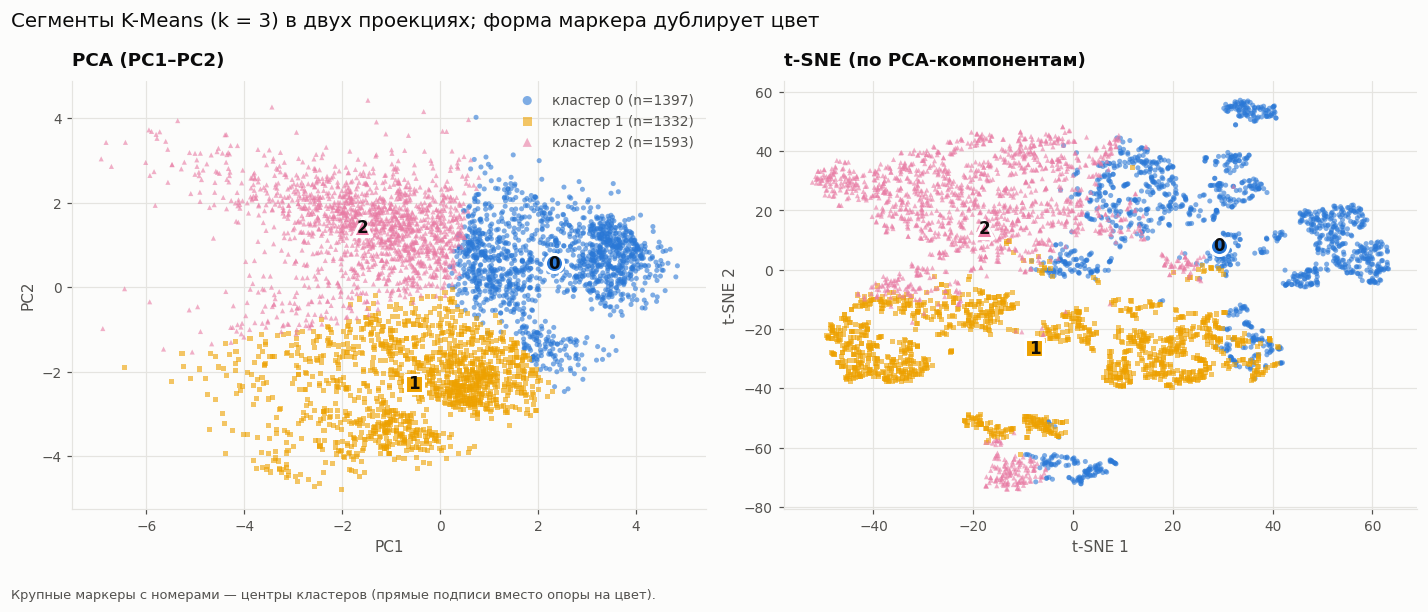

CPU times: user 35.9 s, sys: 417 ms, total: 36.3 s
Wall time: 4.92 s


In [47]:
%%time
tsne = TSNE(n_components=2, perplexity=35, init="pca", learning_rate="auto",
            random_state=RANDOM_STATE).fit_transform(Xp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, XY, ttl, xl, yl in [(axes[0], Xp[:, :2], "PCA (PC1–PC2)", "PC1", "PC2"),
                            (axes[1], tsne, "t-SNE (по PCA-компонентам)", "t-SNE 1", "t-SNE 2")]:
    for cl in range(K_FEAT):
        m = labels_km.values == cl
        ax.scatter(XY[m, 0], XY[m, 1], s=11, alpha=.6, color=cl_color(cl), marker=cl_marker(cl),
                   edgecolor="none", label=f"кластер {cl} (n={m.sum()})")
        cx, cy = XY[m, 0].mean(), XY[m, 1].mean()
        ax.scatter([cx], [cy], s=140, color=cl_color(cl), marker=cl_marker(cl),
                   edgecolor="white", linewidth=2, zorder=5)
        ax.annotate(str(cl), (cx, cy), fontsize=11, fontweight="bold", color=INK,
                    ha="center", va="center", zorder=6)
    ax.set_title(ttl); ax.set_xlabel(xl); ax.set_ylabel(yl)
axes[0].legend(loc="upper right", markerscale=1.8)
fig.suptitle(f"Сегменты K-Means (k = {K_FEAT}) в двух проекциях; форма маркера дублирует цвет",
             x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "18_projections", "Крупные маркеры с номерами — центры кластеров (прямые подписи вместо опоры на цвет).")

## 10. Кластеризация самих временных рядов (shape-based)

Теперь кластеризуем **формы** недельных рядов покупок: `TimeSeriesKMeans` из `tslearn`
с метриками **Euclidean**, **DTW** (Dynamic Time Warping) и **Soft-DTW**.
DTW позволяет считать похожими ряды со сдвинутыми во времени, но одинаковыми по форме
всплесками — именно то, что нужно для «сезонных» и «эпизодических» покупателей.

Для DTW используем окно Сакоэ–Чиба (`radius = 3` недели): это ограничивает
физически осмысленный сдвиг, ускоряет расчёт и не даёт метрике «схлопывать» разные ритмы.

In [48]:
from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette

DTW_PARAMS = {"global_constraint": "sakoe_chiba", "sakoe_chiba_radius": 3}
SIL_SAMPLE = 700   # силуэт с метрикой DTW — O(n^2), поэтому считаем на подвыборке

def fit_ts_kmeans(X, k, metric="dtw", n_init=1, max_iter=10, seed=RANDOM_STATE):
    "TimeSeriesKMeans с единообразными параметрами: DTW — с окном Сакоэ–Чиба, Soft-DTW — с gamma=1."
    mp = DTW_PARAMS if metric in ("dtw", "softdtw") else None
    kw = {}
    if metric != "euclidean":
        kw["max_iter_barycenter"] = 5
    if metric == "softdtw":
        mp = {"gamma": 1.0}
    return TimeSeriesKMeans(n_clusters=k, metric=metric, metric_params=mp, n_init=n_init,
                            max_iter=max_iter, random_state=seed, n_jobs=-1, **kw).fit(X)

print("Матрица рядов для кластеризации:", TS_W.shape, "(клиенты x недели x 1)")

Матрица рядов для кластеризации: (1988, 54, 1) (клиенты x недели x 1)


In [49]:
%%time
# Подбор k для DTW-кластеризации: инерция (локоть) + силуэт в метрике DTW
rng = np.random.RandomState(RANDOM_STATE)
sil_idx = rng.choice(len(TS_W), min(SIL_SAMPLE, len(TS_W)), replace=False)

ts_rows, ts_models = [], {}
for k in range(2, 8):
    m = fit_ts_kmeans(TS_W, k, "dtw")
    ts_models[k] = m
    lab = m.labels_
    ts_rows.append({"k": k, "inertia": m.inertia_,
                    "silhouette_dtw": ts_silhouette(TS_W[sil_idx], lab[sil_idx], metric="dtw",
                                                    metric_params=DTW_PARAMS, n_jobs=-1),
                    "min_cluster_%": 100 * np.bincount(lab).min() / len(lab)})
ts_sel = pd.DataFrame(ts_rows).set_index("k")
K_TS_ELBOW = elbow_k(ts_sel.index, ts_sel.inertia)
K_TS = int(ts_sel.loc[3:6, "silhouette_dtw"].idxmax())
display(ts_sel.round(4))
print(f"Локоть: k = {K_TS_ELBOW}; максимум DTW-силуэта на k=3..6: K_TS = {K_TS}")

,inertia,silhouette_dtw,min_cluster_%
k,,,
2,30.254,0.086,46.730
3,27.184,0.099,24.095
4,25.159,0.094,15.342
5,23.546,0.109,10.312
6,22.312,0.109,10.362
7,21.645,0.103,10.211


Локоть: k = 4; максимум DTW-силуэта на k=3..6: K_TS = 5
CPU times: user 5min 13s, sys: 1min 10s, total: 6min 24s
Wall time: 5min 7s


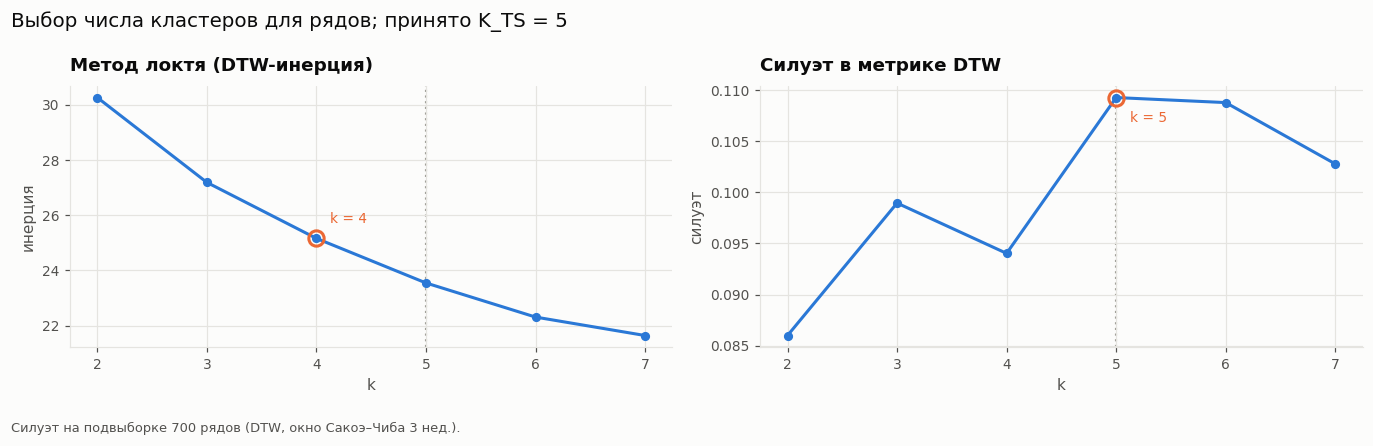

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.7))
for ax, (col, ttl, ylab, best) in zip(axes, [
        ("inertia", "Метод локтя (DTW-инерция)", "инерция", K_TS_ELBOW),
        ("silhouette_dtw", "Силуэт в метрике DTW", "силуэт", int(ts_sel.silhouette_dtw.idxmax()))]):
    ax.plot(ts_sel.index, ts_sel[col], color=ACCENT, marker="o", ms=5)
    ax.plot([best], [ts_sel.loc[best, col]], marker="o", ms=10, mfc="none", mec=ACCENT_2, mew=2)
    lo_, hi_ = ax.get_ylim()
    dy = -16 if ts_sel.loc[best, col] > lo_ + 0.85 * (hi_ - lo_) else 10
    ax.annotate(f"k = {best}", (best, ts_sel.loc[best, col]), xytext=(9, dy), textcoords="offset points",
                fontsize=9, color=ACCENT_2)
    ax.axvline(K_TS, color=NEUTRAL, ls=":", lw=1.4, zorder=0)
    ax.set_title(ttl); ax.set_xlabel("k"); ax.set_ylabel(ylab)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.suptitle(f"Выбор числа кластеров для рядов; принято K_TS = {K_TS}", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "19_ts_k_selection", f"Силуэт на подвыборке {len(sil_idx)} рядов (DTW, окно Сакоэ–Чиба 3 нед.).")

In [51]:
%%time
# Финальные модели: три метрики при одном и том же k — для сравнения устойчивости
ts_final = {}
for metric in ["euclidean", "dtw", "softdtw"]:
    ts_final[metric] = fit_ts_kmeans(TS_W, K_TS, metric, n_init=3 if metric == "euclidean" else 2,
                                     max_iter=15 if metric == "euclidean" else 10)
    print(f"{metric:10s} inertia={ts_final[metric].inertia_:10.2f} sizes={np.bincount(ts_final[metric].labels_)}")

labels_ts = pd.Series(ts_final["dtw"].labels_, index=ts_customers, name="cluster_ts")
cmp_rows = []
for a in ts_final:
    for b in ts_final:
        if a < b:
            cmp_rows.append({"метрика A": a, "метрика B": b,
                             "ARI": adjusted_rand_score(ts_final[a].labels_, ts_final[b].labels_),
                             "AMI": adjusted_mutual_info_score(ts_final[a].labels_, ts_final[b].labels_)})
display(pd.DataFrame(cmp_rows).round(3))
print("Силуэт (DTW) финальной модели: %.4f" % ts_silhouette(TS_W[sil_idx], labels_ts.values[sil_idx],
      metric="dtw", metric_params=DTW_PARAMS, n_jobs=-1))

euclidean  inertia=     40.81 sizes=[526 203 586 376 297]


dtw        inertia=     23.55 sizes=[205 501 563 372 347]


softdtw    inertia=   2823.65 sizes=[211 461 294 497 525]


,метрика A,метрика B,ARI,AMI
0,euclidean,softdtw,0.325,0.450
1,dtw,euclidean,0.432,0.507
2,dtw,softdtw,0.327,0.438


Силуэт (DTW) финальной модели: 0.1093
CPU times: user 7min 14s, sys: 57.8 s, total: 8min 12s
Wall time: 3min 56s


In [52]:
%%time
# Проверка методического выбора: то же разбиение на НЕсглаженных рядах.
# Если сглаживание не помогает, силуэт не должен ухудшаться при его отключении.
m_raw = fit_ts_kmeans(TS_W_raw, K_TS, "dtw", n_init=2, max_iter=10)
sil_raw = ts_silhouette(TS_W_raw[sil_idx], m_raw.labels_[sil_idx], metric="dtw",
                        metric_params=DTW_PARAMS, n_jobs=-1)
sil_sm = ts_silhouette(TS_W[sil_idx], labels_ts.values[sil_idx], metric="dtw",
                       metric_params=DTW_PARAMS, n_jobs=-1)
display(pd.DataFrame({
    "представление": [f"log1p + сглаживание {SMOOTH} нед.", "log1p без сглаживания"],
    "силуэт (DTW)":  [round(sil_sm, 4), round(sil_raw, 4)],
    "инерция":       [round(ts_final["dtw"].inertia_, 2), round(m_raw.inertia_, 2)],
    "размеры кластеров": [list(np.bincount(labels_ts.values)), list(np.bincount(m_raw.labels_))],
}))
print("ARI(сглаженные, несглаженные) = %.3f" % adjusted_rand_score(labels_ts, m_raw.labels_))

,представление,силуэт (DTW),инерция,размеры кластеров
0,log1p + сглаживание 4 нед.,0.109,23.550,"[205, 501, 563, 372, 347]"
1,log1p без сглаживания,0.064,25.430,"[488, 333, 344, 311, 512]"


ARI(сглаженные, несглаженные) = 0.129
CPU times: user 1min 34s, sys: 22.5 s, total: 1min 57s
Wall time: 1min 30s


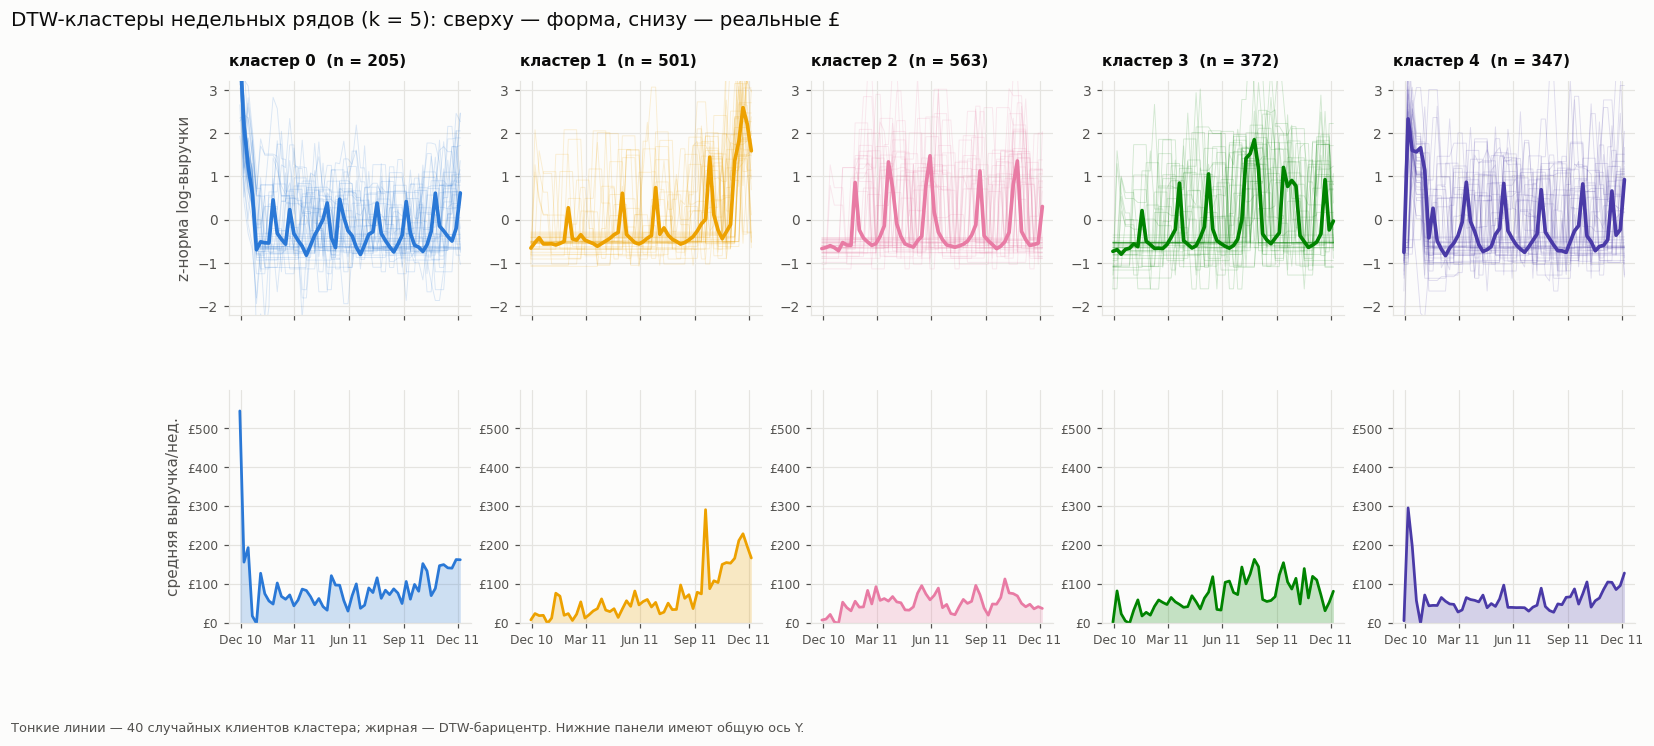

In [53]:
# Центроиды (DTW-барицентры) и веер индивидуальных рядов внутри каждого кластера
n_col = K_TS
fig, axes = plt.subplots(2, n_col, figsize=(3.3 * n_col, 6.4), sharex=True,
                         gridspec_kw=dict(hspace=0.32))
rng = np.random.RandomState(RANDOM_STATE)
for cl in range(K_TS):
    m = labels_ts.values == cl
    # верхний ряд: z-нормализованная форма
    ax = axes[0, cl]
    for i in rng.choice(np.where(m)[0], min(40, m.sum()), replace=False):
        ax.plot(week_index, TS_W[i, :, 0], color=cl_color(cl), lw=0.6, alpha=.16)
    ax.plot(week_index, ts_final["dtw"].cluster_centers_[cl, :, 0], color=cl_color(cl), lw=2.4)
    ax.set_title(f"кластер {cl}  (n = {m.sum()})", fontsize=10, color=INK)
    ax.set_ylim(-2.2, 3.2)
    if cl == 0: ax.set_ylabel("z-норма log-выручки")
    # нижний ряд: средняя сырая недельная выручка (£) — интерпретируемый масштаб
    ax = axes[1, cl]
    y = W_rev.loc[labels_ts.index[m]].mean(axis=0)
    ax.fill_between(week_index, y.values, color=cl_color(cl), alpha=.22, lw=0)
    ax.plot(week_index, y.values, color=cl_color(cl), lw=1.8)
    ax.set_ylim(0, W_rev.loc[labels_ts.index].groupby(labels_ts.values).mean().values.max() * 1.1)
    ax.yaxis.set_major_formatter(GBP)
    if cl == 0: ax.set_ylabel("средняя выручка/нед.")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.tick_params(labelsize=8)
fig.suptitle(f"DTW-кластеры недельных рядов (k = {K_TS}): сверху — форма, снизу — реальные £",
             x=0.005, ha="left", color=INK)
finish(fig, "20_ts_clusters", "Тонкие линии — 40 случайных клиентов кластера; жирная — DTW-барицентр. "
                               "Нижние панели имеют общую ось Y.")

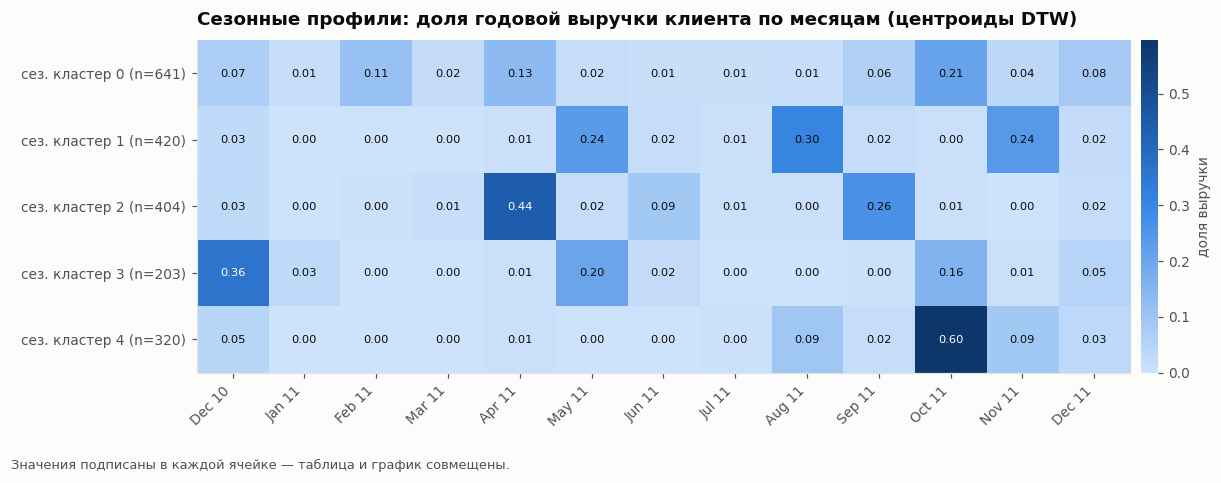

ARI(DTW-недели, DTW-месяцы) = 0.089


In [54]:
# Сезонная кластеризация месячных профилей (доля годовых покупок по месяцам)
ms = fit_ts_kmeans(TS_M_share, K_TS, "dtw", n_init=3, max_iter=20)
labels_season = pd.Series(ms.labels_, index=ts_customers, name="cluster_season")
cent = pd.DataFrame(ms.cluster_centers_[:, :, 0], columns=[f"{d:%b %y}" for d in month_index])
cent.index = [f"сез. кластер {i} (n={c})" for i, c in enumerate(np.bincount(ms.labels_))]

fig, ax = plt.subplots(figsize=(12, 2.6 + 0.3 * K_TS))
im = ax.imshow(cent.values, cmap=SEQ_BLUE, aspect="auto", vmin=0)
ax.set_xticks(range(cent.shape[1]), cent.columns, rotation=45, ha="right")
ax.set_yticks(range(cent.shape[0]), cent.index, fontsize=9)
for i in range(cent.shape[0]):
    for j in range(cent.shape[1]):
        v = cent.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if v > cent.values.max() * 0.6 else INK)
ax.set_title("Сезонные профили: доля годовой выручки клиента по месяцам (центроиды DTW)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label("доля выручки", color=INK_2, fontsize=9)
cb.outline.set_visible(False)
finish(fig, "21_season_clusters", "Значения подписаны в каждой ячейке — таблица и график совмещены.")
print("ARI(DTW-недели, DTW-месяцы) = %.3f" % adjusted_rand_score(labels_ts, labels_season))

Месячные профили в долях выделяют **месяц концентрации закупок**: центроиды сходятся к
«апрельскому» (44% годовой выручки клиента в апреле), «октябрьскому» (60%),
«декабрьскому 2010» (36%) и двум смешанным. Согласованность с недельными DTW-кластерами
низкая (ARI ≈ 0.09) — это ожидаемо: недельная сетка описывает **ритм** покупок,
а месячные доли — **сезонный сдвиг**.

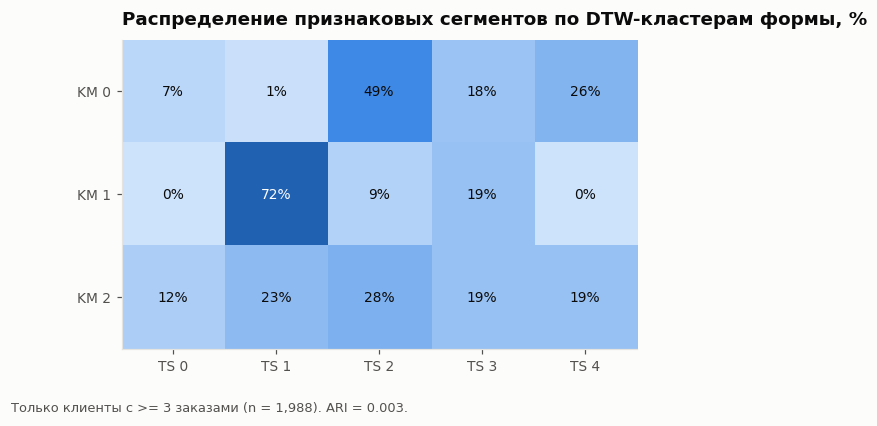

ARI(K-Means признаки, DTW-ряды) = 0.003
AMI = 0.088


In [55]:
# Согласованность двух подходов: признаковые сегменты vs кластеры формы рядов
both = pd.concat([labels_km, labels_ts], axis=1).dropna().astype(int)
ct = pd.crosstab(both.cluster_km, both.cluster_ts, normalize="index") * 100

fig, ax = plt.subplots(figsize=(6.6, 3.6))
im = ax.imshow(ct.values, cmap=SEQ_BLUE, vmin=0, vmax=100)
ax.set_xticks(range(ct.shape[1]), [f"TS {c}" for c in ct.columns])
ax.set_yticks(range(ct.shape[0]), [f"KM {r}" for r in ct.index])
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                color="white" if v > 55 else INK)
ax.set_title("Распределение признаковых сегментов по DTW-кластерам формы, %")
ax.grid(False)
finish(fig, "22_km_vs_ts", f"Только клиенты с >= {MIN_ORDERS_TS} заказами (n = {len(both):,}). "
                            f"ARI = {adjusted_rand_score(both.cluster_km, both.cluster_ts):.3f}.")
print("ARI(K-Means признаки, DTW-ряды) = %.3f" % adjusted_rand_score(both.cluster_km, both.cluster_ts))
print("AMI = %.3f" % adjusted_mutual_info_score(both.cluster_km, both.cluster_ts))

## 11. Анализ результатов кластеризации

Интерпретируем сегменты по **исходным** (не нормализованным) значениям признаков —
только так профили читаются в бизнес-терминах.

### 11.1 Профили сегментов и автоматическая характеристика

In [56]:
prof_cols = ["n_orders", "monetary", "avg_order_value", "avg_items_per_order", "n_products",
             "recency_days", "tenure_days", "orders_per_month", "active_weeks", "active_week_rate",
             "ipt_mean", "ipt_cv", "burstiness", "holiday_rev_share", "q4_rev_share", "season_ratio",
             "month_entropy", "trend_slope", "h2_h1_log_ratio", "return_rate", "is_uk"]

fk = f.join(labels_km)
profile = fk.groupby("cluster_km")[prof_cols].median()
profile.insert(0, "клиентов", fk.groupby("cluster_km").size())
profile.insert(1, "% клиентов", (100 * fk.groupby("cluster_km").size() / len(fk)).round(1))
profile.insert(2, "% оборота", (100 * fk.groupby("cluster_km").monetary.sum() / fk.monetary.sum()).round(1))
profile.insert(3, "оборот, £", fk.groupby("cluster_km").monetary.sum().round(0))
display(profile.round(2).T)

cluster_km,0,1,2
клиентов,"1,397.000","1,332.000","1,593.000"
% клиентов,32.300,30.800,36.900
% оборота,8.000,9.400,82.600
"оборот, £","670,287.000","781,147.000","6,894,298.000"
n_orders,1.000,1.000,6.000
monetary,338.950,389.600,"2,022.980"
avg_order_value,228.800,282.400,330.210
avg_items_per_order,13.000,18.000,18.390
n_products,19.000,26.000,86.000
recency_days,205.000,39.000,22.000


In [57]:
# Автоматическая характеристика кластеров: по каким осям кластер сильнее всего
# отклоняется от среднего по всем кластерам (z-оценка профиля между кластерами).
AXES = {
    "orders_per_month":  ("частые покупки", "редкие покупки"),
    "avg_order_value":   ("крупный средний чек", "малый средний чек"),
    "recency_days":      ("давно не покупали", "недавно активны"),
    "holiday_rev_share": ("выраженная предпраздничная сезонность", "покупки вне сезона"),
    "ipt_cv":            ("нерегулярный ритм", "регулярный ритм"),
    "active_week_rate":  ("почти постоянная активность", "эпизодическая активность"),
    "monetary":          ("высокий оборот", "низкий оборот"),
    "tenure_days":       ("давние клиенты", "новички"),
}
zprof = ((profile[list(AXES)] - profile[list(AXES)].mean()) / profile[list(AXES)].std(ddof=0))

def auto_label(row, top=3):
    "Словесная характеристика кластера по 3 сильнейшим отклонениям профиля."
    order = row.abs().sort_values(ascending=False).index[:top]
    return "; ".join(AXES[c][0 if row[c] > 0 else 1] for c in order)

auto = zprof.apply(auto_label, axis=1)
print("Чем кластер выделяется ОТНОСИТЕЛЬНО ДРУГИХ кластеров:")
for cl, txt in auto.items():
    print(f"  кластер {cl} (n={profile.loc[cl,'клиентов']:.0f}, {profile.loc[cl,'% оборота']}% оборота): {txt}")

Чем кластер выделяется ОТНОСИТЕЛЬНО ДРУГИХ кластеров:
  кластер 0 (n=1397, 8.0% оборота): редкие покупки; давно не покупали; эпизодическая активность
  кластер 1 (n=1332, 9.4% оборота): новички; почти постоянная активность; частые покупки
  кластер 2 (n=1593, 82.6% оборота): нерегулярный ритм; высокий оборот; выраженная предпраздничная сезонность


In [58]:
def name_segments(prof, base):
    "Бизнес-название сегмента по правилам на его медианном профиле (не зависит от нумерации кластеров)."
    names = {}
    for cl, r in prof.iterrows():
        if r.recency_days > 120 and r.n_orders <= 1.5:
            nm = "Ушедшие разовые"
        elif r.holiday_rev_share >= 0.8:
            nm = "Сезонные предпраздничные"
        elif r.monetary >= 4 * base.monetary and r.n_orders >= 4 * base.n_orders:
            nm = "VIP-ядро (оптовики)"
        elif r.n_orders >= 2 * base.n_orders:
            nm = "Активное ядро (регулярные)"
        elif r.tenure_days <= 120:
            nm = "Недавно привлечённые"
        elif r.recency_days > 120:
            nm = "Затухающие"
        else:
            nm = "Умеренные (средний чек)"
        while nm in names.values():
            nm += " II"
        names[cl] = nm
    return names

BASE_MED = f.median()
LABELS = name_segments(profile, BASE_MED)
fk["segment"] = fk.cluster_km.map(LABELS)
print(json.dumps({str(k): v for k, v in LABELS.items()}, ensure_ascii=False, indent=2))
print("\nОпорные медианы базы: заказов %.0f, оборот £%.0f" % (BASE_MED.n_orders, BASE_MED.monetary))

{
  "0": "Ушедшие разовые",
  "1": "Недавно привлечённые",
  "2": "Активное ядро (регулярные)"
}

Опорные медианы базы: заказов 2, оборот £656


### 11.2 Профили в z-оценках относительно всей базы

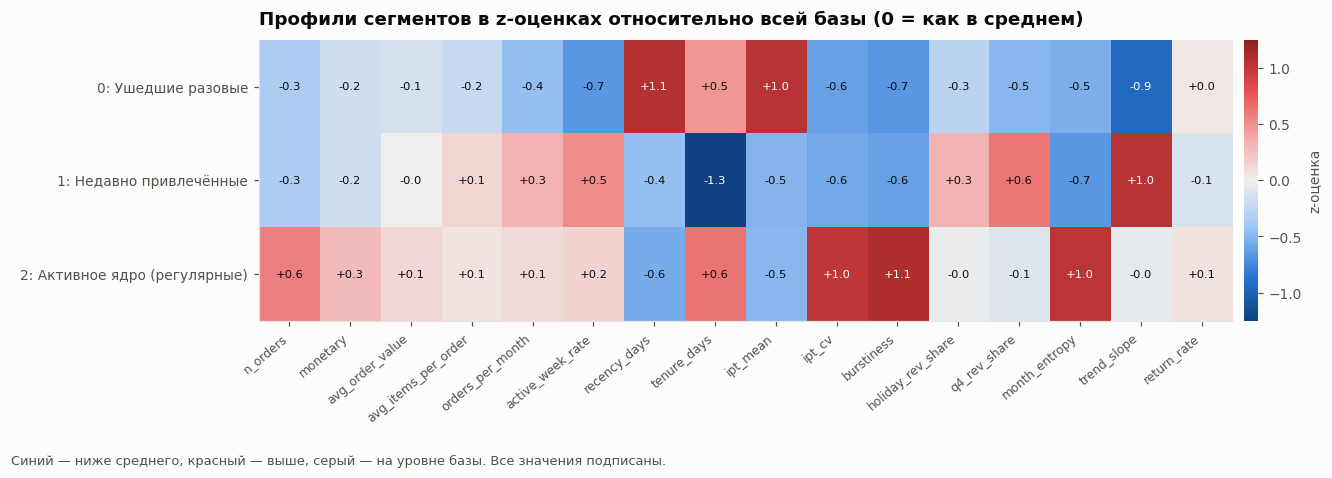

In [59]:
# Профиль кластеров в z-оценках: полярность (выше/ниже среднего) -> расходящаяся шкала
heat_cols = ["n_orders", "monetary", "avg_order_value", "avg_items_per_order", "orders_per_month",
             "active_week_rate", "recency_days", "tenure_days", "ipt_mean", "ipt_cv", "burstiness",
             "holiday_rev_share", "q4_rev_share", "month_entropy", "trend_slope", "return_rate"]
zh = (fk.groupby("cluster_km")[heat_cols].mean() - f[heat_cols].mean()) / f[heat_cols].std(ddof=0)

fig, ax = plt.subplots(figsize=(13, 2.2 + 0.62 * K_FEAT))
vmax = float(np.nanmax(np.abs(zh.values)))
im = ax.imshow(zh.values, cmap=DIV_BR, norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax), aspect="auto")
ax.set_xticks(range(len(heat_cols)), heat_cols, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(K_FEAT), [f"{cl}: {LABELS[cl]}" for cl in zh.index], fontsize=9)
for i in range(zh.shape[0]):
    for j in range(zh.shape[1]):
        v = zh.values[i, j]
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > vmax * 0.55 else INK)
ax.set_title("Профили сегментов в z-оценках относительно всей базы (0 = как в среднем)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label("z-оценка", color=INK_2, fontsize=9)
cb.outline.set_visible(False)
finish(fig, "23_segment_heatmap", "Синий — ниже среднего, красный — выше, серый — на уровне базы. Все значения подписаны.")

### 11.3 Чем сегменты различаются: профили, вклад в оборот, распределения

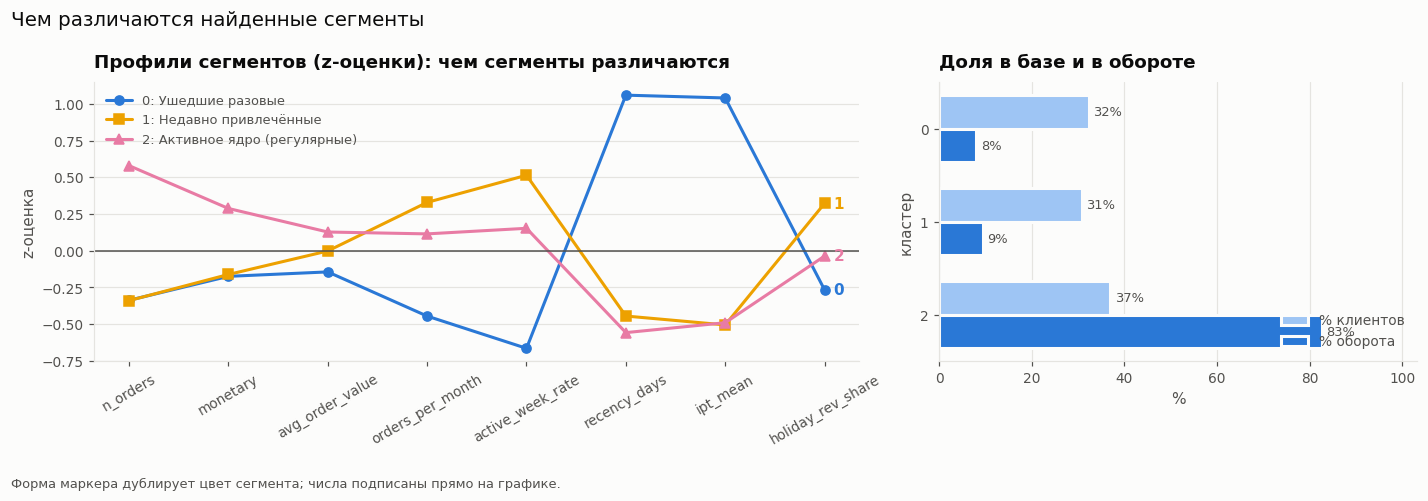

In [60]:
# «Змейка» (snake plot) по ключевым осям + вклад сегментов в клиентов и оборот
snake_cols = ["n_orders", "monetary", "avg_order_value", "orders_per_month",
              "active_week_rate", "recency_days", "ipt_mean", "holiday_rev_share"]
zs = (fk.groupby("cluster_km")[snake_cols].mean() - f[snake_cols].mean()) / f[snake_cols].std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw=dict(width_ratios=[1.6, 1]))
ax = axes[0]
for cl in zs.index:
    ax.plot(snake_cols, zs.loc[cl], color=cl_color(cl), marker=cl_marker(cl), ms=6, lw=2.0,
            label=f"{cl}: {LABELS[cl]}")
    ax.annotate(str(cl), (len(snake_cols) - 1, zs.loc[cl].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", fontsize=10, fontweight="bold", color=cl_color(cl), va="center")
ax.axhline(0, color=INK_2, lw=1.0)
ax.set_title("Профили сегментов (z-оценки): чем сегменты различаются")
ax.set_ylabel("z-оценка"); ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper left", fontsize=8.5)
ax.grid(axis="x", visible=False)

ax = axes[1]
share = pd.DataFrame({"% клиентов": profile["% клиентов"], "% оборота": profile["% оборота"]})
ypos = np.arange(K_FEAT)
h = 0.36
ax.barh(ypos - h/2, share["% клиентов"], height=h, color="#9ec5f4", label="% клиентов",
        edgecolor=SURFACE, linewidth=2)
ax.barh(ypos + h/2, share["% оборота"], height=h, color=ACCENT, label="% оборота",
        edgecolor=SURFACE, linewidth=2)
for i in ypos:
    ax.text(share["% клиентов"].iloc[i] + 1, i - h/2, f"{share['% клиентов'].iloc[i]:.0f}%",
            va="center", fontsize=8.5, color=INK_2)
    ax.text(share["% оборота"].iloc[i] + 1, i + h/2, f"{share['% оборота'].iloc[i]:.0f}%",
            va="center", fontsize=8.5, color=INK_2)
ax.set_yticks(ypos, [f"{cl}" for cl in profile.index])
ax.set_xlim(0, max(share.max()) * 1.25)
ax.set_title("Доля в базе и в обороте"); ax.set_xlabel("%"); ax.set_ylabel("кластер")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
ax.invert_yaxis()

fig.suptitle("Чем различаются найденные сегменты", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "24_snake_and_share", "Форма маркера дублирует цвет сегмента; числа подписаны прямо на графике.")

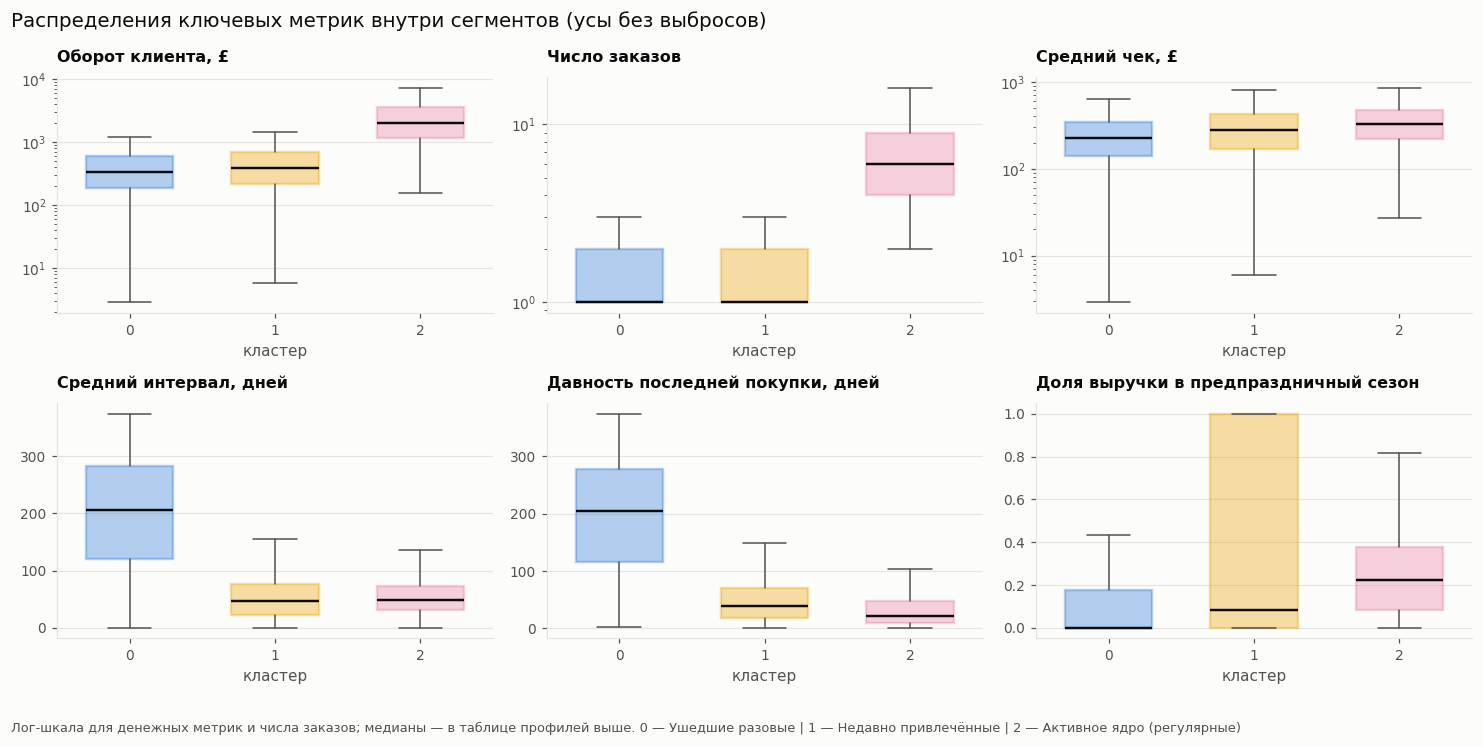

In [61]:
# Распределения ключевых метрик по сегментам (боксплоты, лог-шкала где нужно)
box_specs = [("monetary", "Оборот клиента, £", True), ("n_orders", "Число заказов", True),
             ("avg_order_value", "Средний чек, £", True), ("ipt_mean", "Средний интервал, дней", False),
             ("recency_days", "Давность последней покупки, дней", False),
             ("holiday_rev_share", "Доля выручки в предпраздничный сезон", False)]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
for ax, (col, ttl, logy) in zip(axes.ravel(), box_specs):
    data = [fk.loc[fk.cluster_km == cl, col].values for cl in range(K_FEAT)]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False,
                    medianprops=dict(color=INK, lw=1.6))
    for patch, cl in zip(bp["boxes"], range(K_FEAT)):
        patch.set_facecolor(cl_color(cl)); patch.set_alpha(.35); patch.set_edgecolor(cl_color(cl)); patch.set_linewidth(1.6)
    for w in bp["whiskers"] + bp["caps"]:
        w.set_color(INK_2); w.set_linewidth(1.0)
    if logy: ax.set_yscale("log")
    ax.set_title(ttl, fontsize=10.5); ax.set_xticks(range(1, K_FEAT + 1), [str(c) for c in range(K_FEAT)])
    ax.set_xlabel("кластер"); ax.grid(axis="x", visible=False)
fig.suptitle("Распределения ключевых метрик внутри сегментов (усы без выбросов)", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "25_boxplots", "Лог-шкала для денежных метрик и числа заказов; медианы — в таблице профилей выше. "
                           + " | ".join(f"{cl} — {LABELS[cl]}" for cl in range(K_FEAT)))

### 11.4 Сезонные и недельные паттерны сегментов

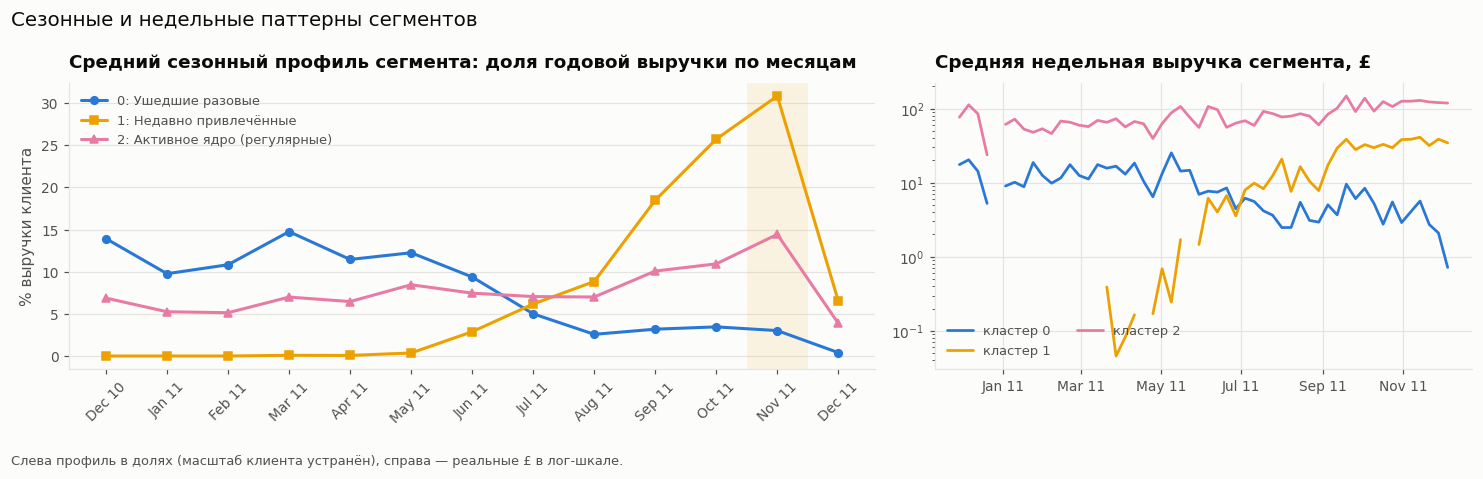

,2010-12-01 00:00:00,2011-01-01 00:00:00,2011-02-01 00:00:00,2011-03-01 00:00:00,2011-04-01 00:00:00,2011-05-01 00:00:00,2011-06-01 00:00:00,2011-07-01 00:00:00,2011-08-01 00:00:00,2011-09-01 00:00:00,2011-10-01 00:00:00,2011-11-01 00:00:00,2011-12-01 00:00:00
cluster_km,,,,,,,,,,,,,
0,13.900,9.800,10.800,14.800,11.500,12.300,9.400,5.000,2.600,3.200,3.500,3.000,0.400
1,0.000,0.000,0.000,0.100,0.100,0.400,2.900,6.200,8.800,18.500,25.700,30.900,6.500
2,6.900,5.300,5.100,7.000,6.500,8.500,7.500,7.100,7.000,10.100,10.900,14.400,3.900


In [62]:
# Сезонность сегментов: средняя доля годовой выручки по месяцам (профиль, свободный от масштаба)
seg_season = (M_rev.div(M_rev.sum(axis=1), axis=0)).join(labels_km).groupby("cluster_km").mean()
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0), gridspec_kw=dict(width_ratios=[1.5, 1]))
ax = axes[0]
xm = [f"{d:%b %y}" for d in month_index]
for cl in seg_season.index:
    ax.plot(xm, seg_season.loc[cl] * 100, color=cl_color(cl), marker=cl_marker(cl), ms=5, lw=2.0,
            label=f"{cl}: {LABELS[cl]}")
ax.set_title("Средний сезонный профиль сегмента: доля годовой выручки по месяцам")
ax.set_ylabel("% выручки клиента"); ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", fontsize=8.5); ax.grid(axis="x", visible=False)
ax.axvspan(10.5, 11.5, color="#eda100", alpha=.10, lw=0)

ax = axes[1]
# Средняя недельная выручка сегмента (сырые £) — общая ось Y, никаких вторых осей
# нули (недели без покупок) маскируем, иначе лог-шкала рисует «провалы» в бесконечность
seg_week = W_rev.join(labels_km).groupby("cluster_km").mean().replace(0, np.nan)
for cl in seg_week.index:
    ax.plot(week_index, seg_week.loc[cl], color=cl_color(cl), lw=1.8, label=f"кластер {cl}")
ax.set_title("Средняя недельная выручка сегмента, £")
ax.yaxis.set_major_formatter(GBP); ax.set_yscale("log")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.legend(loc="lower left", fontsize=8.5, ncols=2)
fig.suptitle("Сезонные и недельные паттерны сегментов", x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "26_segment_seasonality", "Слева профиль в долях (масштаб клиента устранён), справа — реальные £ в лог-шкале.")
display((seg_season * 100).round(1))

### 11.5 Детализация: более дробное разбиение

Индексы качества выбрали **K_FEAT = 3** — статистически наиболее устойчивое разбиение,
но операционно оно грубое: в одном «активном ядре» оказываются и оптовики, и клиенты
со средним чеком. Метод локтя указывает на область k = 4…5, поэтому берём **k = 5**:
при нём выделяется оптовое ядро и отдельный предпраздничный сегмент, а минимальный
кластер по-прежнему содержит > 10% базы (см. столбец `min_cluster_%` таблицы выбора k).
Ниже — профили этого разбиения; основным для дальнейших выводов остаётся k = 3,
а k = 5 используется как его детализация.

In [63]:
K_DETAIL = 5   # локоть указывает на 4-5; берём 5 — ради разделения оптовиков и «среднего чека»
assert K_DETAIL in km_models, f"модель для k={K_DETAIL} не обучена (K_RANGE = {K_RANGE})"
print(f"Формальный локоть кривой инерции: k = {K_ELBOW}; для детализации взято k = {K_DETAIL}")
labels_detail = pd.Series(km_models[K_DETAIL].labels_, index=Xs.index, name="cluster_detail")
fd = f.join(labels_detail)
profile_d = fd.groupby("cluster_detail")[prof_cols].median()
profile_d.insert(0, "клиентов", fd.groupby("cluster_detail").size())
profile_d.insert(1, "% клиентов", (100 * fd.groupby("cluster_detail").size() / len(fd)).round(1))
profile_d.insert(2, "% оборота", (100 * fd.groupby("cluster_detail").monetary.sum() / fd.monetary.sum()).round(1))
LABELS_D = name_segments(profile_d, BASE_MED)
profile_d.index = [f"{cl}: {LABELS_D[cl]}" for cl in profile_d.index]
display(profile_d.round(2).T)
print("Силуэт при k=%d: %.3f (против %.3f при k=%d)" % (K_DETAIL, sel.loc[K_DETAIL, "silhouette"],
                                                        sel.loc[K_FEAT, "silhouette"], K_FEAT))

Формальный локоть кривой инерции: k = 4; для детализации взято k = 5


,0: Недавно привлечённые,1: Активное ядро (регулярные),2: Ушедшие разовые,3: Сезонные предпраздничные,4: VIP-ядро (оптовики)
клиентов,902.000,"1,279.000",910.000,590.000,641.000
% клиентов,20.900,29.600,21.100,13.700,14.800
% оборота,5.300,21.500,4.300,5.000,64.000
n_orders,1.000,4.000,1.000,2.000,11.000
monetary,346.150,"1,118.540",293.780,430.520,"3,972.450"
avg_order_value,283.150,295.770,214.710,255.480,368.370
avg_items_per_order,16.450,17.830,12.500,19.450,17.480
n_products,21.000,57.000,16.000,32.000,117.000
recency_days,73.000,40.000,256.000,18.000,10.000
tenure_days,102.000,295.000,289.000,34.000,358.000


Силуэт при k=5: 0.173 (против 0.215 при k=3)


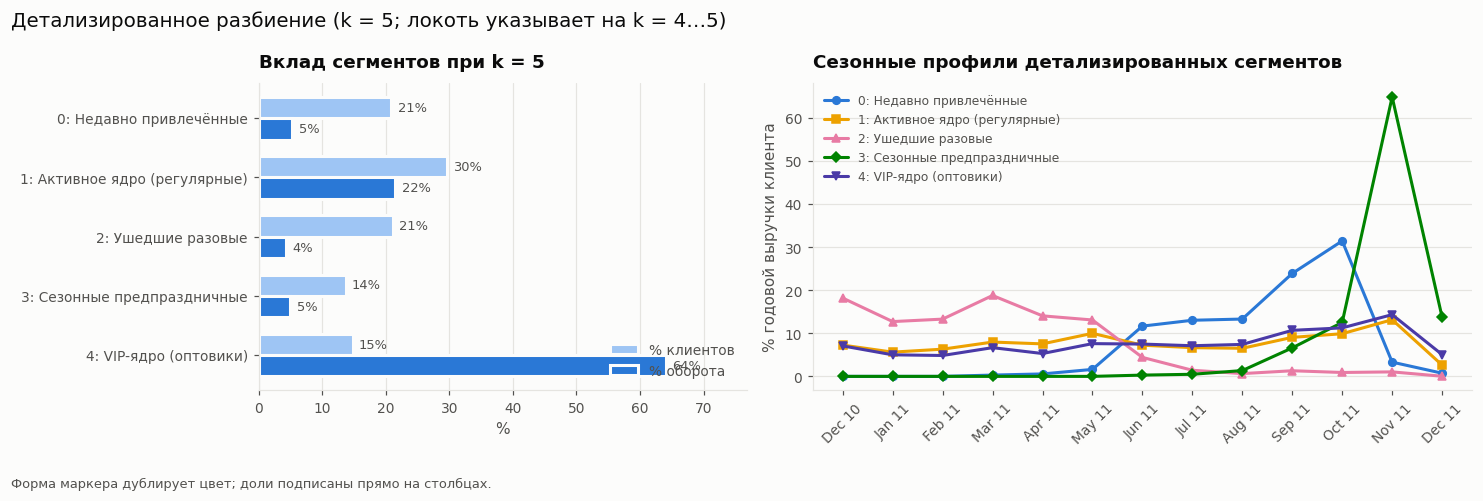

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), gridspec_kw=dict(width_ratios=[1, 1.35]))
ax = axes[0]
ypos = np.arange(K_DETAIL); h = 0.36
pc = profile_d["% клиентов"].values; pr = profile_d["% оборота"].values
ax.barh(ypos - h/2, pc, height=h, color="#9ec5f4", label="% клиентов", edgecolor=SURFACE, linewidth=2)
ax.barh(ypos + h/2, pr, height=h, color=ACCENT, label="% оборота", edgecolor=SURFACE, linewidth=2)
for i in ypos:
    ax.text(pc[i] + 1, i - h/2, f"{pc[i]:.0f}%", va="center", fontsize=8.5, color=INK_2)
    ax.text(pr[i] + 1, i + h/2, f"{pr[i]:.0f}%", va="center", fontsize=8.5, color=INK_2)
ax.set_yticks(ypos, [f"{cl}: {LABELS_D[cl]}" for cl in range(K_DETAIL)], fontsize=9)
ax.set_xlim(0, max(pc.max(), pr.max()) * 1.2); ax.invert_yaxis()
ax.set_title(f"Вклад сегментов при k = {K_DETAIL}"); ax.set_xlabel("%")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)

ax = axes[1]
seg_season_d = (M_rev.div(M_rev.sum(axis=1), axis=0)).join(labels_detail).groupby("cluster_detail").mean()
for cl in seg_season_d.index:
    ax.plot([f"{d:%b %y}" for d in month_index], seg_season_d.loc[cl] * 100, color=cl_color(cl),
            marker=cl_marker(cl), ms=5, lw=2.0, label=f"{cl}: {LABELS_D[cl]}")
ax.set_title("Сезонные профили детализированных сегментов")
ax.set_ylabel("% годовой выручки клиента"); ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", fontsize=8); ax.grid(axis="x", visible=False)
fig.suptitle(f"Детализированное разбиение (k = {K_DETAIL}; локоть указывает на k = {K_ELBOW}…5)",
             x=0.005, ha="left", color=INK)
fig.tight_layout()
finish(fig, "27_detail_segments", "Форма маркера дублирует цвет; доли подписаны прямо на столбцах.")

### 11.6 Характеристика кластеров формы рядов (DTW)

Признаковые сегменты отвечают на вопрос «**сколько и как часто**» покупает клиент,
а DTW-кластеры недельных рядов — «**когда** и с каким рисунком во времени».
Опишем каждый кластер формы через распределение выручки по фазам года.

In [65]:
Wts_rev = W_rev.loc[ts_customers]
share_w = Wts_rev.div(Wts_rev.sum(axis=1), axis=0)          # недельный профиль клиента в долях
# Кварталы считаем по ДНЕВНОЙ матрице: недельная сетка размывает границы кварталов
Dts_rev = D_rev.loc[ts_customers]
q_share = (Dts_rev.div(Dts_rev.sum(axis=1), axis=0)
                  .T.groupby(pd.PeriodIndex(Dts_rev.columns, freq="Q")).sum().T)
q_share.columns = [f"{per.year}Q{per.quarter}" for per in q_share.columns]
q_prof = q_share.groupby(labels_ts).mean()
mean_prof = share_w.groupby(labels_ts).mean()

ts_char = pd.concat([
    pd.DataFrame({
        "клиентов": labels_ts.value_counts().sort_index(),
        "% оборота (в выборке)": (100 * f.loc[ts_customers].groupby(labels_ts).monetary.sum()
                                  / f.loc[ts_customers].monetary.sum()).round(1),
        "медиана заказов": f.loc[ts_customers].groupby(labels_ts).n_orders.median(),
        "медиана оборота, £": f.loc[ts_customers].groupby(labels_ts).monetary.median().round(0),
        "активных недель (среднее)": f.loc[ts_customers].groupby(labels_ts).active_weeks.mean().round(1),
        "интервал, дней (медиана)": f.loc[ts_customers].groupby(labels_ts).ipt_mean.median().round(0),
        "пик профиля (неделя с)": [f"{mean_prof.loc[cl].idxmax():%d.%m.%Y}" for cl in mean_prof.index],
    }),
    q_prof.round(3),
], axis=1)

def name_shape(r):
    "Название кластера формы: где сконцентрирована выручка и насколько постоянна активность."
    if r["2011Q4"] > 0.40:
        return "Растущие: пик в IV кв. 2011"
    if r["2011Q3"] > 0.35:
        return "Летне-осенний пик (III кв. 2011)"
    if r["2010Q4"] > 0.15 and r["активных недель (среднее)"] >= 9:
        return "Постоянно активные весь период"
    if r["2010Q4"] > 0.15:
        return "Старт в декабре 2010, эпизодические"
    return "Пришли в 2011, ровный ритм"

shape_names, used = {}, []
for cl, r in ts_char.iterrows():
    nm = name_shape(r)
    while nm in used:
        nm += " II"
    used.append(nm); shape_names[cl] = nm
ts_char.insert(0, "форма", [shape_names[cl] for cl in ts_char.index])
display(ts_char.T)

cluster_ts,0,1,2,3,4
форма,Постоянно активные весь период,Растущие: пик в IV кв. 2011,"Пришли в 2011, ровный ритм",Летне-осенний пик (III кв. 2011),"Старт в декабре 2010, эпизодические"
клиентов,205,501,563,372,347
% оборота (в выборке),14.700,26.300,22.100,19.900,16.900
медиана заказов,8.000,4.000,4.000,5.000,6.000
"медиана оборота, £","2,889.000","1,418.000","1,474.000","1,641.000","1,889.000"
активных недель (среднее),10.100,5.700,5.400,6.100,7.100
"интервал, дней (медиана)",45.000,36.000,56.000,48.000,59.000
пик профиля (неделя с),29.11.2010,14.11.2011,16.05.2011,04.07.2011,06.12.2010
2010Q4,0.233,0.006,0.007,0.007,0.216
2011Q1,0.176,0.065,0.262,0.150,0.188


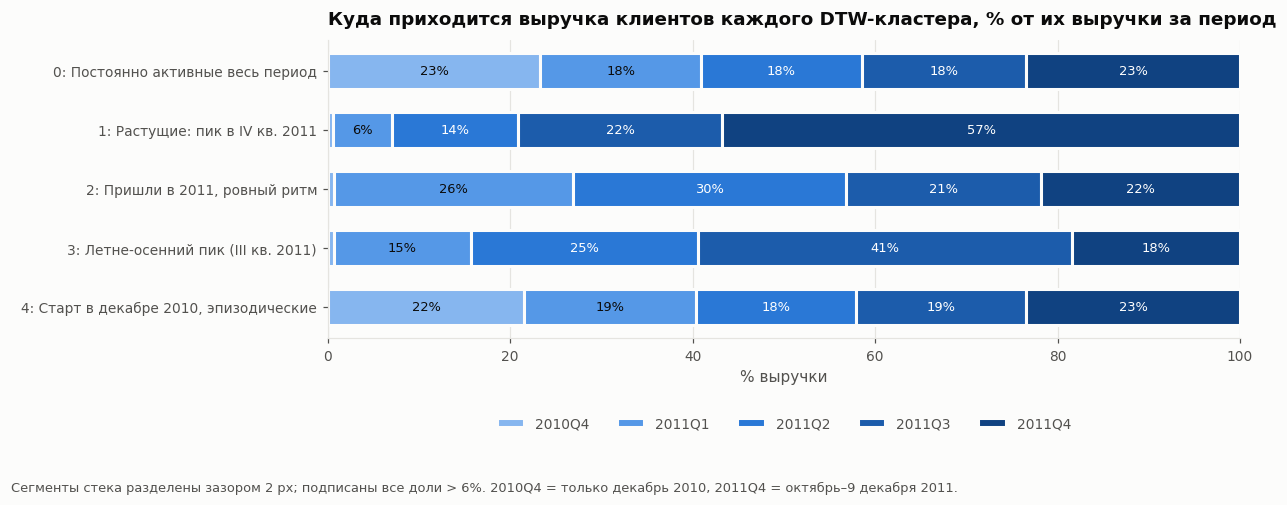

In [66]:
# Распределение выручки клиентов по кварталам внутри каждого кластера формы.
# Кварталы упорядочены во времени -> порядковая (ordinal) одноцветная шкала, а не категориальная.
ORD_BLUE = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
fig, ax = plt.subplots(figsize=(11.5, 4.3))
left = np.zeros(len(q_prof))
ylab = [f"{cl}: {shape_names[cl]}" for cl in q_prof.index]
for j, col in enumerate(q_prof.columns):
    v = q_prof[col].values * 100
    ax.barh(ylab, v, left=left, color=ORD_BLUE[j % len(ORD_BLUE)], height=0.6, label=col,
            edgecolor=SURFACE, linewidth=2)
    for i, val in enumerate(v):
        if val > 6:
            ax.text(left[i] + val / 2, i, f"{val:.0f}%", ha="center", va="center", fontsize=8.5,
                    color="white" if j >= 2 else INK)
    left += v
ax.set_xlim(0, 100); ax.invert_yaxis()
ax.set_title("Куда приходится выручка клиентов каждого DTW-кластера, % от их выручки за период")
ax.set_xlabel("% выручки"); ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncols=5, fontsize=9)   # легенда под осью
finish(fig, "28_ts_phases", "Сегменты стека разделены зазором 2 px; подписаны все доли > 6%. "
                             "2010Q4 = только декабрь 2010, 2011Q4 = октябрь–9 декабря 2011.")

In [67]:
# Сводная таблица сегментов
summary_tbl = pd.DataFrame({
    "сегмент": [f"{cl}: {LABELS[cl]}" for cl in range(K_FEAT)],
    "клиентов": profile["клиентов"].astype(int).values,
    "% базы": profile["% клиентов"].values,
    "% оборота": profile["% оборота"].values,
    "медиана оборота, £": profile["monetary"].round(0).values,
    "медиана чека, £": profile["avg_order_value"].round(0).values,
    "заказов (медиана)": profile["n_orders"].values,
    "заказов/мес": profile["orders_per_month"].round(2).values,
    "интервал, дней": profile["ipt_mean"].round(0).values,
    "давность, дней": profile["recency_days"].round(0).values,
    "доля в предпразд. сезон": profile["holiday_rev_share"].round(2).values,
    "характеристика (авто)": auto.values,
}).set_index("сегмент")
display(summary_tbl.T)
summary_tbl.to_csv(FIG_DIR.parent / "segments_summary.csv", encoding="utf-8-sig")
(fk[["cluster_km", "segment"]].join(labels_detail).join(labels_ts).join(labels_hc).join(labels_db)
   .join(labels_season).rename(columns={"cluster_km": "сегмент_kmeans", "segment": "название_сегмента",
         "cluster_detail": "сегмент_детализация", "cluster_ts": "кластер_формы_DTW",
         "cluster_hc": "кластер_Ward", "cluster_db": "кластер_DBSCAN", "cluster_season": "кластер_сезонности"})
   .to_csv(FIG_DIR.parent / "customer_clusters.csv", encoding="utf-8-sig"))
print("Сохранено: reports/segments_summary.csv, reports/customer_clusters.csv")

сегмент,0: Ушедшие разовые,1: Недавно привлечённые,2: Активное ядро (регулярные)
клиентов,1397,1332,1593
% базы,32.300,30.800,36.900
% оборота,8.000,9.400,82.600
"медиана оборота, £",339.000,390.000,"2,023.000"
"медиана чека, £",229.000,282.000,330.000
заказов (медиана),1.000,1.000,6.000
заказов/мес,0.170,0.660,0.630
"интервал, дней",206.000,46.000,49.000
"давность, дней",205.000,39.000,22.000
доля в предпразд. сезон,0.000,0.080,0.220


Сохранено: reports/segments_summary.csv, reports/customer_clusters.csv


### 11.7 Что означают найденные группы

**Базовое разбиение (K-Means, k = 3)** — три качественно разных состояния клиента:

| сегмент | доля базы | доля оборота | портрет (медианы) |
|---|---|---|---|
| **Активное ядро (регулярные)** | 36.9% | **82.6%** (£6.89 млн) | 6 заказов, оборот £2 023, чек £330, 86 разных товаров, интервал 49 дней, последняя покупка 22 дня назад, покупки распределены по 5–6 месяцам (`month_entropy` = 0.57), нерегулярный ритм (`ipt_cv` = 0.80). Практически весь оборот компании. |
| **Недавно привлечённые** | 30.8% | 9.4% (£0.78 млн) | «возраст» клиента 66 дней, 1 заказ, £390, **вся выручка в IV квартале** (`q4_rev_share` = 1.0), высокая текущая интенсивность (0.66 заказа/мес), давность 39 дней. Осенний приток 2011 года: судить о лояльности рано. |
| **Ушедшие разовые** | 32.3% | 8.0% (£0.67 млн) | 1 заказ, £339, чек £229, давность **205 дней**, вся выручка в первой половине периода (`h2_h1_log_ratio` = −4.7), 13 позиций в корзине. Пришли зимой–весной 2011 и не вернулись. |

**Детализация (k = 5)** расщепляет ядро и новичков и даёт ровно те группы,
которые требовались в задании:

* **VIP-ядро (оптовики)** — 14.8% базы и **64.0% оборота**: медиана 11 заказов и £3 972,
  самый высокий чек (£368), интервал 30 дней, 117 разных товаров, активны почти всё окно
  наблюдения (`month_entropy` = 0.74) — это «частые покупатели»;
* **Активное ядро (регулярные)** — 29.6% базы, 21.5% оборота: 4 заказа, £1 119, чек £296,
  интервал 75 дней — это «покупатели со средним чеком»;
* **Сезонные предпраздничные** — 13.7% базы, 5.0% оборота: **100% выручки в предпраздничном
  сезоне**, давность 18 дней, интервал 23 дня — это «покупатели с сезонными паттернами»;
* **Недавно привлечённые** — 20.9% базы, 5.3% оборота: пришли летом–осенью (возраст 102 дня),
  пока 1 покупка;
* **Ушедшие разовые** — 21.1% базы, 4.3% оборота: давность 256 дней, интервал 248 дней.

**Кластеры формы рядов (DTW, k = 5)** описывают не объём, а рисунок активности во времени
(таблица и стековая диаграмма выше):

| кластер формы | клиентов | пиковая неделя | характерное распределение выручки |
|---|---|---|---|
| **Постоянно активные весь период** | 205 | нед. 29.11.2010 | ровно по всем кварталам (23/18/18/18/23%), 10.1 активной недели, медиана 8 заказов и £2 889 — самый ценный рисунок |
| **Растущие: пик в IV кв. 2011** | 501 | нед. 14.11.2011 | 57% выручки в IV кв. 2011, интервал 36 дней |
| **Пришли в 2011, ровный ритм** | 563 | нед. 16.05.2011 | ничего в дек. 2010, далее равномерно (26/30/21/22%) |
| **Летне-осенний пик (III кв. 2011)** | 372 | нед. 04.07.2011 | 41% выручки в III кв. 2011 |
| **Старт в декабре 2010, эпизодические** | 347 | нед. 06.12.2010 | 22% в дек. 2010, затем редкие всплески; 7.1 активной недели |

Формальная согласованность двух разбиений низкая (**ARI = 0.003, AMI = 0.088**), но это не
означает отсутствия связи — разбиения просто отвечают на разные вопросы. В деталях
(тепловая карта в §10) видно:

* «Недавно привлечённые» на **72%** попадают в форму «Растущие: пик в IV кв. 2011» — оба
  метода независимо описали один и тот же осенний приток;
* «Ушедшие разовые» — на 49% в «Пришли в 2011, ровный ритм» и на 26% в «Старт в декабре
  2010, эпизодические»;
* а вот **«Активное ядро» распределено почти равномерно по всем пяти формам**
  (12 / 23 / 28 / 19 / 19%).

Последнее — главный практический вывод раздела: внутри самого ценного сегмента
(83% оборота) присутствуют **все пять** временных рисунков, поэтому одной
RFM-сегментации для планирования коммуникаций недостаточно.
**RFM-сегмент отвечает за ценность клиента, кластер формы ряда — за момент контакта.**

## 12. Выводы

### 12.1 Данные и очистка

* Из 541 909 строк после очистки осталось **388 266 (71.6%)**, оборот £8 345 731,
  18 289 счетов, 4 322 клиента. Удалены: 5 268 полных дубликатов; 135 037 строк без
  `CustomerID` (25.2% строк и 14.9% оборота — клиентский анализ по ним невозможен);
  2 957 строк полностью возвращённых покупок; 8 872 строки-отмены; 40 строк с нулевой
  ценой (бесплатные позиции и ручные корректировки); 1 469 служебных позиций — доставка
  (`POST`, `DOT`, `C2`), ручные корректировки (`M`), банковские сборы, `PADS`.
  Подарочные карты (`gift_0001_*`) и коды `DCGS*` ушли раньше — вместе со строками
  без `CustomerID`.
* Формат даты/времени приведён явно (`to_datetime`, проверка нераспознанных и будущих
  дат), добавлены календарные срезы. Обнаружено, что в данных **нет ни одной субботы**,
  заказы оформляются только в 06:00–20:00, а неделя 27.12.2010–02.01.2011 пуста
  (компания не работала) — эти особенности учтены при построении недельной сетки
  (54 недели, одна из них нулевая для всех клиентов).
* Главный вывод про выбросы: экстремумы ±80 995 шт. — не спрос, а **пара «заказ + его
  полная отмена»** (обе строки датированы 09.12.2011 с разницей 12 минут). Их устраняет
  неттинг возвратов, а не отсечение по квантилю. Оставшиеся «выбросы» (счета > £2 334 —
  1.8% счетов и 22% оборота) — реальные оптовые заказы; они сохранены, а искажение
  масштаба снято логарифмированием и винсоризацией признаков по 1/99 процентилю
  (подрезано 1.3% значений).
* Оборот сильно концентрирован: **топ-20% клиентов дают 74% оборота**, 34.7% клиентов
  купили только один раз.

### 12.2 Признаки и представление временных рядов

* Построено **37 признаков** на клиента по четырём осям: объём и чек; частота и давность;
  интервалы между покупками (среднее, медиана, разброс, `ipt_cv`, «взрывность»);
  сезонность, тренд и регулярность (доля выручки в предпраздничном сезоне, отношение
  дневной интенсивности покупок в сезон и вне сезона, нормированная энтропия
  распределения выручки по месяцам/неделям/дням недели, наклон тренда, отношение
  второго полугодия к первому, доля возвратов). Долю выручки в предпраздничном сезоне
  считаем по **дневной** матрице: недельная сетка ошибается на границе месяца — неделя
  31.10–06.11.2011 (3% годового оборота) по недельной маске попала бы в «не сезон».
* Для кластеризации отобрано **18 признаков** (по одному-двум на поведенческую ось),
  из них 16 остались после контроля коллинеарности (|Spearman| > 0.95 отсекает
  `active_week_rate` и `month_entropy` как дубли частоты и числа заказов).
* Транзакции переведены в матрицы «клиент × период»: день (374 столбца, 99.0% нулей),
  **неделя (54 столбца, 93.2% нулей)** и месяц (13 столбцов, 76.9% нулей). Для формы
  ряда выбрана недельная сетка: дневная слишком разрежена, месячная слишком грубая.
* Нормализация: `log1p` → сглаживание скользящим средним по 4 недели →
  **z-нормализация каждого ряда**. Без неё кластеризация делит клиентов исключительно
  по масштабу закупок (разброс — три порядка), а не по поведению. Полезность сглаживания
  проверена численно: та же DTW-модель на несглаженных рядах даёт силуэт 0.064 против
  **0.109** на сглаженных (сравнительная таблица в разделе 10).
* Shape-based кластеризация выполнена на **1 988 клиентах с ≥ 3 заказами** — это 46%
  базы, но **86.1% оборота**.

### 12.3 Сравнение алгоритмов

| подход | результат | оценка |
|---|---|---|
| **K-Means по признакам** | в диапазоне k = 3…6 все три индекса согласованно указывают на **k = 3** (силуэт 0.215, Дэвис–Болдин 1.56, Калински–Харабас 1 072); локоть кривой инерции — k = 4. Формальный минимум Дэвиса–Болдина приходится на k = 8 (1.55), но там минимальный кластер — 2.5% базы, и такое разбиение не интерпретируется | лучшая интерпретируемость, основа сегментации |
| **Ward (иерархическая)** | 3 кластера (1 408 / 660 / 2 254), силуэт 0.156, **ARI с K-Means 0.407**, AMI 0.411 | ось «ядро — новички — ушедшие» воспроизводится, но промежуточных клиентов Ward делит иначе; дендрограмма показывает, что дальше дробится именно ядро |
| **DBSCAN** (8 главных компонент, `eps` = 2.03 по k-distance, `min_samples` = 15) | 2 плотных кластера + **247 клиентов (5.7%) как шум**, ARI с K-Means ≈ 0.00 | для сегментации непригоден (плотность в 8-мерном пространстве почти однородна), но полезен как **детектор нетипичных клиентов**: у «шума» медианная доля возвратов 13% против 0% у остальных |
| **TimeSeriesKMeans, Euclidean** | 5 кластеров, инерция 40.8 | чувствителен к сдвигу пиков на 1–2 недели |
| **TimeSeriesKMeans, DTW** (окно Сакоэ–Чиба, радиус 3 недели) | 5 кластеров (силуэт DTW 0.109 — максимум по k = 3…6), инерция 23.5 | **основной shape-based результат**: сдвинутые во времени, но одинаковые по рисунку ряды попадают в один кластер |
| **TimeSeriesKMeans, Soft-DTW** (γ = 1) | 5 кластеров, ARI с DTW 0.327 | сглаженная версия DTW: разбиение близко по смыслу, но менее контрастно |
| **DTW по месячным профилям долей** | 5 «сезонных» кластеров, ARI с недельными 0.089 | отвечает на другой вопрос — в каком месяце сконцентрированы закупки |

Абсолютные значения силуэта невысоки (0.11–0.22), и это ожидаемо для транзакционных
данных: клиентское поведение образует **континуум**, а не изолированные облака.
Поэтому опорой служит не абсолютное значение индекса, а (1) согласованность трёх
критериев по k, (2) воспроизводимость профилей разными алгоритмами (K-Means ↔ Ward,
DTW ↔ Euclidean ↔ Soft-DTW) и (3) содержательная различимость профилей.

### 12.4 Ограничения

1. **Окно наблюдения — один год и 9 дней.** Годовую сезонность формально проверить
   нельзя: предпраздничный пик наблюдается один раз, поэтому STL-декомпозиция сделана
   по недельной периодичности (тренд + сезонность объясняют 75% дисперсии дневного ряда),
   а годовой профиль описан только эмпирически.
2. Декабрь 2011 неполный (до 09.12) — спад в конце всех рядов является артефактом
   выгрузки, а не поведения; это отдельно отмечено на графиках.
3. Признаки «новизны» (`tenure_days`, `trend_slope`, `h2_h1_log_ratio`) для клиентов,
   пришедших осенью 2011, цензурированы: их история короче окна наблюдения. Поэтому
   сегмент «Недавно привлечённые» — это состояние, а не окончательный тип поведения.
4. Строки без `CustomerID` (14.9% оборота) полностью выпадают из клиентского анализа;
   у клиентов с 1–2 покупками формы ряда не существует, поэтому в shape-based
   кластеризации они не участвуют.
5. Кластеры не являются «естественными классами»: при изменении набора признаков или
   схемы нормализации границы смещаются. Устойчива именно ось
   **«активное ядро — новички — ушедшие»** — она воспроизводится всеми методами.

### 12.5 Практические рекомендации

* **VIP-ядро (оптовики)** — 64% оборота при 15% базы: персональный менеджер,
  прогноз следующего заказа по личному интервалу (медиана 30 дней), контроль возвратов
  (у сегмента максимальная доля отмен), приоритет складских резервов к ноябрю.
* **Активное ядро (регулярные)** — рост среднего чека (£296): наборы и рекомендации к
  типовой корзине; триггер реактивации при превышении личного интервала (75 дней) в 1.5 раза.
* **Сезонные предпраздничные** — работа в узком окне: каталог и промо в конце октября;
  в межсезонье — недорогие поводы для покупки, чтобы перевести часть сегмента в регулярные.
* **Недавно привлечённые** — критично довести до второй покупки: welcome-цепочка в первые
  30–45 дней (у ядра медианный интервал 49–75 дней, значит окно решения короткое).
* **Ушедшие разовые** — массовые кампании нерентабельны (8% оборота при трети базы):
  одна win-back-волна и исключение из регулярных рассылок.
* **Шум DBSCAN (5.7% клиентов)** — отдельная очередь на ручную проверку: аномальные
  интервалы, суммы и доля возвратов 13% часто означают технические заказы, перепродажу
  или проблемного клиента.
* **Кластеры формы** задают календарь коммуникаций и применяются *поверх* RFM-сегмента
  (внутри активного ядра встречаются все пять рисунков): «постоянно активным» — регулярный
  контент, «растущим» — удержание сразу после первого пика, «летне-осенним» — прогрев за
  3–4 недели до их собственного сезона, «эпизодическим» — точечные напоминания вместо
  постоянных рассылок.
